# Trapped in a Low Dimension
## Decoding Visual Stimulus Identity from V1 Population Activity
### MICrONS Dataset — Session 9_4


**Project overview.** We record calcium-imaging responses from ~700 proofreaded V1 excitatory neurons while a mouse views a library of natural movie clips, gratings, and noise stimuli. The core question is: *can we decode stimulus category from the V1 population response?*

**Two-phase investigation.**

- **Part I** collapses each trial to a single mean-response vector (one sample per unique stimulus) and applies PCA, t-SNE, UMAP, and CEBRA for visualisation and classification. Sample size is ~100 stimuli — enough for a first look but too small for temporal methods or for non-parametric embeddings to generalise.

- **Part II** retains the full temporal structure: every 5-frame bin within every trial is a separate sample (~10 000 bins total). GroupKFold cross-validation groups bins by trial so no fold sees another bin from a trial it trained on. Classifiers are evaluated in the full PCA-50 space, not in 2-D projections. UMAP and CEBRA are both fitted inside each CV fold.

The two phases are designed to contrast a common (but methodologically imperfect) approach with a more rigorous temporal one.

## Setup

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
import matplotlib.transforms as transforms
from matplotlib.patches import Ellipse
import seaborn as sns
from collections import defaultdict, Counter
import warnings
import h5py
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    silhouette_score, balanced_accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    cross_val_score, cross_val_predict,
    StratifiedKFold, GroupKFold,
)
from sklearn.pipeline import Pipeline
from scipy.stats import ttest_1samp

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print('umap-learn not installed — UMAP analyses will be skipped')

try:
    import cebra
    CEBRA_AVAILABLE = True
except ImportError:
    CEBRA_AVAILABLE = False
    print('cebra not installed — CEBRA analyses will be skipped')

%load_ext autoreload
%autoreload 2
import microns_datacleaner as mic
import microns_datacleaner.filters as fl


### Global Configuration

In [2]:
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 13,
    'axes.labelsize': 12, 'axes.spines.top': False,
    'axes.spines.right': False, 'legend.frameon': False,
    'savefig.bbox': 'tight',
})

SEED    = 42
SESSION = '9_4'

# ── Part II temporal binning ───────────────────────────────────
BIN_SIZE        = 5     # frames per time-bin
MIN_BINS        = 2     # drop trials shorter than this

# ── Part II classifier / CV ────────────────────────────────────
N_PCS_FOR_CLF  = 50    # PCA dims fed to classifier
N_PCS_FOR_TSNE = 50    # PCA dims fed into t-SNE / UMAP
N_CV_SPLITS    = 5
N_SHUFFLES     = 50


### Data Loading and Neuron Selection

We use the MICrONS public dataset (version 1718). Neurons are restricted to V1, proofread axons (`ax_clean`), and those with matched functional tuning data. Only excitatory neurons are kept.

In [3]:
from pathlib import Path
import os

# Offline/local-data setup.
# Do NOT call MicronsDataCleaner(...), because its constructor initializes CAVEclient online.
DATA_DIR = Path("data")
VERSION = 1718

if not DATA_DIR.exists():
    raise FileNotFoundError(
        "Expected a local data/ folder in the notebook working directory, but it was not found."
    )

cleaner = mic.MicronsDataCleaner.__new__(mic.MicronsDataCleaner)
cleaner.version = VERSION
cleaner.datadir = str(DATA_DIR)
cleaner.homedir = Path().resolve()
cleaner.data_storage = str(cleaner.homedir / cleaner.datadir / str(cleaner.version))

cleaner._configure_download_tables(VERSION, download_policy="minimum", extra_tables=[])

required_tables = [
    cleaner.tables["nucleus"],
    cleaner.tables["celltype"],
    cleaner.tables["proofreading"],
    cleaner.tables["brain_areas"],
]

if "func_props" in cleaner.tables and cleaner.tables["func_props"] is not None:
    required_tables.append(cleaner.tables["func_props"])

required_tables += list(cleaner.info_to_correct.keys())
required_files = [f"{t}.csv" for t in required_tables if t is not None]

candidate_raw_dirs = [
    DATA_DIR / str(VERSION) / "raw",
    DATA_DIR / "raw",
]

raw_dir = None

for d in candidate_raw_dirs:
    if d.exists():
        existing = {x.name for x in d.glob("*.csv")}
        if all(fname in existing for fname in required_files):
            raw_dir = d
            break

if raw_dir is None:
    debug = []
    for d in candidate_raw_dirs:
        if d.exists():
            debug.append(f"{d}: {[x.name for x in d.glob('*.csv')][:20]}")
        else:
            debug.append(f"{d}: MISSING")

    raise FileNotFoundError(
        "Could not find the local MICrONS raw CSV files needed by microns_datacleaner.\n"
        "Expected all of these files:\n"
        f"{required_files}\n\n"
        "Checked:\n" + "\n".join(debug)
    )

# process_nucleus_data reads from f'{cleaner.data_storage}/raw/...'
cleaner.data_storage = str(raw_dir.parent)

# IMPORTANT: no cleaner.download_nucleus_data()
units, segments = cleaner.process_nucleus_data(functional_data="best_only")

print(f"Total units loaded: {len(units)}")

v1_neurons = fl.filter_neurons(
    units,
    brain_area="V1",
    proofread="ax_clean",
    tuning="matched"
)

v1_exc = v1_neurons[v1_neurons["classification_system"] == "excitatory_neuron"]
v1_inh = v1_neurons[v1_neurons["classification_system"] == "inhibitory_neuron"]

print(f"\nV1 neurons proofread + matched tuning: {len(v1_neurons)}")
print(f"Excitatory: {len(v1_exc)}")
print(f"Inhibitory: {len(v1_inh)}")

Transform positions:   0%|          | 0/94014 [00:00<?, ?it/s]

Transform positions:   7%|▋         | 6361/94014 [00:00<00:01, 63599.75it/s]

Transform positions:  14%|█▎        | 12792/94014 [00:00<00:01, 64012.79it/s]

Transform positions:  20%|██        | 19245/94014 [00:00<00:01, 64248.48it/s]

Transform positions:  27%|██▋       | 25703/94014 [00:00<00:01, 64376.89it/s]

...

Transform positions:  82%|████████▏ | 77324/94014 [00:01<00:00, 64412.20it/s]

Transform positions:  89%|████████▉ | 83800/94014 [00:01<00:00, 64514.33it/s]

Transform positions:  96%|█████████▌| 90274/94014 [00:01<00:00, 64581.62it/s]

Transform positions: 100%|██████████| 94014/94014 [00:01<00:00, 64399.39it/s]

Total units loaded: 90434

V1 neurons proofread + matched tuning: 728
Excitatory: 728
Inhibitory: 0


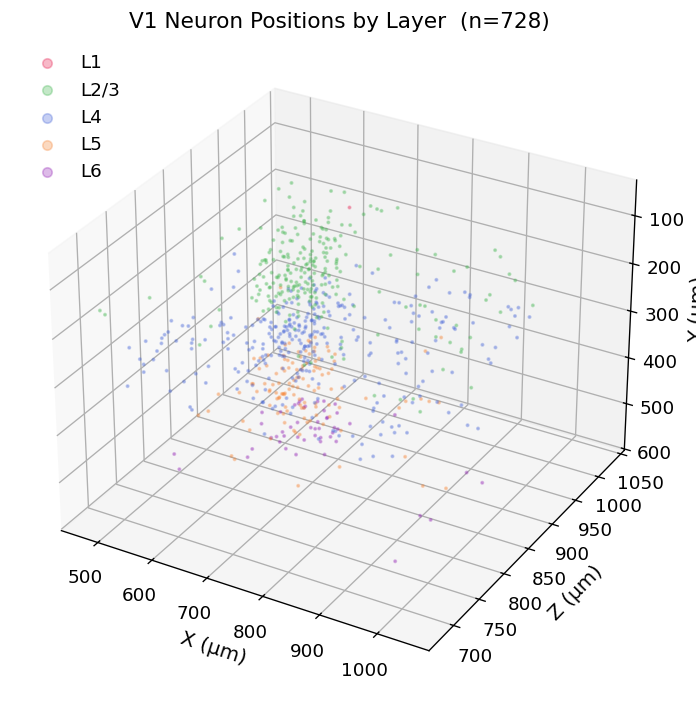

In [4]:
fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(projection='3d')
ax.zaxis.set_inverted(True)

LAYER_COLORS = {
    'L1': '#e6194b', 'L2/3': '#3cb44b',
    'L4': '#4363d8', 'L5': '#f58231', 'L6': '#911eb4'
}

for layer, color in LAYER_COLORS.items():
    ul = fl.filter_neurons(v1_neurons, layer=layer)
    if len(ul):
        ax.scatter(ul['pt_position_x'], ul['pt_position_z'], ul['pt_position_y'],
                   alpha=0.3, s=2, color=color, label=layer)

ax.set_xlabel('X (µm)'); ax.set_ylabel('Z (µm)'); ax.set_zlabel('Y (µm)')
ax.set_title(f'V1 Neuron Positions by Layer  (n={len(v1_neurons)})')
ax.legend(markerscale=4, loc='upper left')
plt.tight_layout()
plt.show()

### Session-level Neuron Filter

Match the anatomical neuron list against the functional recording column IDs for session `9_4`, and build the `trusted_meta` DataFrame that maps each kept column to its cortical layer.

In [5]:
with h5py.File('microns.h5', 'r') as f:
    session_unit_ids = f['sessions'][SESSION]['meta']['unit_ids'][:]

print(f"Columns in r['responses']: {len(session_unit_ids)}")

v1_with_uid = v1_neurons.dropna(subset=['unit_id']).copy()
v1_with_uid['unit_id_int'] = v1_with_uid['unit_id'].astype(int)
trusted_unit_ids = set(v1_with_uid['unit_id_int'].values)

print(f"\nTrusted filtered neuron IDs: {len(trusted_unit_ids)}")

keep_neuron_cols = np.where(np.isin(session_unit_ids, list(trusted_unit_ids)))[0]
print(f"Overlap: {len(keep_neuron_cols)}")
print(f"Columns dropped: {len(session_unit_ids) - len(keep_neuron_cols)}")

uid_to_meta = v1_with_uid.drop_duplicates(subset=['unit_id_int']).set_index('unit_id_int')

def get_meta_val(uid, col):
    if uid in uid_to_meta.index:
        val = uid_to_meta.at[uid, col]
        return str(val) if not isinstance(val, str) else val
    return 'unknown'

trusted_meta = pd.DataFrame([
    {
        'unit_id': int(uid),
        'layer': get_meta_val(uid, 'layer'),
        'classification_system': get_meta_val(uid, 'classification_system'),
    }
    for uid in session_unit_ids[keep_neuron_cols]
])

n_known = (trusted_meta['layer'] != 'unknown').sum()
print(f"\nMetadata known for {n_known} / {len(trusted_meta)} neurons")
print(f"Layer distribution:\n{trusted_meta['layer'].value_counts().to_string()}")


Columns in r['responses']: 7855

Trusted filtered neuron IDs: 698
Overlap: 579
Columns dropped: 7276

Metadata known for 579 / 579 neurons
Layer distribution:
layer
L4      257
L2/3    220
L5       89
L6       12
L1        1


---
## Part I — Trial-Averaged Decoding

Each unique stimulus hash is represented by a single mean-response vector (mean across all its repeated presentations and across time). This gives one sample per unique stimulus (~100 total), which is the conventional first-pass analysis.

### Population Response Matrix

For each unique stimulus hash, average all trial responses (and all time frames within each trial) to obtain a single `n_neurons`-dimensional population vector.

In [6]:
funcreader = mic.MicronsFunctionalReader(path='microns.h5')
hashes = funcreader.get_hashes_by_session(SESSION)

stim_types = [funcreader.get_video_type(h) for h in hashes]
type_counts = Counter(stim_types)

print(f"Total trials: {len(hashes)}")
print("\nStimulus types:")
for k, v in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f"{k:22s}: {v:4d} trials")

Total trials: 464

Stimulus types:
Clip                  :  384 trials
Monet2                :   40 trials
Trippy                :   40 trials


In [7]:
hash_to_responses = defaultdict(list)
hash_to_type      = {}
n_failed = 0

print("Loading trial responses")
for trial_idx, h in enumerate(hashes):
    hash_to_type[h] = funcreader.get_video_type(h)
    try:
        r = funcreader.get_trial(SESSION, trial_idx)
        if r is None or 'responses' not in r:
            n_failed += 1
            continue
        mean_resp = r['responses'][keep_neuron_cols, :].mean(axis=1)
        hash_to_responses[h].append(mean_resp)
    except Exception:
        n_failed += 1

print(f"{len(hash_to_responses)} unique stimuli") 
print(f"{n_failed} trials skipped")

unique_hashes = sorted(hash_to_responses.keys())
R_matrix  = np.array([np.mean(hash_to_responses[h], axis=0) for h in unique_hashes])
labels_raw = np.array([hash_to_type[h] for h in unique_hashes])

print(f"\nResponse matrix shape: {R_matrix.shape}")
	# rows = unique stimuli
	# cols = trusted neurons
print("\nStimulus distribution:")
for lbl, cnt in Counter(labels_raw).items():
    print(f"{lbl:22s}: {cnt}")

Loading trial responses


280 unique stimuli
0 trials skipped

Response matrix shape: (280, 579)

Stimulus distribution:
Trippy                : 20
Clip                  : 240
Monet2                : 20


### Preprocessing

1. Remove neurons with >10 % NaN (unreliable electrodes).
2. Impute remaining NaNs with column means.
3. Drop constant-response stimuli (std ≈ 0).
4. `StandardScaler` (zero mean, unit variance).
5. Build a class-balanced subsample for the downstream classification evaluation.

In [8]:
nan_frac     = np.isnan(R_matrix).mean(axis=0)
keep_neurons = nan_frac < 0.10
R_clean      = R_matrix[:, keep_neurons].copy()
print(f"Neurons after nan filter: {keep_neurons.sum()} / {R_matrix.shape[1]}")

trusted_meta_clean = trusted_meta[keep_neurons].reset_index(drop=True)

col_means = np.nanmean(R_clean, axis=0)
nan_idx   = np.where(np.isnan(R_clean))
R_clean[nan_idx] = np.take(col_means, nan_idx[1])

active  = R_clean.std(axis=1) > 1e-6
R_clean = R_clean[active]
labels  = labels_raw[active]
print(f"Stimuli after activity filter: {active.sum()} / {R_matrix.shape[0]}")

scaler   = StandardScaler()
R_scaled = scaler.fit_transform(R_clean)

print(f"\nFinal matrix: {R_scaled.shape}")
print(f"Mean: {R_scaled.mean():+.4f}  Std: {R_scaled.std():+.4f}")

Neurons after nan filter: 579 / 579
Stimuli after activity filter: 280 / 280

Final matrix: (280, 579)
Mean: -0.0000  Std: +1.0000


Stimulus distribution:
Clip                    n= 240  (85.7%)
Monet2                  n=  20  (7.1%)
Trippy                  n=  20  (7.1%)

Majority-class baseline: 0.857

Balanced subsample: 20 per class * 3 = 60 total


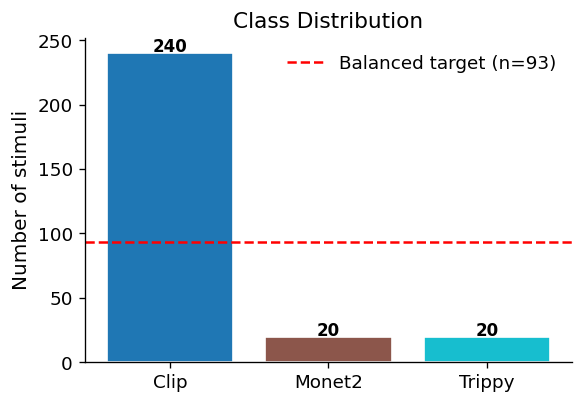

In [9]:
unique_labels  = sorted(set(labels))
n_types        = len(unique_labels)
palette        = plt.cm.get_cmap('tab10', n_types)
label_to_color = {lbl: palette(i) for i, lbl in enumerate(unique_labels)}
le             = LabelEncoder()
y              = le.fit_transform(labels)
counts         = {lbl: int(np.sum(labels == lbl)) for lbl in unique_labels}
majority_frac  = max(counts.values()) / len(labels)
chance_level   = 1.0 / n_types
legend_patches = [Patch(color=label_to_color[l], label=l) for l in unique_labels]

print("Stimulus distribution:")
for lbl, n in counts.items():
    print(f"{lbl:22s}  n={n:4d}  ({100*n/len(labels):.1f}%)")
print(f"\nMajority-class baseline: {majority_frac:.3f}")

rng_bal = np.random.default_rng(seed=SEED)
N_BAL = int(min(counts.values()))
bal_idx = np.sort(np.concatenate([
    rng_bal.choice(np.where(labels == lbl)[0], size=N_BAL, replace=False)
    for lbl in unique_labels
]))
y_bal = y[bal_idx]
labels_bal = labels[bal_idx]
R_bal = R_scaled[bal_idx]

print(f"\nBalanced subsample: {N_BAL} per class * {n_types} = {len(bal_idx)} total")

cv_bal  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
clf_bal = LogisticRegression(max_iter=2000, C=1.0, random_state=SEED, class_weight='balanced')

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(list(counts.keys()), list(counts.values()),
              color=[label_to_color[l] for l in counts], edgecolor='white')
ax.axhline(len(labels) / n_types, color='red', ls='--',
           label=f'Balanced target (n={len(labels)//n_types})')
for bar, v in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(v), ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Number of stimuli')
ax.set_title('Class Distribution')
ax.legend(); plt.tight_layout()
plt.savefig('fig_class_balance.png', dpi=150); plt.show()

### Dimensionality Reduction

We apply four complementary methods. Visualisations below use the first two dimensions only. **Note on methodology:** PCA, t-SNE, UMAP, and CEBRA are all fitted on the *entire* dataset here, and classification is evaluated on those same fixed 2-D coordinates via `StratifiedKFold`. This constitutes a mild form of train-test leakage for the non-linear methods — the 2-D metrics should be treated as *illustrative*. Part II corrects this with fold-local fitting and `GroupKFold`.

#### PCA

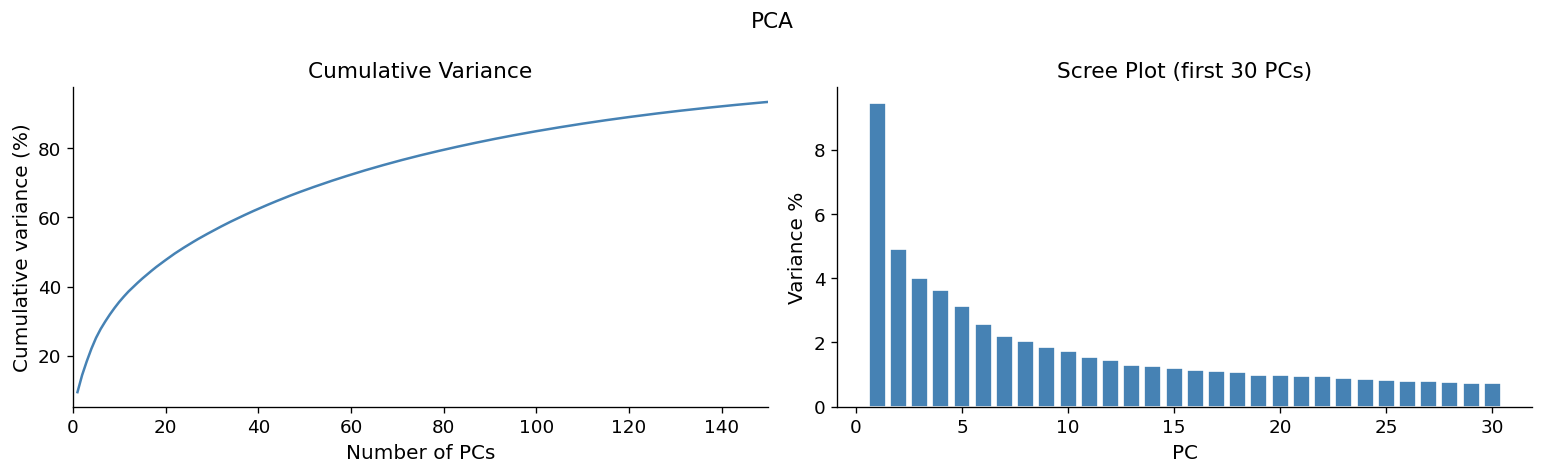

PCs for 80% variance: 82
PCs for 90% variance: 126
Variance in PC1: 9.47%
Variance in PC1+PC2: 14.39%
Variance in PC1-PC10: 35.56%
Participation ratio (eff dim): 47.2


In [10]:
n_pcs = min(150, R_scaled.shape[0] - 1, R_scaled.shape[1] - 1)
pca = PCA(n_components=n_pcs, random_state=SEED)
R_pca = pca.fit_transform(R_scaled)
cumvar = np.cumsum(pca.explained_variance_ratio_)
ev = pca.explained_variance_ratio_
participation_ratio = 1.0 / np.sum(ev ** 2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(np.arange(1, n_pcs + 1), cumvar * 100, '-', lw=1.5, color='steelblue')
axes[0].set_xlabel('Number of PCs'); axes[0].set_ylabel('Cumulative variance (%)')
axes[0].set_title('Cumulative Variance'); axes[0].legend(); axes[0].set_xlim(0, n_pcs)

axes[1].bar(np.arange(1, 31), ev[:30] * 100, color='steelblue', edgecolor='white')
axes[1].set_xlabel('PC'); axes[1].set_ylabel('Variance %')
axes[1].set_title('Scree Plot (first 30 PCs)')

plt.suptitle('PCA', fontsize=13)
plt.tight_layout()
plt.savefig('fig_pca_variance.png', dpi=150); plt.show()

n80 = min(int(np.searchsorted(cumvar, 0.80)) + 1, n_pcs)
n90 = min(int(np.searchsorted(cumvar, 0.90)) + 1, n_pcs)
print(f"PCs for 80% variance: {n80}")
print(f"PCs for 90% variance: {n90}")
print(f"Variance in PC1: {ev[0]*100:.2f}%")
print(f"Variance in PC1+PC2: {cumvar[1]*100:.2f}%")
print(f"Variance in PC1-PC10: {cumvar[9]*100:.2f}%")
print(f"Participation ratio (eff dim): {participation_ratio:.1f}")

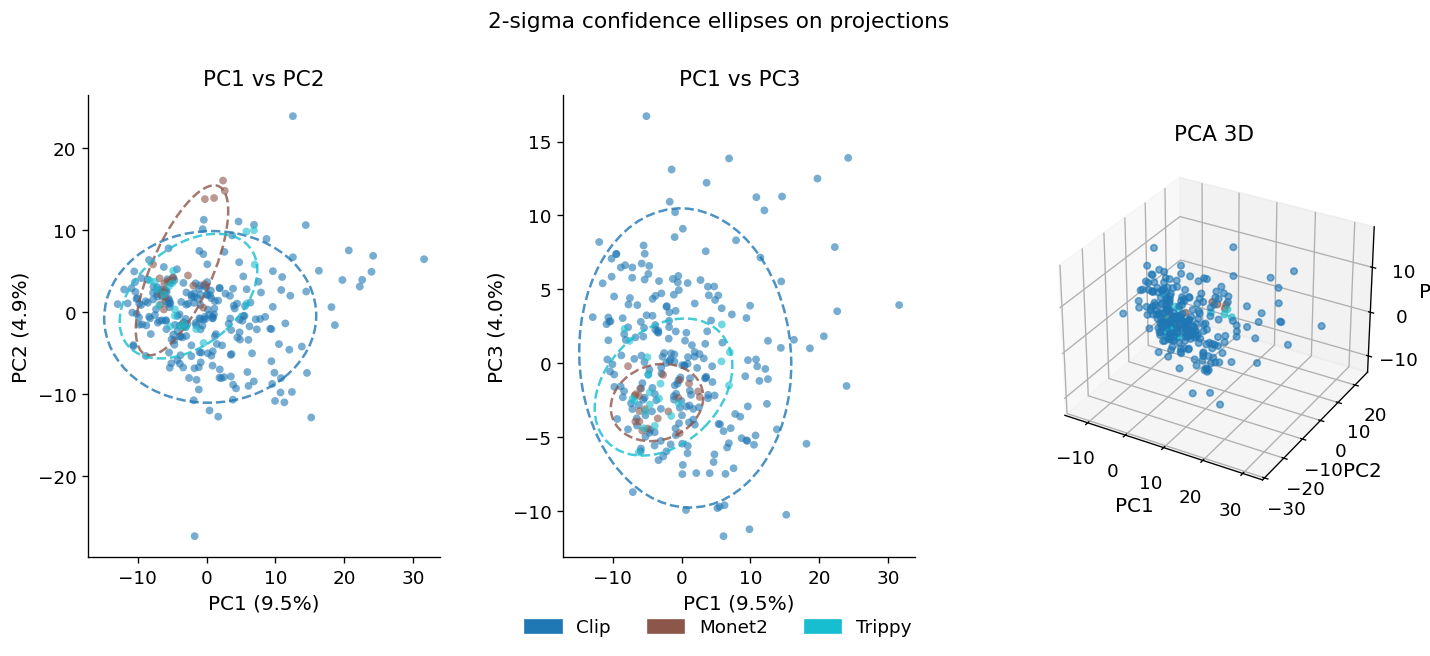

In [11]:
def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    if len(x) < 3: return
    cov = np.cov(x, y)
    pearson = cov[0,1] / np.sqrt(cov[0,0] * cov[1,1])
    rx, ry = np.sqrt(1 + pearson), np.sqrt(1 - pearson)
    scale_x = np.sqrt(cov[0,0]) * n_std
    scale_y = np.sqrt(cov[1,1]) * n_std
    ellipse = Ellipse((0,0), width=rx*2, height=ry*2, **kwargs)
    t = (transforms.Affine2D().rotate_deg(45)
         .scale(scale_x, scale_y).translate(x.mean(), y.mean()))
    ellipse.set_transform(t + ax.transData)
    return ax.add_patch(ellipse)

fig = plt.figure(figsize=(14, 5))
gs  = GridSpec(1, 3, figure=fig, wspace=0.35)

for col, (xi, yi, title) in enumerate([
        (0, 1, f'PC1 vs PC2'),
        (0, 2, f'PC1 vs PC3'),
        (None, None, 'PCA 3D')]):
    if col < 2:
        ax = fig.add_subplot(gs[col])
        for lbl in unique_labels:
            m = labels == lbl
            ax.scatter(R_pca[m,xi], R_pca[m,yi], color=label_to_color[lbl],
                       alpha=0.6, s=22, edgecolors='none', label=lbl)
            confidence_ellipse(R_pca[m,xi], R_pca[m,yi], ax, n_std=2,
                               edgecolor=label_to_color[lbl], facecolor='none',
                               lw=1.5, ls='--', alpha=0.8)
        ax.set_xlabel(f'PC{xi+1} ({ev[xi]*100:.1f}%)')
        ax.set_ylabel(f'PC{yi+1} ({ev[yi]*100:.1f}%)')
        ax.set_title(title)
    else:
        ax = fig.add_subplot(gs[2], projection='3d')
        for lbl in unique_labels:
            m = labels == lbl
            ax.scatter(R_pca[m,0], R_pca[m,1], R_pca[m,2],
                       color=label_to_color[lbl], alpha=0.6, s=15)
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
        ax.set_title('PCA 3D')

fig.legend(handles=legend_patches, loc='lower center', ncol=n_types,
           bbox_to_anchor=(0.5, -0.05))
plt.suptitle('2-sigma confidence ellipses on projections', fontsize=13, y=1.02)
plt.savefig('fig_pca_scatter.png', dpi=150); plt.show()

#### t-SNE

running


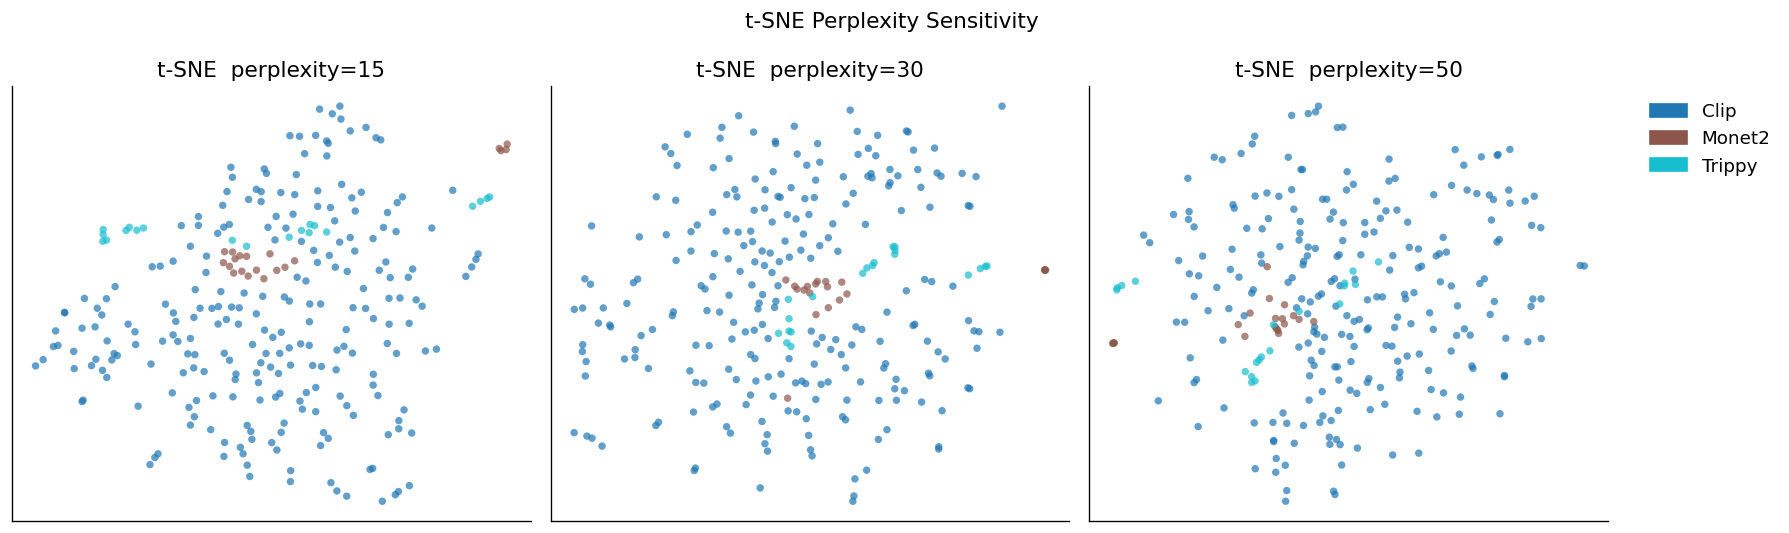

In [12]:
n_pca_for_tsne = min(50, n_pcs)
tsne_results = {}
PERPLEXITIES = [15, 30, 50]

print("running")
for perp in PERPLEXITIES:
    tsne = TSNE(n_components=2, perplexity=perp, random_state=SEED,
                max_iter=1000, learning_rate='auto', init='pca')
    tsne_results[perp] = tsne.fit_transform(R_pca[:, :n_pca_for_tsne])

R_tsne = tsne_results[30]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, perp in zip(axes, PERPLEXITIES):
    for lbl in unique_labels:
        m = labels == lbl
        ax.scatter(tsne_results[perp][m,0], tsne_results[perp][m,1],
                   color=label_to_color[lbl], alpha=0.7, s=20, edgecolors='none')
    ax.set_title(f't-SNE  perplexity={perp}')
    ax.set_xticks([]); ax.set_yticks([])
axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left')
plt.suptitle('t-SNE Perplexity Sensitivity', fontsize=13)
plt.tight_layout()
plt.savefig('fig_tsne_perplexity.png', dpi=150)
plt.show()

#### UMAP

running


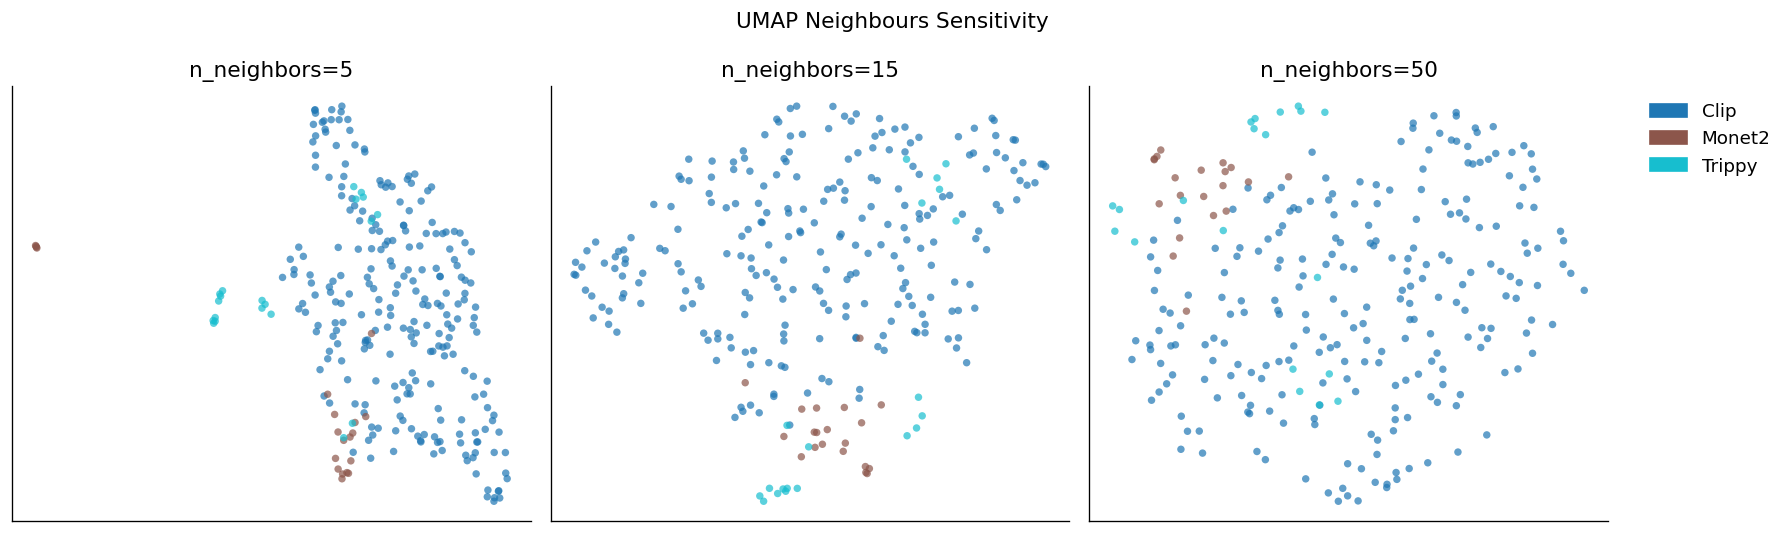

In [13]:
R_umap = None
if UMAP_AVAILABLE:
    umap_results = {}
    N_NEIGHBORS_LIST = [5, 15, 50]
    print("running")
    for nn in N_NEIGHBORS_LIST:
        reducer = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=0.1,
                            metric='euclidean', random_state=SEED)
        umap_results[nn] = reducer.fit_transform(R_pca[:, :n_pca_for_tsne])
    R_umap = umap_results[15]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, nn in zip(axes, N_NEIGHBORS_LIST):
        for lbl in unique_labels:
            m = labels == lbl
            ax.scatter(umap_results[nn][m,0], umap_results[nn][m,1],
                       color=label_to_color[lbl], alpha=0.7, s=20, edgecolors='none')
        ax.set_title(f'n_neighbors={nn}')
        ax.set_xticks([]); ax.set_yticks([])
    axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left')
    plt.suptitle('UMAP Neighbours Sensitivity', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig_umap_neighbors.png', dpi=150)
    plt.show()

#### CEBRA (Visualization Only)

CEBRA is a contrastive-learning encoder that takes a *time-series* as input. On trial-averaged data it receives only one vector per stimulus — it sees no temporal context. The embedding below is therefore purely illustrative and **must not** be used for quantitative decoding in this part.

  0%|          | 0/2000 [00:00<?, ?it/s]

pos: -0.3144 neg:  5.2447 total:  4.9303 temperature:  1.0000:   0%|          | 0/2000 [00:00<?, ?it/s]

pos: -0.3144 neg:  5.2447 total:  4.9303 temperature:  1.0000:   0%|          | 1/2000 [00:00<05:28,  6.09it/s]

pos: -0.4839 neg:  5.2637 total:  4.7798 temperature:  1.0000:   0%|          | 1/2000 [00:00<05:28,  6.09it/s]

pos: -0.5117 neg:  5.2602 total:  4.7485 temperature:  1.0000:   0%|          | 1/2000 [00:00<05:28,  6.09it/s]

...

pos: -0.5662 neg:  5.2950 total:  4.7289 temperature:  1.0000: 100%|█████████▉| 1994/2000 [00:30<00:00, 66.14it/s]

pos: -0.5682 neg:  5.2933 total:  4.7250 temperature:  1.0000: 100%|█████████▉| 1994/2000 [00:30<00:00, 66.14it/s]

pos: -0.5440 neg:  5.2561 total:  4.7121 temperature:  1.0000: 100%|█████████▉| 1994/2000 [00:30<00:00, 66.14it/s]

pos: -0.5219 neg:  5.2614 total:  4.7394 temperature:  1.0000: 100%|█████████▉| 1994/2000 [00:30<00:00, 66.14it/s]

pos: -0.5219 neg:  5.2614 total:  4.7394 temperature:  1.0000: 100%|██████████| 2000/2000 [00:30<00:00, 65.27it/s]

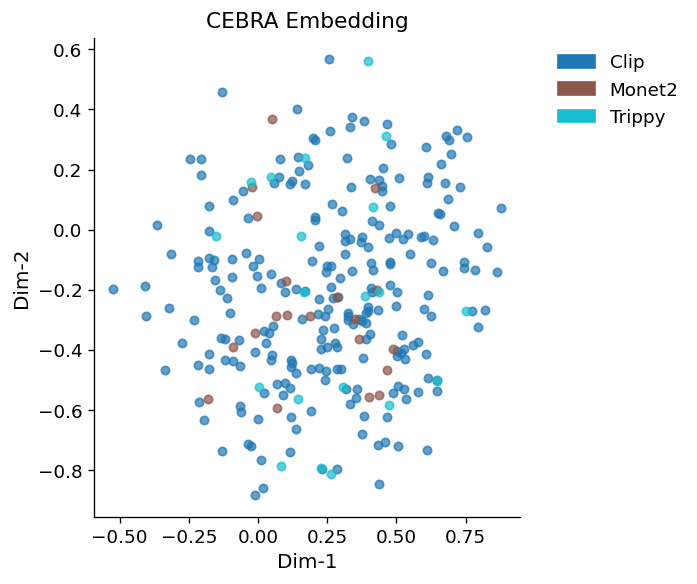

In [14]:
R_cebra = None

if CEBRA_AVAILABLE:
    try:
        import torch
        label_cont = y.astype(np.float32).reshape(-1, 1)
        cb_model = cebra.CEBRA(
            model_architecture='offset10-model',
            batch_size=min(512, len(R_scaled)//2),
            learning_rate=3e-4,
            temperature=1.0,
            output_dimension=8,
            max_iterations=2000,
            device='cpu',
            verbose=True,
        )
        cb_model.fit(R_scaled.astype(np.float32), label_cont)
        R_cebra = cb_model.transform(R_scaled.astype(np.float32))

        fig, ax = plt.subplots(figsize=(6,5))
        for lbl in unique_labels:
            m = labels == lbl
            ax.scatter(R_cebra[m,0], R_cebra[m,1], color=label_to_color[lbl],
                       alpha=0.7, s=25, label=lbl)
        ax.set_title('CEBRA Embedding')
        ax.set_xlabel('Dim-1'); ax.set_ylabel('Dim-2')
        ax.legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left')
        plt.tight_layout()
        plt.savefig('fig_cebra.png', dpi=150); plt.show()
    except Exception as e:
        print(f"CEBRA failed: {e}")
        R_cebra = None
else:
    print("CEBRA not installed")

#### DR Comparison

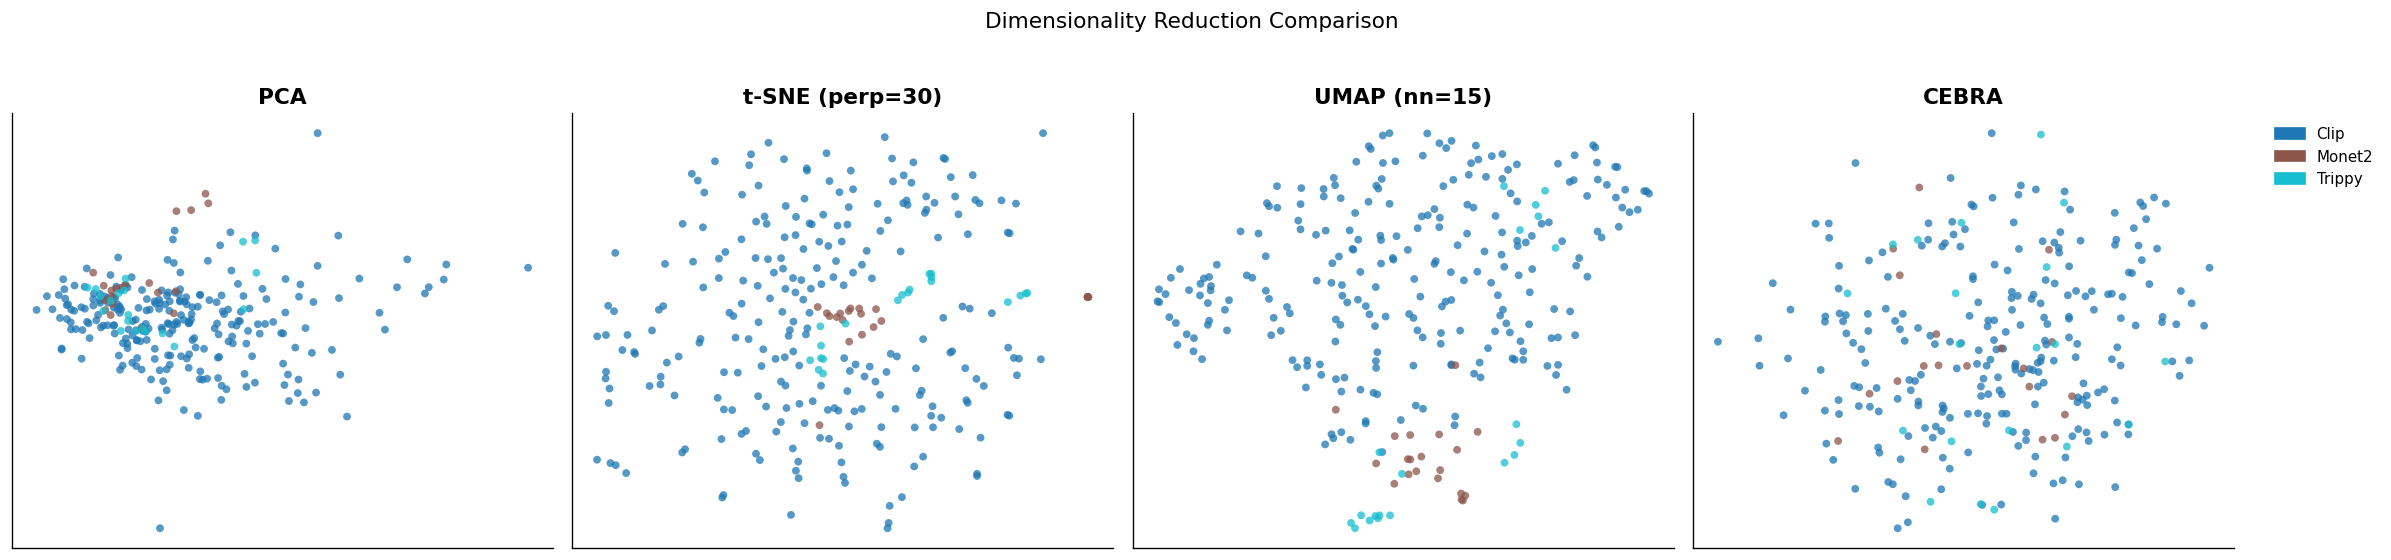

In [15]:
methods = [('PCA', R_pca[:, :2]), ('t-SNE (perp=30)', R_tsne)]
if UMAP_AVAILABLE  and R_umap  is not None: methods.append(('UMAP (nn=15)',  R_umap))
if CEBRA_AVAILABLE and R_cebra is not None: methods.append(('CEBRA', R_cebra[:, :2]))

fig, axes = plt.subplots(1, len(methods), figsize=(5 * len(methods), 4.5))
if len(methods) == 1: axes = [axes]

for ax, (name, emb) in zip(axes, methods):
    for lbl in unique_labels:
        m = labels == lbl
        ax.scatter(emb[m,0], emb[m,1], color=label_to_color[lbl],
                   alpha=0.75, s=22, edgecolors='none')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left', fontsize=9)
plt.suptitle('Dimensionality Reduction Comparison',
             fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig('fig_dr_comparison.png', dpi=150); plt.show()

### Quantitative Evaluation

Logistic regression on each 2-D embedding, evaluated with `StratifiedKFold(n_splits=5)` on the class-balanced subsample. Metrics: balanced accuracy, macro F1, silhouette score.

> Reminder: embeddings are pre-computed on all data, so leakage exists for UMAP/t-SNE/CEBRA. These figures motivate the rigorous evaluation in Part II.

In [16]:
sil_scores = {}
for name, emb in methods:
    sil_scores[name] = silhouette_score(emb, y)
for k in [2, 5, 10, 20, 50]:
    if k < R_pca.shape[1]:
        sil_scores[f'PCA-{k}D'] = silhouette_score(R_pca[:, :k], y)

n_pca_bal = min(50, len(bal_idx) - 1)
pca_bal = PCA(n_components=n_pca_bal, random_state=SEED)
RB_pca = pca_bal.fit_transform(R_bal)

perp_bal = max(5, min(15, len(bal_idx) // 5))
tsne_bal = TSNE(n_components=2, perplexity=perp_bal, random_state=SEED,
                max_iter=1000, learning_rate='auto', init='pca')
RB_tsne = tsne_bal.fit_transform(RB_pca[:, :min(20, n_pca_bal)])

RB_umap = None
if UMAP_AVAILABLE:
    nn_bal  = max(5, min(10, len(bal_idx) // 6))
    umap_bal = umap.UMAP(n_components=2, n_neighbors=nn_bal, min_dist=0.1,
                         random_state=SEED)
    RB_umap = umap_bal.fit_transform(RB_pca[:, :min(20, n_pca_bal)])

sil_bal = {}
sil_bal['PCA (balanced)']   = silhouette_score(RB_pca[:, :2], y_bal)
sil_bal['t-SNE (balanced)'] = silhouette_score(RB_tsne, y_bal)
if RB_umap is not None:
    sil_bal['UMAP (balanced)'] = silhouette_score(RB_umap, y_bal)

print("Silhouette — FULL dataset")
for name, sc in sorted(sil_scores.items(), key=lambda x: -x[1]):
    print(f"{name:25s}  {sc:+.4f}")
print("\nSilhouette — BALANCED subsample")
for name, sc in sorted(sil_bal.items(), key=lambda x: -x[1]):
    print(f"{name:25s}  {sc:+.4f}")

Silhouette — FULL dataset
UMAP (nn=15)               +0.1247
CEBRA                      -0.0935
t-SNE (perp=30)            -0.1088
PCA-10D                    -0.1137
PCA-20D                    -0.1192
PCA                        -0.1269
PCA-2D                     -0.1269
PCA-5D                     -0.1285
PCA-50D                    -0.1313

Silhouette — BALANCED subsample
UMAP (balanced)            +0.1097
t-SNE (balanced)           +0.0924
PCA (balanced)             +0.0124


In [17]:
clf_scores     = {}
clf_scores_bal = {}
clf_scores_f1  = {}

for name, emb in methods:
    clf_scores[name]     = cross_val_score(clf_bal, emb, y, cv=cv_bal,
                               scoring='accuracy').mean()
    clf_scores_bal[name] = cross_val_score(clf_bal, emb, y, cv=cv_bal,
                               scoring='balanced_accuracy').mean()
    clf_scores_f1[name]  = cross_val_score(clf_bal, emb, y, cv=cv_bal,
                               scoring='f1_macro').mean()

from sklearn.metrics import classification_report
print("Accuracy Per Class")
for name, emb in methods:
    y_pred = cross_val_predict(clf_bal, emb, y, cv=cv_bal)
    print(f"\n{name}")
    print(classification_report(y, y_pred, target_names=le.classes_))

print(f"\nBalanced accuracy (chance={chance_level:.3f}, majority baseline={majority_frac:.3f})")
for name, bacc in sorted(clf_scores_bal.items(), key=lambda x: -x[1]):
    f1 = clf_scores_f1.get(name, float('nan'))
    print(f"{name:25s}  bal_acc={bacc:.4f}  F1_macro={f1:.4f}")

Accuracy Per Class

PCA
              precision    recall  f1-score   support

        Clip       0.94      0.60      0.73       240
      Monet2       0.19      0.65      0.29        20
      Trippy       0.05      0.15      0.08        20

    accuracy                           0.57       280
   macro avg       0.39      0.47      0.37       280
weighted avg       0.82      0.57      0.65       280


t-SNE (perp=30)
              precision    recall  f1-score   support

        Clip       0.89      0.60      0.72       240
      Monet2       0.07      0.20      0.10        20
      Trippy       0.14      0.40      0.21        20

    accuracy                           0.56       280
   macro avg       0.37      0.40      0.34       280
weighted avg       0.78      0.56      0.64       280


UMAP (nn=15)
              precision    recall  f1-score   support

        Clip       0.96      0.75      0.84       240
      Monet2       0.43      0.75      0.55        20
      Trippy       0

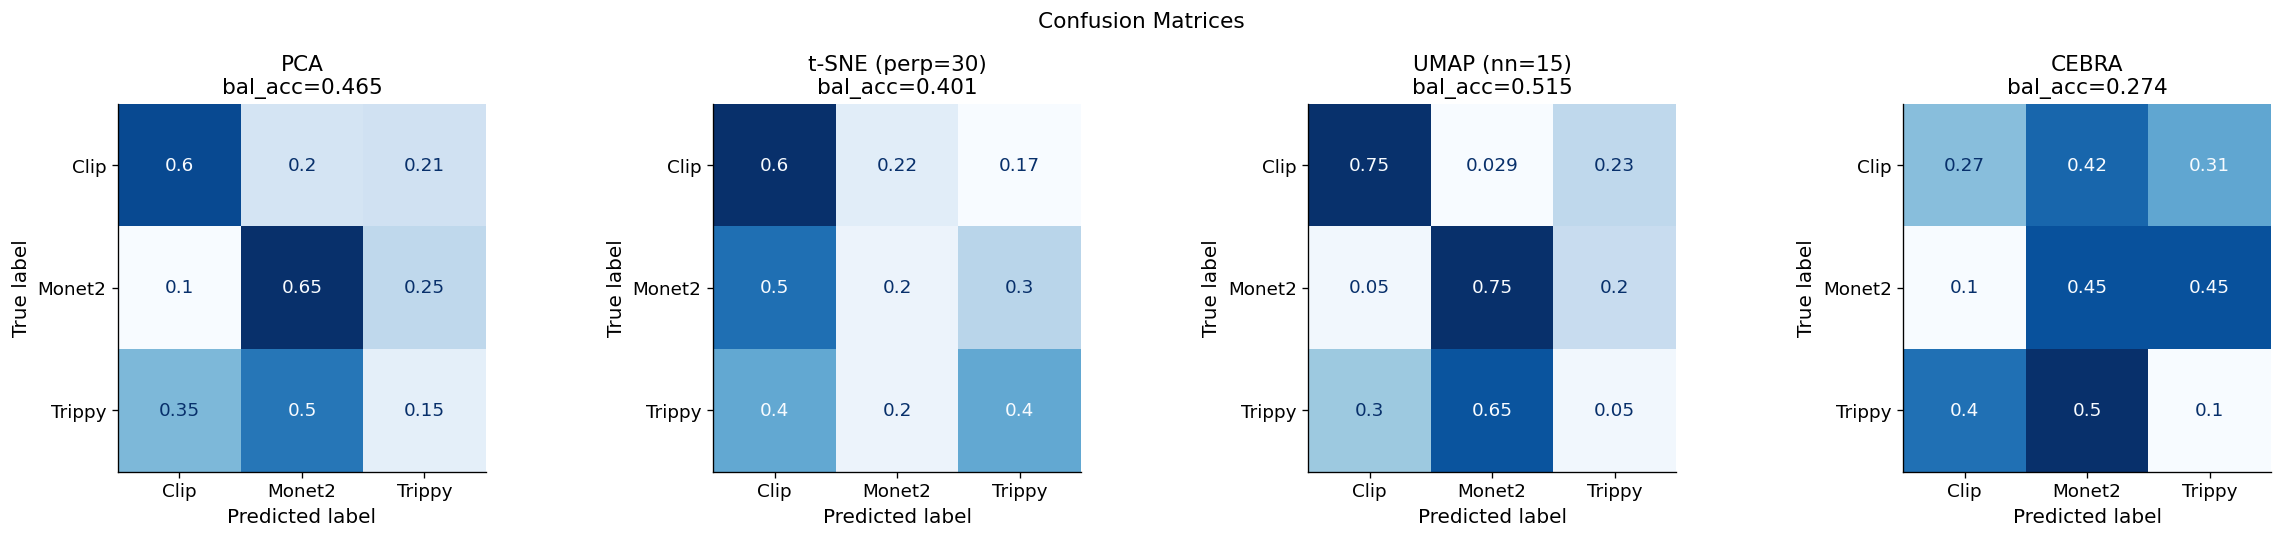

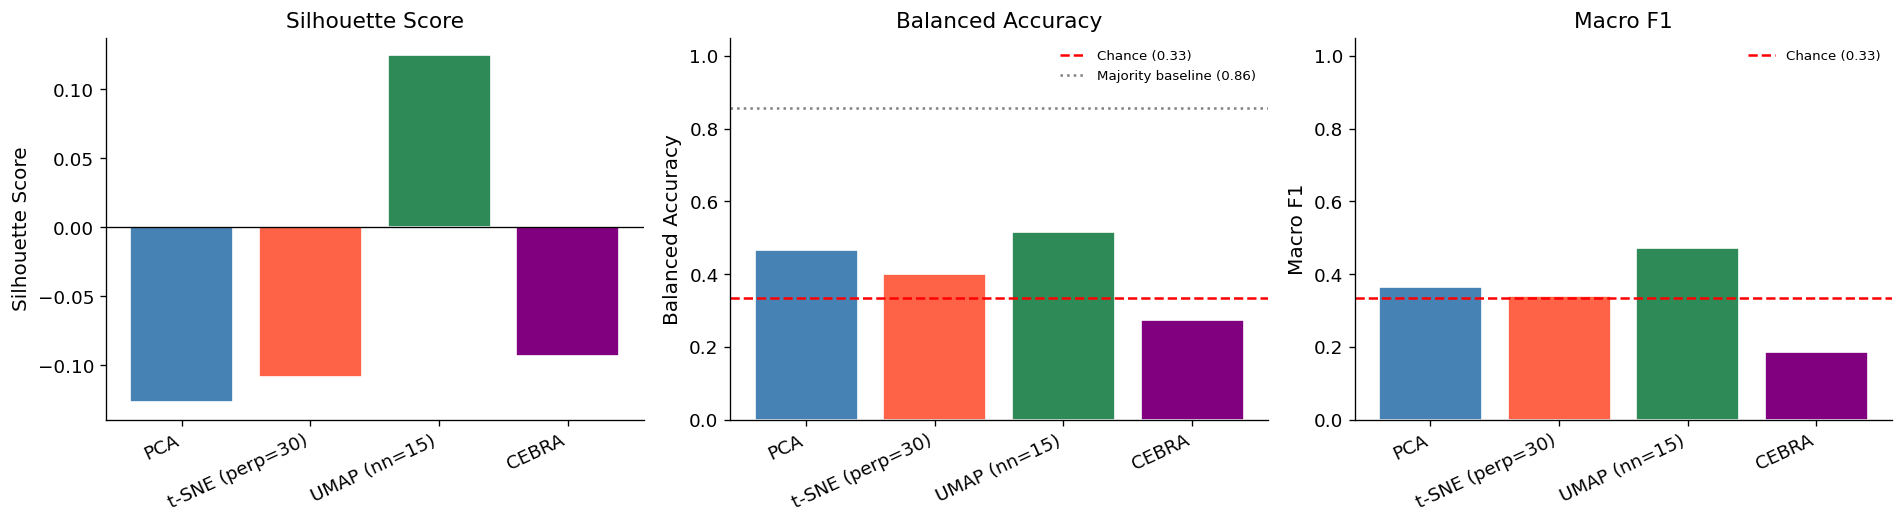

In [18]:
fig, axes = plt.subplots(1, len(methods), figsize=(5*len(methods), 4.5))
if len(methods) == 1: axes = [axes]

for ax, (name, emb) in zip(axes, methods):
    y_pred = cross_val_predict(clf_bal, emb, y, cv=cv_bal)
    cm = confusion_matrix(y, y_pred, normalize='true')
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, colorbar=False, cmap='Blues')
    bacc = clf_scores_bal.get(name, float('nan'))
    ax.set_title(f'{name}\nbal_acc={bacc:.3f}')

plt.suptitle('Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=150); plt.show()

plot_names = [m[0] for m in methods]
colors_m   = ['steelblue', 'tomato', 'seagreen', 'purple'][:len(plot_names)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sil_vals = [sil_scores.get(n, np.nan) for n in plot_names]
bars = axes[0].bar(plot_names, sil_vals, color=colors_m, edgecolor='white')
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_title('Silhouette Score')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_xticklabels(plot_names, rotation=25, ha='right')

bal_vals = [clf_scores_bal.get(n, np.nan) for n in plot_names]
axes[1].bar(plot_names, bal_vals, color=colors_m, edgecolor='white')
axes[1].axhline(chance_level, color='red', ls='--', label=f'Chance ({chance_level:.2f})')
axes[1].axhline(majority_frac, color='gray', ls=':', lw=1.5,
                label=f'Majority baseline ({majority_frac:.2f})')
axes[1].set_title('Balanced Accuracy')
axes[1].set_ylabel('Balanced Accuracy')
axes[1].set_xticklabels(plot_names, rotation=25, ha='right')
axes[1].set_ylim(0, 1.05); axes[1].legend(fontsize=8)

f1_vals = [clf_scores_f1.get(n, np.nan) for n in plot_names]
axes[2].bar(plot_names, f1_vals, color=colors_m, edgecolor='white')
axes[2].axhline(chance_level, color='red', ls='--', label=f'Chance ({chance_level:.2f})')
axes[2].set_title('Macro F1')
axes[2].set_ylabel('Macro F1')
axes[2].set_xticklabels(plot_names, rotation=25, ha='right')
axes[2].set_ylim(0, 1.05); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_quantitative.png', dpi=150); plt.show()

### Shuffle Control

Labels are permuted at the *stimulus* level (each unique hash gets a randomly assigned class) and the full pipeline is repeated 100 times. This yields an empirical null distribution. A one-sided t-test checks whether the real score exceeds the null mean.

In [19]:
N_SHUFFLES = 100
rng_shuf = np.random.default_rng(seed=SEED)

null_sil = {name: [] for name, _ in methods}
null_bal = {name: [] for name, _ in methods}
null_f1 = {name: [] for name, _ in methods}

print(f"running")
for i in range(N_SHUFFLES):
    y_s = rng_shuf.permutation(y)
    for name, emb in methods:
        null_sil[name].append(silhouette_score(emb, y_s))
        null_bal[name].append(
            cross_val_score(clf_bal, emb, y_s, cv=cv_bal,
                            scoring='balanced_accuracy').mean())
        null_f1[name].append(
            cross_val_score(clf_bal, emb, y_s, cv=cv_bal,
                            scoring='f1_macro').mean())

null_sil = {k: np.array(v) for k, v in null_sil.items()}
null_bal = {k: np.array(v) for k, v in null_bal.items()}
null_f1 = {k: np.array(v) for k, v in null_f1.items()}

print("\nShuffle control results:")
print(f"{'Method':<22} {'Metric':<18} {'Real':>7} {'Null µ':>8} {'Null σ':>8} {'p':>8}")
for name, emb in methods:
    for metric, null_arr, real_val in [
            ('Silhouette',   null_sil[name], sil_scores.get(name, float('nan'))),
            ('Balanced acc', null_bal[name], clf_scores_bal.get(name, float('nan'))),
            ('Macro F1',     null_f1[name],  clf_scores_f1.get(name, float('nan')))]:
        _, p = ttest_1samp(null_arr, real_val, alternative='less')
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f"  {name:<20} {metric:<18} {real_val:>7.4f} "
              f"{null_arr.mean():>8.4f} {null_arr.std():>8.4f} {p:>7.4f} {sig}")
    print()

running



Shuffle control results:
Method                 Metric                Real   Null µ   Null σ        p
  PCA                  Silhouette         -0.1269  -0.0667   0.0579  1.0000 ns
  PCA                  Balanced acc        0.4653   0.3345   0.0537  0.0000 ***
  PCA                  Macro F1            0.3641   0.2323   0.0422  0.0000 ***

  t-SNE (perp=30)      Silhouette         -0.1088  -0.0573   0.0341  1.0000 ns
  t-SNE (perp=30)      Balanced acc        0.4014   0.3447   0.0564  0.0000 ***
  t-SNE (perp=30)      Macro F1            0.3394   0.2308   0.0430  0.0000 ***

  UMAP (nn=15)         Silhouette          0.1247  -0.0567   0.0294  0.0000 ***
  UMAP (nn=15)         Balanced acc        0.5153   0.3197   0.0620  0.0000 ***
  UMAP (nn=15)         Macro F1            0.4707   0.2151   0.0393  0.0000 ***

  CEBRA                Silhouette         -0.0935  -0.0462   0.0336  1.0000 ns
  CEBRA                Balanced acc        0.2736   0.3301   0.0597  1.0000 ns
  CEBRA           

### Within-Clip Temporal Structure

As a qualitative sanity check we extract single-frame responses from movie-clip trials and embed them with t-SNE. Nearby time points should cluster together if V1 represents stimulus-locked dynamics.

Movielike stimulus types: [np.str_('Clip')]
running


Frame matrix: (5760, 579)  (240 unique clips)


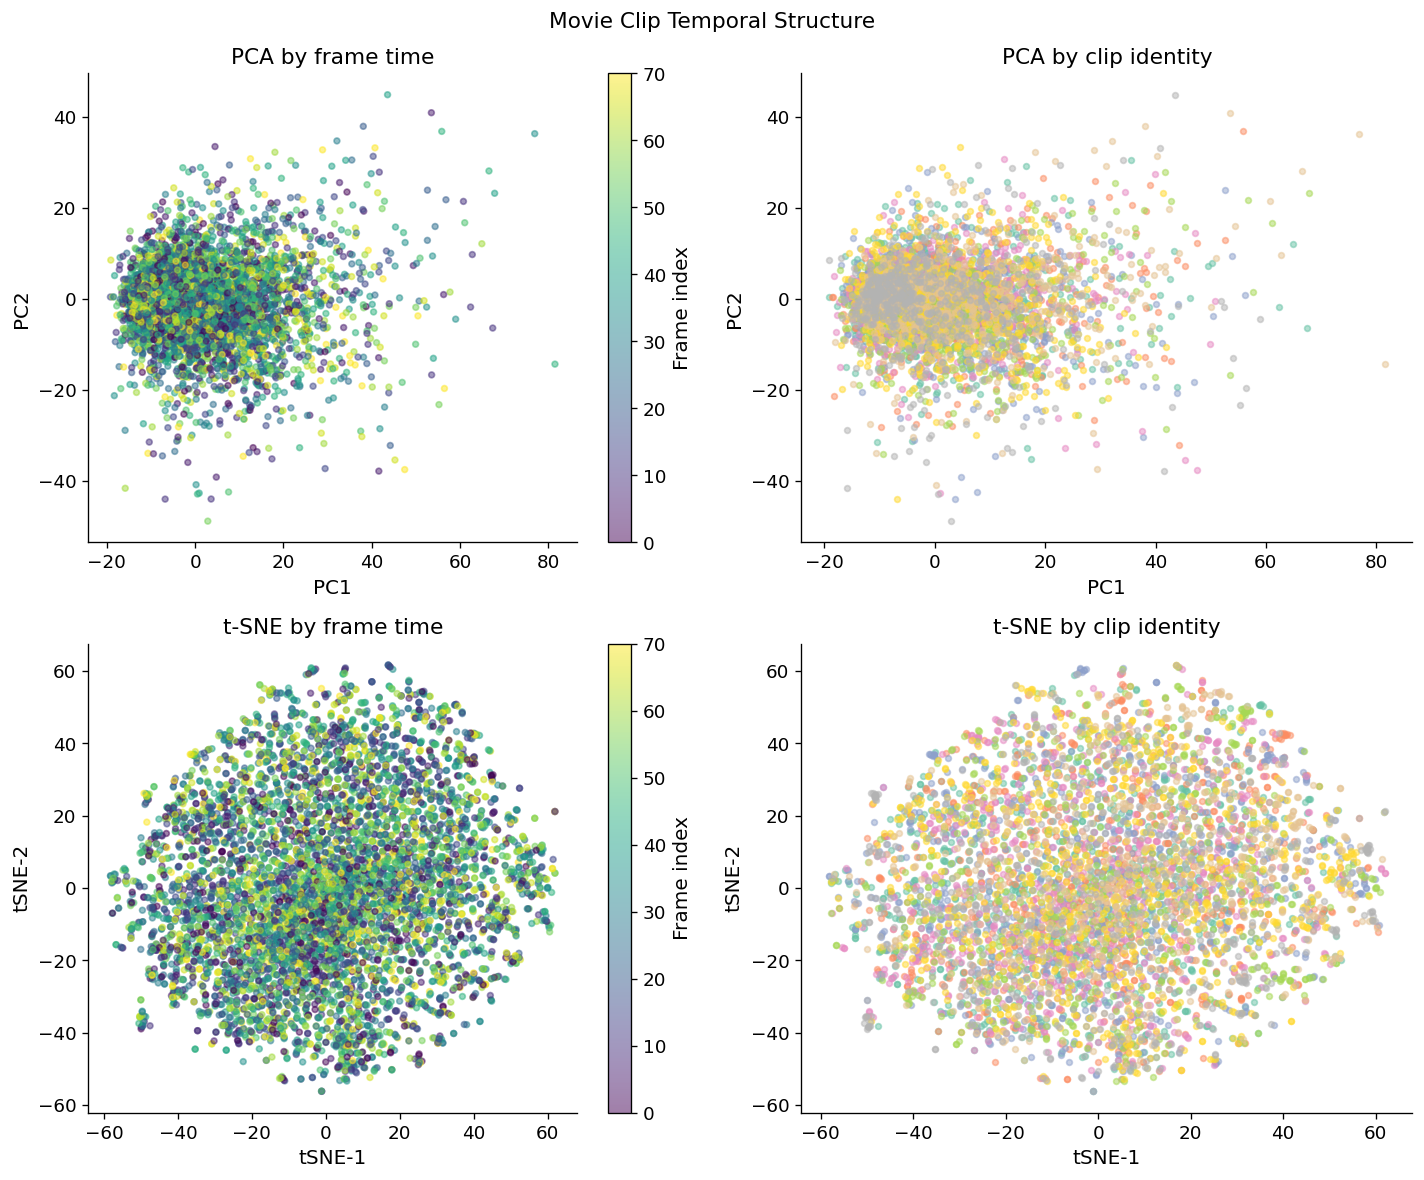

In [20]:
movie_types = [l for l in unique_labels
               if any(kw in l.lower() for kw in ['clip','movie','natural','film'])]
if not movie_types:
    movie_types = [c for c, _ in Counter(labels).most_common(2)]
    print(f"Using: {movie_types}")
else:
    print(f"Movielike stimulus types: {movie_types}")

frame_resp, frame_time, frame_hash = [], [], []
STEP = 5

print("running")
for trial_idx, h in enumerate(hashes):
    if funcreader.get_video_type(h) not in movie_types:
        continue
    try:
        r = funcreader.get_trial(SESSION, trial_idx)
        if r is None or 'responses' not in r: continue
        resp_trusted = r['responses'][keep_neuron_cols, :]
        n_frames = resp_trusted.shape[1]
        for f in range(0, n_frames, STEP):
            frame_resp.append(resp_trusted[:, f])
            frame_time.append(f)
            frame_hash.append(h)
    except Exception:
        continue

if not frame_resp:
    print("no movie clip trials found")
else:
    RF = np.array(frame_resp)
    frame_time = np.array(frame_time)
    frame_hash = np.array(frame_hash)
    RF_clean = np.nan_to_num(RF[:, keep_neurons], nan=0.0)
    RF_scaled = scaler.transform(RF_clean)
    RF_pca = pca.transform(RF_scaled)
    print(f"Frame matrix: {RF_scaled.shape}  ({len(np.unique(frame_hash))} unique clips)")

    tsne_fr = TSNE(n_components=2, perplexity=20, random_state=SEED,
                   max_iter=1000, learning_rate='auto', init='pca')
    RF_tsne = tsne_fr.fit_transform(RF_pca[:, :n_pca_for_tsne])

    unique_clips = np.unique(frame_hash)
    clip_cmap    = plt.cm.get_cmap('Set2', len(unique_clips))
    hash_to_col  = {h: clip_cmap(i) for i, h in enumerate(unique_clips)}

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    sc = axes[0,0].scatter(RF_pca[:,0], RF_pca[:,1], c=frame_time,
                           cmap='viridis', alpha=0.5, s=12)
    plt.colorbar(sc, ax=axes[0,0], label='Frame index')
    axes[0,0].set_title('PCA by frame time')
    axes[0,0].set_xlabel('PC1'); axes[0,0].set_ylabel('PC2')

    for h in unique_clips:
        m = frame_hash == h
        axes[0,1].scatter(RF_pca[m,0], RF_pca[m,1], color=hash_to_col[h], alpha=0.5, s=12)
    axes[0,1].set_title('PCA by clip identity')
    axes[0,1].set_xlabel('PC1'); axes[0,1].set_ylabel('PC2')

    sc2 = axes[1,0].scatter(RF_tsne[:,0], RF_tsne[:,1], c=frame_time,
                            cmap='viridis', alpha=0.5, s=12)
    plt.colorbar(sc2, ax=axes[1,0], label='Frame index')
    axes[1,0].set_title('t-SNE by frame time')
    axes[1,0].set_xlabel('tSNE-1'); axes[1,0].set_ylabel('tSNE-2')

    for h in unique_clips:
        m = frame_hash == h
        axes[1,1].scatter(RF_tsne[m,0], RF_tsne[m,1], color=hash_to_col[h], alpha=0.5, s=12)
    axes[1,1].set_title('t-SNE by clip identity')
    axes[1,1].set_xlabel('tSNE-1'); axes[1,1].set_ylabel('tSNE-2')

    plt.suptitle('Movie Clip Temporal Structure', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig_movie_temporal.png', dpi=150)
    plt.show()

### Neuron Space Analysis

Transpose the response matrix to embed *neurons* rather than stimuli. Colour by cortical layer and cell type.

Neuron space matrix: (579, 280)


Layer breakdown:
  L1: 1
  L2/3: 220
  L4: 257
  L5: 89
  L6: 12

Type breakdown:
  excitatory_neuron: 579


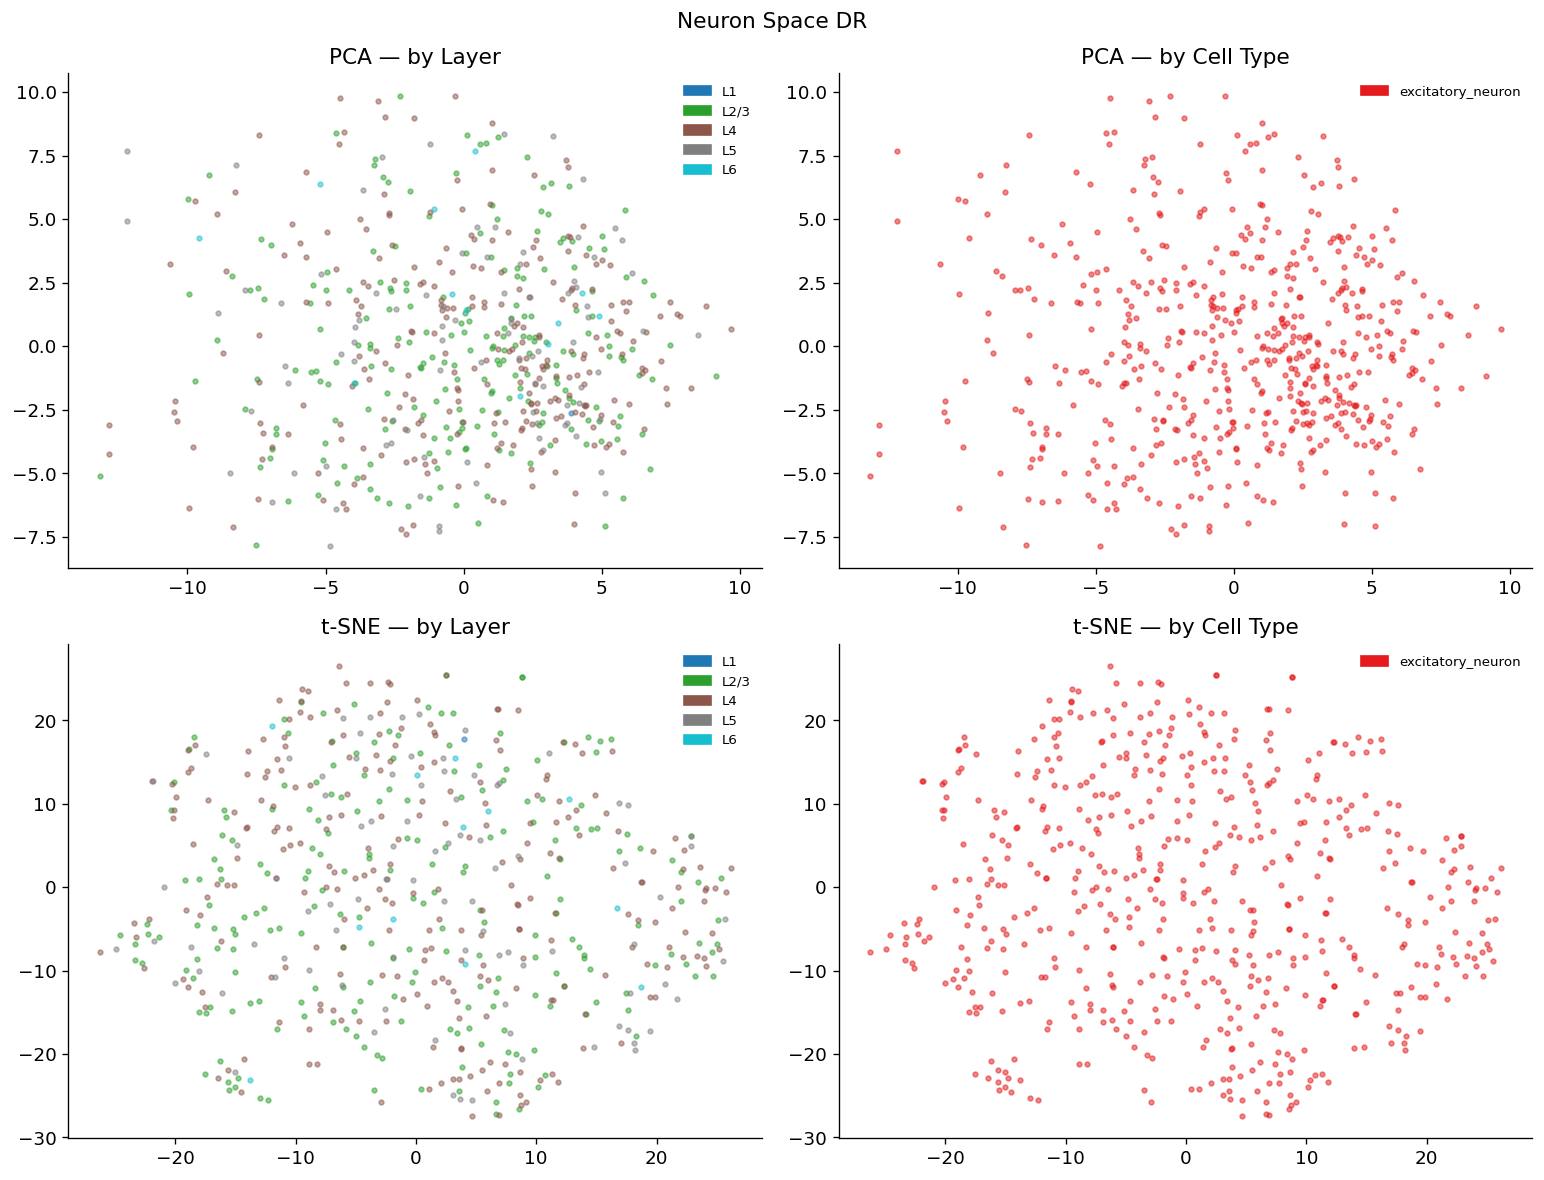

In [21]:
R_neuron = R_scaled.T
print(f"Neuron space matrix: {R_neuron.shape}")

pca_n = PCA(n_components=min(20, R_neuron.shape[1]-1), random_state=SEED)
RN_pca = pca_n.fit_transform(R_neuron)

tsne_n = TSNE(n_components=2, perplexity=min(30, len(R_neuron)//5),
              random_state=SEED, learning_rate='auto', init='pca')
RN_tsne = tsne_n.fit_transform(RN_pca)

neuron_layer = trusted_meta_clean['layer'].fillna('unknown').values
neuron_type  = trusted_meta_clean['classification_system'].fillna('unknown').values

print(f"Layer breakdown:")
for lyr, cnt in Counter(neuron_layer).items():
    print(f"  {lyr}: {cnt}")
print(f"\nType breakdown:")
for t, cnt in Counter(neuron_type).items():
    print(f"  {t}: {cnt}")

LAYERS = [l for l in ['L1','L2/3','L4','L5','L6','unknown'] if l in neuron_layer]
lyr_cmap  = plt.cm.get_cmap('tab10', len(LAYERS))
lyr_color = {l: lyr_cmap(i) for i, l in enumerate(LAYERS)}
lyr_patches = [Patch(color=lyr_color[l], label=l) for l in LAYERS]

TYPES = np.unique(neuron_type)
typ_cmap  = plt.cm.get_cmap('Set1', len(TYPES))
typ_color = {t: typ_cmap(i) for i, t in enumerate(TYPES)}
typ_patches = [Patch(color=typ_color[t], label=t) for t in TYPES]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for row, (embedname, emb) in enumerate([('PCA', RN_pca[:,:2]), ('t-SNE', RN_tsne)]):
    for lyr in LAYERS:
        m = neuron_layer == lyr
        axes[row,0].scatter(emb[m,0], emb[m,1], color=lyr_color[lyr], alpha=0.5, s=8)
    axes[row,0].set_title(f'{embedname} — by Layer')
    axes[row,0].legend(handles=lyr_patches, markerscale=3, fontsize=8)

    for t in TYPES:
        m = neuron_type == t
        axes[row,1].scatter(emb[m,0], emb[m,1], color=typ_color[t], alpha=0.5, s=8)
    axes[row,1].set_title(f'{embedname} — by Cell Type')
    axes[row,1].legend(handles=typ_patches, markerscale=3, fontsize=8)

plt.suptitle('Neuron Space DR', fontsize=13)
plt.tight_layout()
plt.savefig('fig_neuron_space.png', dpi=150); plt.show()

### Part I Summary

Tabulate silhouette, balanced accuracy, and macro F1 for each dimensionality-reduction method. All metrics are on the balanced subsample with `StratifiedKFold`.

In [22]:
summary_rows = []
for name, emb in methods:
    summary_rows.append({
        'Method': name,
        'Silhouette': f"{sil_scores.get(name, float('nan')):.4f}",
        'Std Accuracy': f"{clf_scores.get(name, float('nan')):.4f}",
        'Balanced Accuracy': f"{clf_scores_bal.get(name, float('nan')):.4f}",
        'Macro F1': f"{clf_scores_f1.get(name, float('nan')):.4f}",
    })

print('\nResults Summary')
print(pd.DataFrame(summary_rows).to_string(index=False))
print(f'\nBaselines:')
print(f'Always predict Clip (majority): {majority_frac:.4f}')
print(f'Uniform chance (balanced acc): {chance_level:.4f}')
print(f'\nIntrinsic dimensionality:')
print(f'PCs for 80% variance: {n80}')
print(f'PCs for 90% variance: {n90}')
print(f'Variance in PC1+PC2: {cumvar[1]*100:.2f}%')
print(f'Participation ratio (eff dim): {participation_ratio:.1f}')
print(f'\nNeurons used: {R_scaled.shape[1]} trusted (from {len(session_unit_ids)} recorded)')


Results Summary
         Method Silhouette Std Accuracy Balanced Accuracy Macro F1
            PCA    -0.1269       0.5679            0.4653   0.3641
t-SNE (perp=30)    -0.1088       0.5607            0.4014   0.3394
   UMAP (nn=15)     0.1247       0.6964            0.5153   0.4707
          CEBRA    -0.0935       0.2714            0.2736   0.1853

Baselines:
Always predict Clip (majority): 0.8571
Uniform chance (balanced acc): 0.3333

Intrinsic dimensionality:
PCs for 80% variance: 82
PCs for 90% variance: 126
Variance in PC1+PC2: 14.39%
Participation ratio (eff dim): 47.2

Neurons used: 579 trusted (from 7855 recorded)


### Layer-Specific Analysis

Repeat the Part I pipeline restricted to L4 and L2/3 neurons separately. L4 is the primary thalamo-cortical input layer, so it may carry a cleaner visual signal. L2/3 is a downstream associative area and serves as a contrast.

#### L4 Neurons

In [23]:
# ── L4 subset ─────────────────────────────────────────────────────────
l4_mask_clean = (trusted_meta_clean['layer'] == 'L4').values
R_l4_raw      = R_clean[:, l4_mask_clean]   # (stimuli, n_l4), pre-scale
trusted_meta_l4 = trusted_meta_clean[l4_mask_clean].reset_index(drop=True)

print(f'L4 neurons: {l4_mask_clean.sum()} / {trusted_meta_clean.shape[0]}')
print(f'L4 response matrix: {R_l4_raw.shape}')
print(f'Layer check: {trusted_meta_l4["layer"].value_counts().to_dict()}')

# Re-scale on L4 only
scaler_l4   = StandardScaler()
R_l4_scaled = scaler_l4.fit_transform(R_l4_raw)

# Keep same stimulus set; re-apply activity filter
active_l4   = R_l4_scaled.std(axis=1) > 1e-6
R_l4_scaled = R_l4_scaled[active_l4]
labels_l4   = labels[active_l4]
y_l4        = le.transform(labels_l4)

print(f'Stimuli after activity filter: {active_l4.sum()} / {R_l4_raw.shape[0]}')
print(f'Stimulus distribution: {dict(zip(*np.unique(labels_l4, return_counts=True)))}')


L4 neurons: 257 / 579
L4 response matrix: (280, 257)
Layer check: {'L4': 257}
Stimuli after activity filter: 280 / 280
Stimulus distribution: {np.str_('Clip'): np.int64(240), np.str_('Monet2'): np.int64(20), np.str_('Trippy'): np.int64(20)}


##### PCA – L4

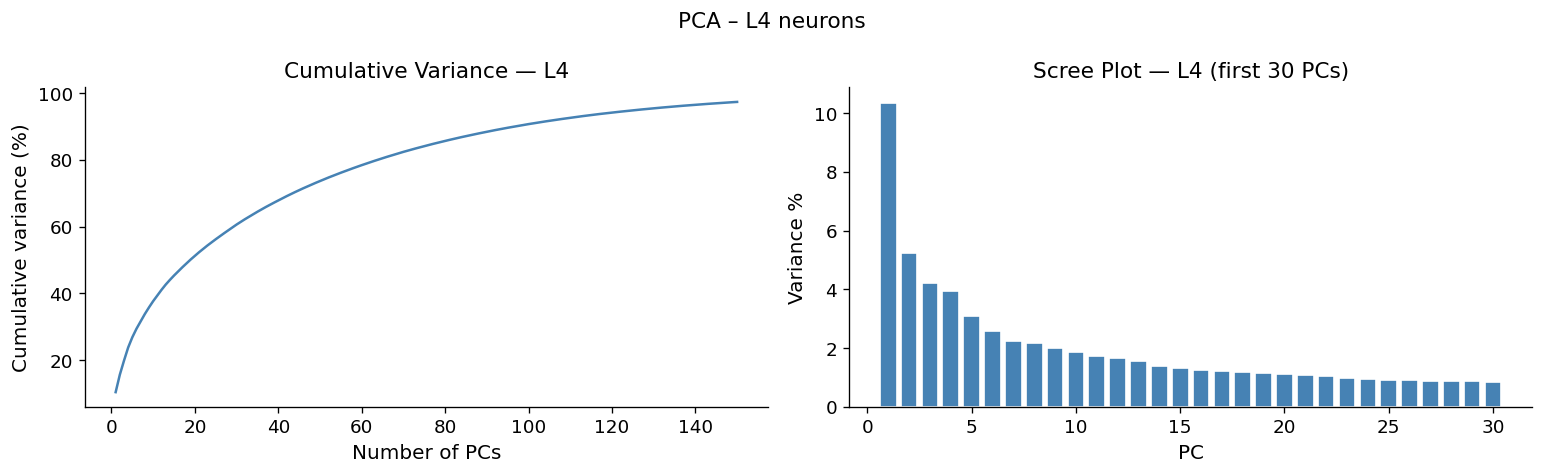

PCs for 80% variance: 64  (all neurons: 82)
PCs for 90% variance: 97  (all neurons: 126)
Variance in PC1+PC2:  15.59%  (all neurons: 14.39%)
Participation ratio:  40.9  (all neurons: 47.2)


In [24]:
n_pcs_l4 = min(150, R_l4_scaled.shape[0]-1, R_l4_scaled.shape[1]-1)
pca_l4   = PCA(n_components=n_pcs_l4, random_state=SEED)
R_l4_pca = pca_l4.fit_transform(R_l4_scaled)

cumvar_l4 = np.cumsum(pca_l4.explained_variance_ratio_)
ev_l4     = pca_l4.explained_variance_ratio_
pr_l4     = 1.0 / np.sum(ev_l4**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(np.arange(1, n_pcs_l4+1), cumvar_l4*100, '-', lw=1.5, color='steelblue')
axes[0].set_xlabel('Number of PCs'); axes[0].set_ylabel('Cumulative variance (%)')
axes[0].set_title('Cumulative Variance — L4')
axes[1].bar(np.arange(1, 31), ev_l4[:30]*100, color='steelblue', edgecolor='white')
axes[1].set_xlabel('PC'); axes[1].set_ylabel('Variance %')
axes[1].set_title('Scree Plot — L4 (first 30 PCs)')
plt.suptitle('PCA – L4 neurons', fontsize=13)
plt.tight_layout()
plt.savefig('fig_l4_pca_variance.png', dpi=150); plt.show()

n80_l4 = min(int(np.searchsorted(cumvar_l4, 0.80))+1, n_pcs_l4)
n90_l4 = min(int(np.searchsorted(cumvar_l4, 0.90))+1, n_pcs_l4)
print(f'PCs for 80% variance: {n80_l4}  (all neurons: {n80})')
print(f'PCs for 90% variance: {n90_l4}  (all neurons: {n90})')
print(f'Variance in PC1+PC2:  {cumvar_l4[1]*100:.2f}%  (all neurons: {cumvar[1]*100:.2f}%)')
print(f'Participation ratio:  {pr_l4:.1f}  (all neurons: {participation_ratio:.1f})')


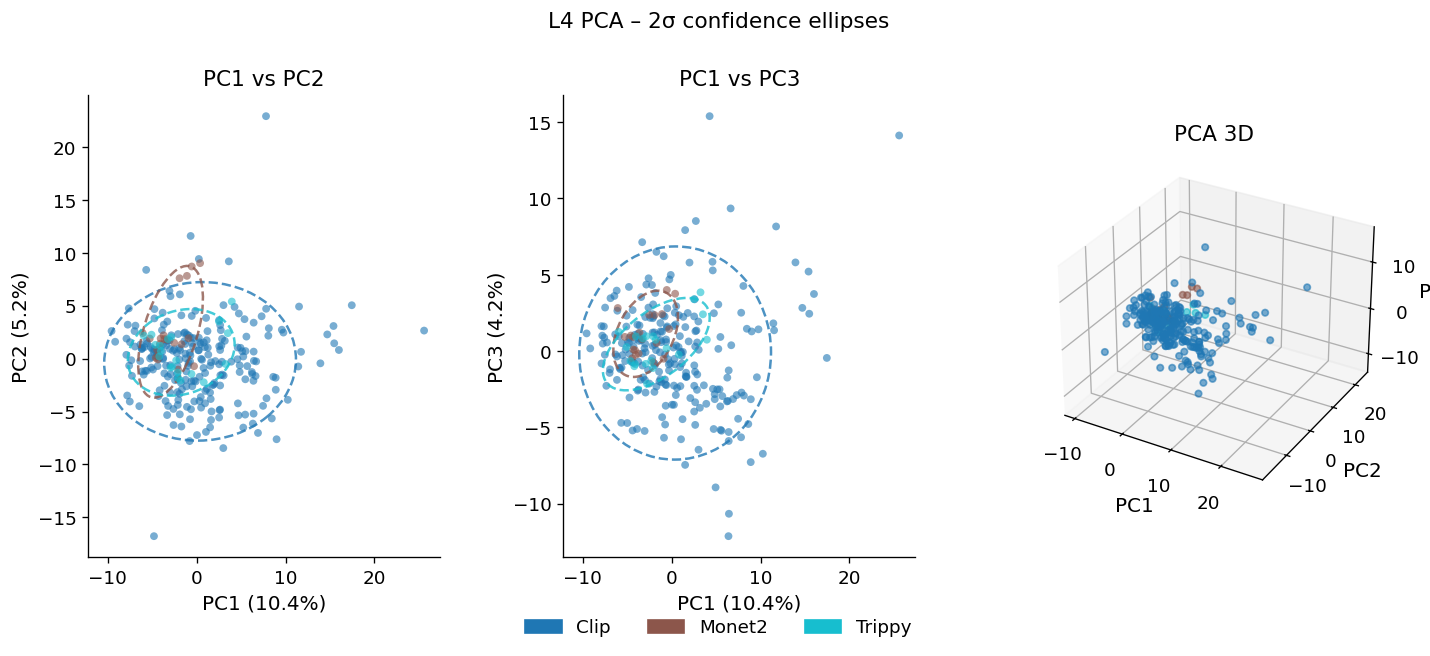

In [25]:
# PCA scatter with confidence ellipses
fig = plt.figure(figsize=(14, 5))
gs2 = GridSpec(1, 3, figure=fig, wspace=0.35)

for col, (xi, yi, title) in enumerate([
        (0, 1, 'PC1 vs PC2'), (0, 2, 'PC1 vs PC3'), (None, None, 'PCA 3D')]):
    if col < 2:
        ax = fig.add_subplot(gs2[col])
        for lbl in unique_labels:
            m = labels_l4 == lbl
            ax.scatter(R_l4_pca[m,xi], R_l4_pca[m,yi], color=label_to_color[lbl],
                       alpha=0.6, s=22, edgecolors='none')
            confidence_ellipse(R_l4_pca[m,xi], R_l4_pca[m,yi], ax, n_std=2,
                               edgecolor=label_to_color[lbl], facecolor='none',
                               lw=1.5, ls='--', alpha=0.8)
        ax.set_xlabel(f'PC{xi+1} ({ev_l4[xi]*100:.1f}%)')
        ax.set_ylabel(f'PC{yi+1} ({ev_l4[yi]*100:.1f}%)')
        ax.set_title(title)
    else:
        ax = fig.add_subplot(gs2[2], projection='3d')
        for lbl in unique_labels:
            m = labels_l4 == lbl
            ax.scatter(R_l4_pca[m,0], R_l4_pca[m,1], R_l4_pca[m,2],
                       color=label_to_color[lbl], alpha=0.6, s=15)
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
        ax.set_title('PCA 3D')

fig.legend(handles=legend_patches, loc='lower center', ncol=n_types,
           bbox_to_anchor=(0.5, -0.05))
plt.suptitle('L4 PCA – 2σ confidence ellipses', fontsize=13, y=1.02)
plt.savefig('fig_l4_pca_scatter.png', dpi=150); plt.show()


##### t-SNE – L4

Running t-SNE on L4 neurons...


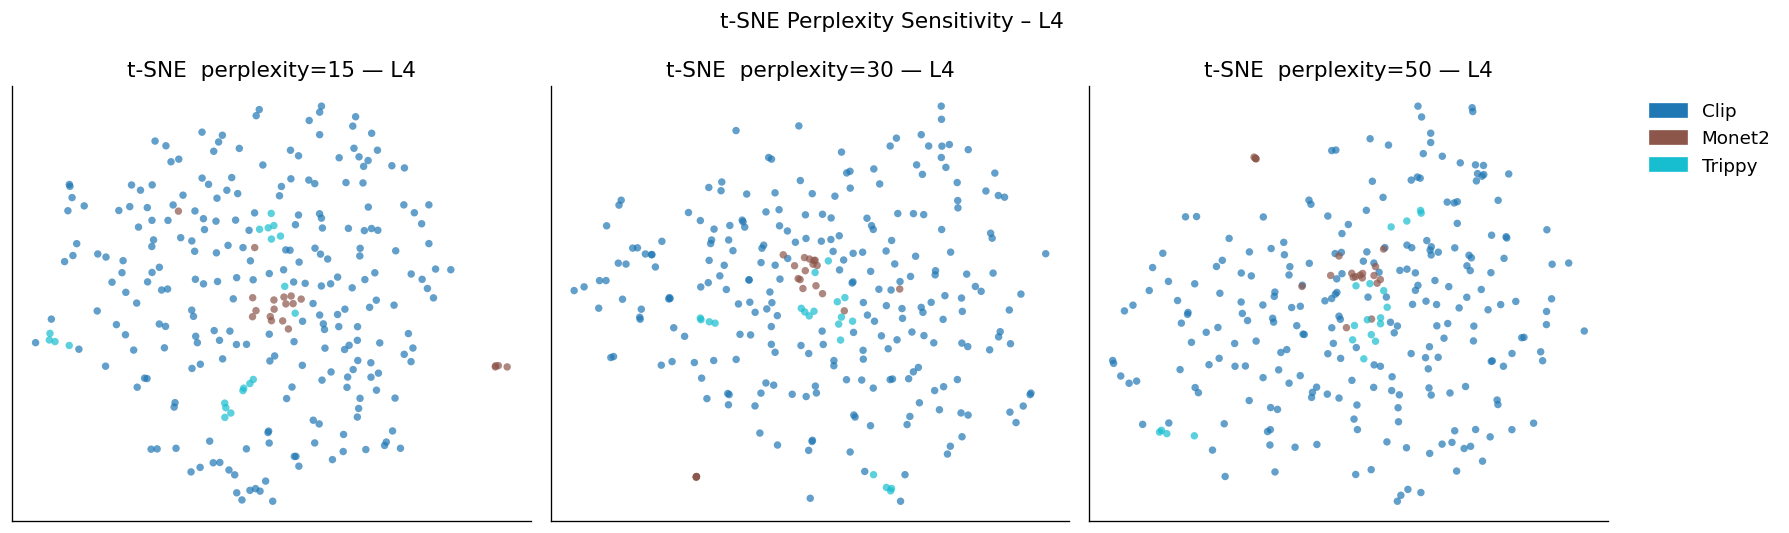

In [26]:
n_pca_for_tsne_l4 = min(50, n_pcs_l4)
tsne_results_l4   = {}
PERPLEXITIES_L4   = [15, 30, 50]

print('Running t-SNE on L4 neurons...')
for perp in PERPLEXITIES_L4:
    tsne_l4 = TSNE(n_components=2, perplexity=perp, random_state=SEED,
                   max_iter=1000, learning_rate='auto', init='pca')
    tsne_results_l4[perp] = tsne_l4.fit_transform(R_l4_pca[:, :n_pca_for_tsne_l4])

R_l4_tsne = tsne_results_l4[30]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, perp in zip(axes, PERPLEXITIES_L4):
    for lbl in unique_labels:
        m = labels_l4 == lbl
        ax.scatter(tsne_results_l4[perp][m,0], tsne_results_l4[perp][m,1],
                   color=label_to_color[lbl], alpha=0.7, s=20, edgecolors='none')
    ax.set_title(f't-SNE  perplexity={perp} — L4')
    ax.set_xticks([]); ax.set_yticks([])
axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left')
plt.suptitle('t-SNE Perplexity Sensitivity – L4', fontsize=13)
plt.tight_layout()
plt.savefig('fig_l4_tsne_perplexity.png', dpi=150); plt.show()


##### UMAP – L4

Running UMAP on L4 neurons...


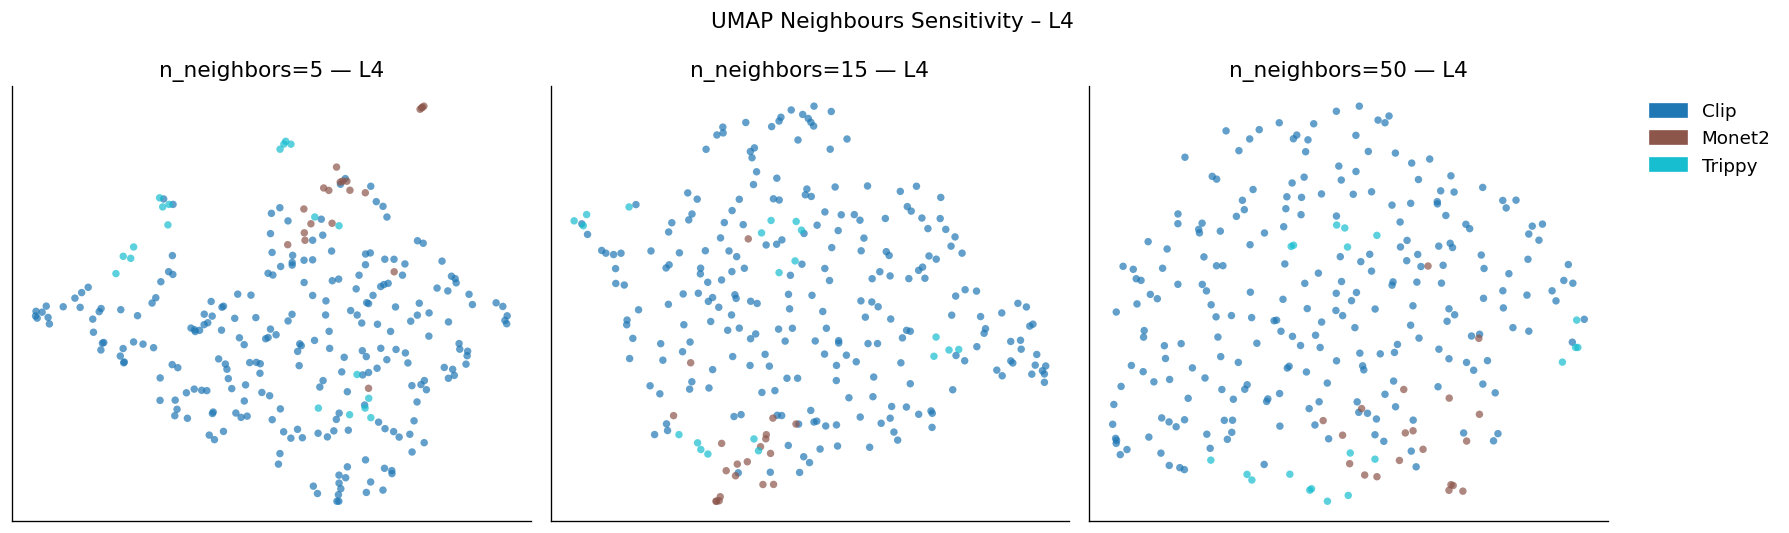

In [27]:
R_l4_umap = None
if UMAP_AVAILABLE:
    umap_results_l4  = {}
    N_NEIGHBORS_L4   = [5, 15, 50]
    print('Running UMAP on L4 neurons...')
    for nn in N_NEIGHBORS_L4:
        reducer_l4 = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=0.1,
                               metric='euclidean', random_state=SEED)
        umap_results_l4[nn] = reducer_l4.fit_transform(R_l4_pca[:, :n_pca_for_tsne_l4])
    R_l4_umap = umap_results_l4[15]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, nn in zip(axes, N_NEIGHBORS_L4):
        for lbl in unique_labels:
            m = labels_l4 == lbl
            ax.scatter(umap_results_l4[nn][m,0], umap_results_l4[nn][m,1],
                       color=label_to_color[lbl], alpha=0.7, s=20, edgecolors='none')
        ax.set_title(f'n_neighbors={nn} — L4')
        ax.set_xticks([]); ax.set_yticks([])
    axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left')
    plt.suptitle('UMAP Neighbours Sensitivity – L4', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig_l4_umap_neighbors.png', dpi=150); plt.show()


##### CEBRA – L4 (Visualization)

  0%|          | 0/2000 [00:00<?, ?it/s]

pos: -0.1014 neg:  5.1499 total:  5.0485 temperature:  1.0000:   0%|          | 0/2000 [00:00<?, ?it/s]

pos: -0.2634 neg:  5.1528 total:  4.8894 temperature:  1.0000:   0%|          | 0/2000 [00:00<?, ?it/s]

pos: -0.3584 neg:  5.1676 total:  4.8092 temperature:  1.0000:   0%|          | 0/2000 [00:00<?, ?it/s]

pos: -0.4741 neg:  5.2223 total:  4.7481 temperature:  1.0000:   0%|          | 0/2000 [00:00<?, ?it/s]

...

pos: -0.5447 neg:  5.2694 total:  4.7247 temperature:  1.0000: 100%|█████████▉| 1996/2000 [00:24<00:00, 82.79it/s]

pos: -0.5280 neg:  5.2611 total:  4.7331 temperature:  1.0000: 100%|█████████▉| 1996/2000 [00:24<00:00, 82.79it/s]

pos: -0.5377 neg:  5.2677 total:  4.7300 temperature:  1.0000: 100%|█████████▉| 1996/2000 [00:24<00:00, 82.79it/s]

pos: -0.5365 neg:  5.2601 total:  4.7236 temperature:  1.0000: 100%|█████████▉| 1996/2000 [00:24<00:00, 82.79it/s]

pos: -0.5365 neg:  5.2601 total:  4.7236 temperature:  1.0000: 100%|██████████| 2000/2000 [00:24<00:00, 82.30it/s]

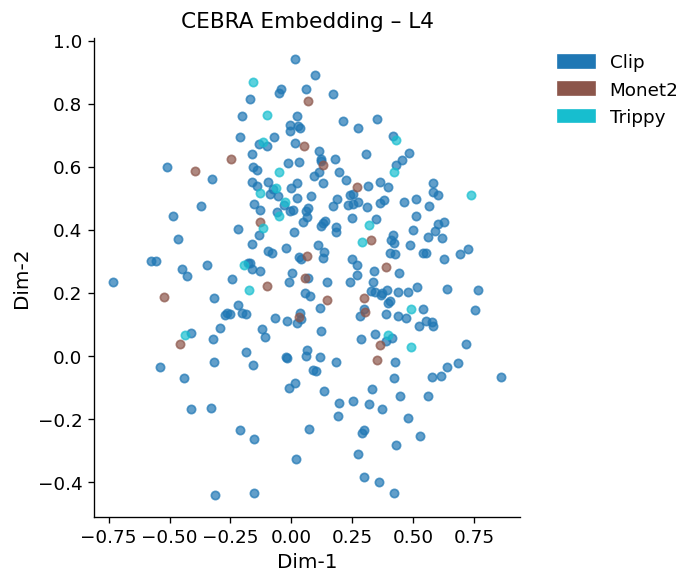

In [28]:
R_l4_cebra = None
if CEBRA_AVAILABLE:
    try:
        import torch
        label_cont_l4 = y_l4.astype(np.float32).reshape(-1, 1)
        cb_model_l4 = cebra.CEBRA(
            model_architecture='offset10-model',
            batch_size=min(512, len(R_l4_scaled)//2),
            learning_rate=3e-4,
            temperature=1.0,
            output_dimension=8,
            max_iterations=2000,
            device='cpu',
            verbose=True,
        )
        cb_model_l4.fit(R_l4_scaled.astype(np.float32), label_cont_l4)
        R_l4_cebra = cb_model_l4.transform(R_l4_scaled.astype(np.float32))

        fig, ax = plt.subplots(figsize=(6,5))
        for lbl in unique_labels:
            m = labels_l4 == lbl
            ax.scatter(R_l4_cebra[m,0], R_l4_cebra[m,1], color=label_to_color[lbl],
                       alpha=0.7, s=25, label=lbl)
        ax.set_title('CEBRA Embedding – L4')
        ax.set_xlabel('Dim-1'); ax.set_ylabel('Dim-2')
        ax.legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left')
        plt.tight_layout()
        plt.savefig('fig_l4_cebra.png', dpi=150); plt.show()
    except Exception as e:
        print(f'CEBRA failed: {e}')
        R_l4_cebra = None
else:
    print('CEBRA not installed')


##### DR Comparison – L4

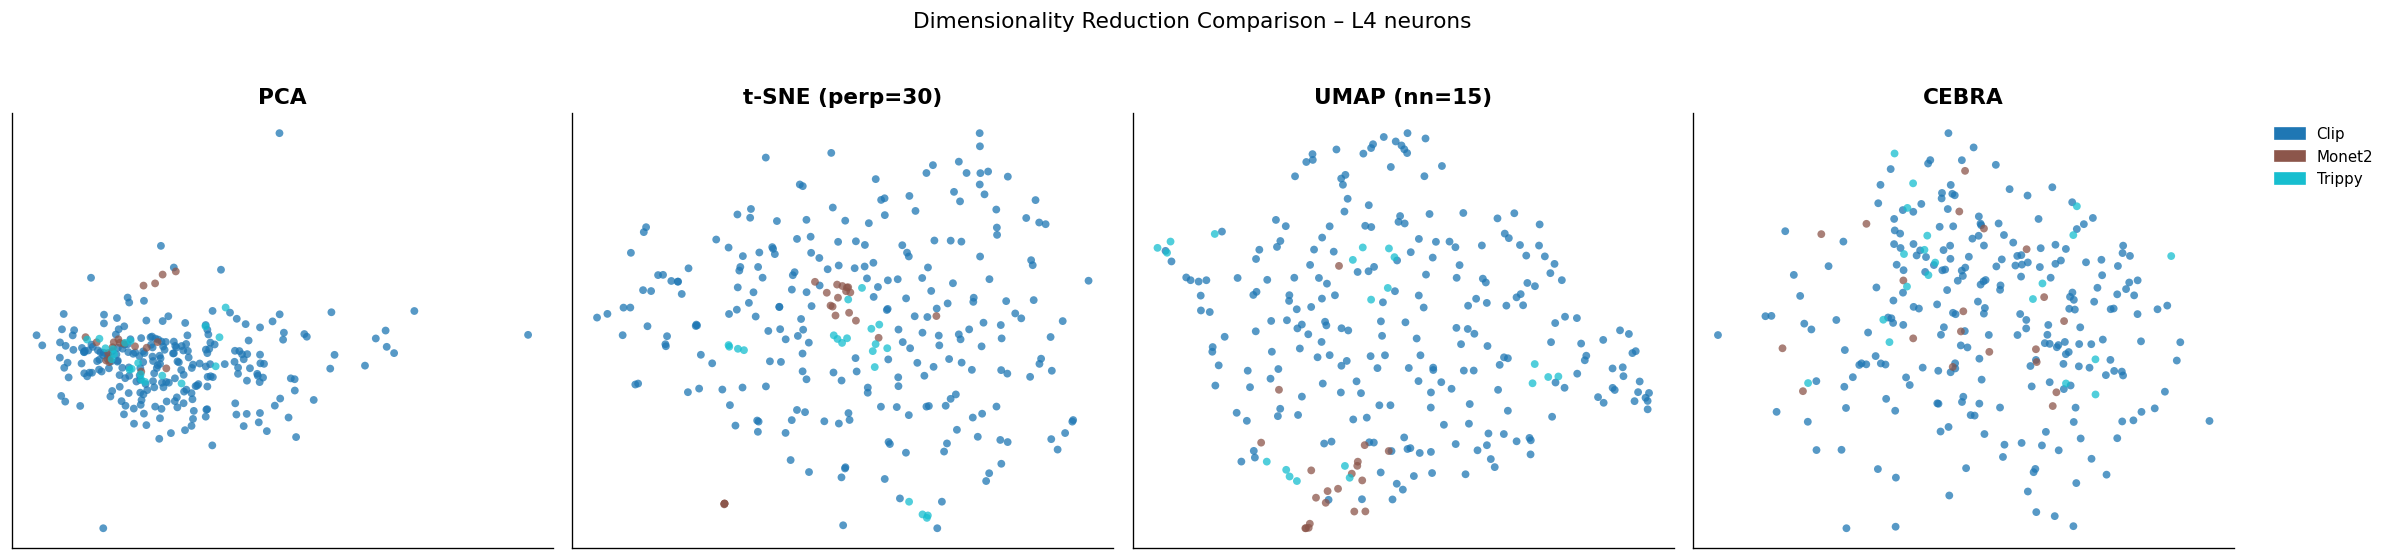

In [29]:
methods_l4 = [('PCA', R_l4_pca[:, :2]), ('t-SNE (perp=30)', R_l4_tsne)]
if UMAP_AVAILABLE  and R_l4_umap  is not None: methods_l4.append(('UMAP (nn=15)',  R_l4_umap))
if CEBRA_AVAILABLE and R_l4_cebra is not None: methods_l4.append(('CEBRA', R_l4_cebra[:, :2]))

fig, axes = plt.subplots(1, len(methods_l4), figsize=(5*len(methods_l4), 4.5))
if len(methods_l4) == 1: axes = [axes]
for ax, (name, emb) in zip(axes, methods_l4):
    for lbl in unique_labels:
        m = labels_l4 == lbl
        ax.scatter(emb[m,0], emb[m,1], color=label_to_color[lbl],
                   alpha=0.75, s=22, edgecolors='none')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left', fontsize=9)
plt.suptitle('Dimensionality Reduction Comparison – L4 neurons', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig('fig_l4_dr_comparison.png', dpi=150); plt.show()


##### Quantitative Evaluation – L4

In [30]:
counts_l4        = {lbl: int(np.sum(labels_l4 == lbl)) for lbl in unique_labels}
majority_frac_l4 = max(counts_l4.values()) / len(labels_l4)

rng_bal_l4 = np.random.default_rng(seed=SEED)
N_BAL_l4   = int(min(counts_l4.values()))
bal_idx_l4 = np.sort(np.concatenate([
    rng_bal_l4.choice(np.where(labels_l4 == lbl)[0], size=N_BAL_l4, replace=False)
    for lbl in unique_labels
]))
y_bal_l4 = y_l4[bal_idx_l4]

cv_bal_l4  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
clf_bal_l4 = LogisticRegression(max_iter=2000, C=1.0, random_state=SEED, class_weight='balanced')

sil_scores_l4     = {}
clf_scores_l4     = {}
clf_scores_bal_l4 = {}
clf_scores_f1_l4  = {}

for name, emb in methods_l4:
    sil_scores_l4[name]     = silhouette_score(emb, y_l4)
    clf_scores_l4[name]     = cross_val_score(clf_bal_l4, emb, y_l4, cv=cv_bal_l4,
                                              scoring='accuracy').mean()
    clf_scores_bal_l4[name] = cross_val_score(clf_bal_l4, emb, y_l4, cv=cv_bal_l4,
                                              scoring='balanced_accuracy').mean()
    clf_scores_f1_l4[name]  = cross_val_score(clf_bal_l4, emb, y_l4, cv=cv_bal_l4,
                                              scoring='f1_macro').mean()

for k in [2, 5, 10, 20, 50]:
    if k < R_l4_pca.shape[1]:
        sil_scores_l4[f'PCA-{k}D'] = silhouette_score(R_l4_pca[:, :k], y_l4)

print('Silhouette — L4 only')
for name, sc in sorted(sil_scores_l4.items(), key=lambda x: -x[1]):
    prev = sil_scores.get(name, float('nan'))
    print(f'{name:25s}  L4={sc:+.4f}  all={prev:+.4f}')

print('\nBalanced Accuracy — L4 only')
for name, bacc in sorted(clf_scores_bal_l4.items(), key=lambda x: -x[1]):
    prev = clf_scores_bal.get(name, float('nan'))
    f1   = clf_scores_f1_l4.get(name, float('nan'))
    print(f'{name:25s}  L4 bal_acc={bacc:.4f}  all={prev:.4f}  L4 F1={f1:.4f}')


Silhouette — L4 only
UMAP (nn=15)               L4=-0.0025  all=+0.1247
CEBRA                      L4=-0.0831  all=-0.0935
PCA-10D                    L4=-0.1404  all=-0.1137
PCA-20D                    L4=-0.1416  all=-0.1192
t-SNE (perp=30)            L4=-0.1440  all=-0.1088
PCA-50D                    L4=-0.1466  all=-0.1313
PCA-5D                     L4=-0.1676  all=-0.1285
PCA                        L4=-0.1906  all=-0.1269
PCA-2D                     L4=-0.1906  all=-0.1269

Balanced Accuracy — L4 only
UMAP (nn=15)               L4 bal_acc=0.5583  all=0.5153  L4 F1=0.4291
PCA                        L4 bal_acc=0.5194  all=0.4653  L4 F1=0.3793
CEBRA                      L4 bal_acc=0.4000  all=0.2736  L4 F1=0.2805
t-SNE (perp=30)            L4 bal_acc=0.2764  all=0.4014  L4 F1=0.2422


Classification Report per method (L4 only)

PCA
              precision    recall  f1-score   support

        Clip       0.95      0.56      0.70       240
      Monet2       0.17      0.70      0.28        20
      Trippy       0.10      0.30      0.15        20

    accuracy                           0.55       280
   macro avg       0.41      0.52      0.38       280
weighted avg       0.83      0.55      0.63       280

t-SNE (perp=30)
              precision    recall  f1-score   support

        Clip       0.83      0.43      0.57       240
      Monet2       0.02      0.10      0.04        20
      Trippy       0.08      0.30      0.13        20

    accuracy                           0.40       280
   macro avg       0.31      0.28      0.24       280
weighted avg       0.72      0.40      0.50       280

UMAP (nn=15)
              precision    recall  f1-score   support

        Clip       0.93      0.57      0.71       240
      Monet2       0.34      0.90      0.49        2

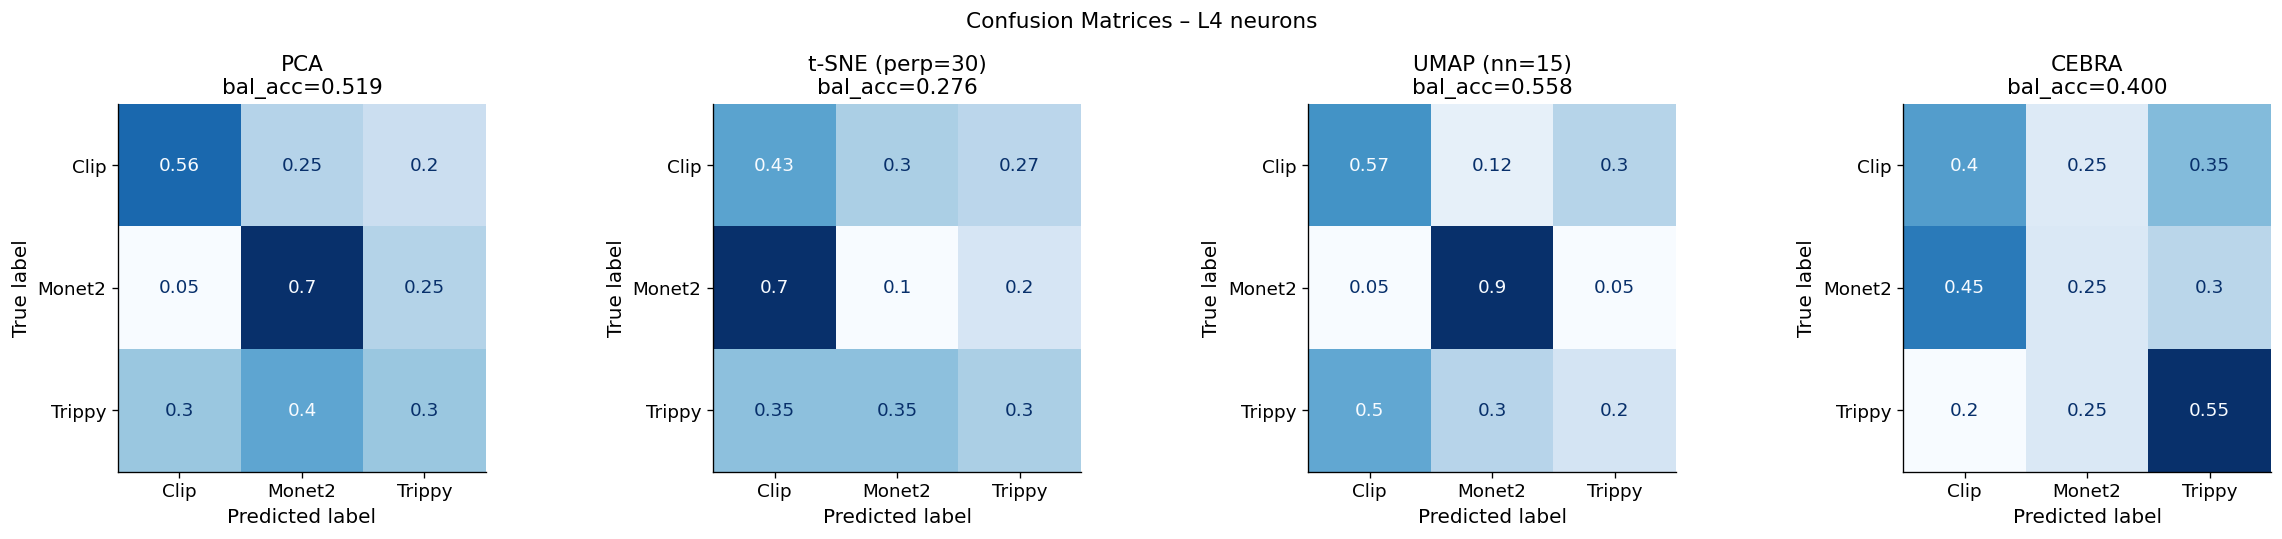

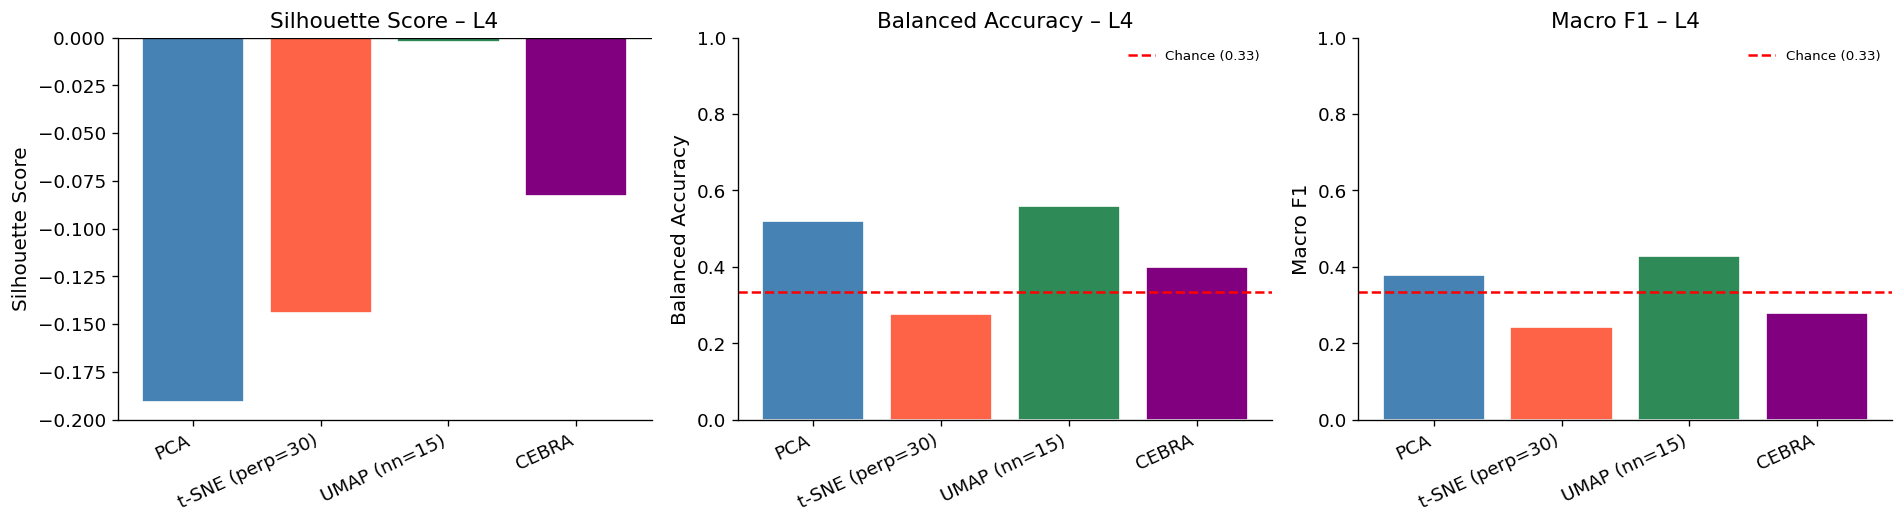

In [31]:
from sklearn.metrics import classification_report as _cr
print('Classification Report per method (L4 only)\n')
for name, emb in methods_l4:
    y_pred_l4 = cross_val_predict(clf_bal_l4, emb, y_l4, cv=cv_bal_l4)
    print(f'{name}')
    print(_cr(y_l4, y_pred_l4, target_names=le.classes_))

fig, axes = plt.subplots(1, len(methods_l4), figsize=(5*len(methods_l4), 4.5))
if len(methods_l4) == 1: axes = [axes]
for ax, (name, emb) in zip(axes, methods_l4):
    y_pred_l4 = cross_val_predict(clf_bal_l4, emb, y_l4, cv=cv_bal_l4)
    cm_l4 = confusion_matrix(y_l4, y_pred_l4, normalize='true')
    ConfusionMatrixDisplay(cm_l4, display_labels=le.classes_).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nbal_acc={clf_scores_bal_l4.get(name, float("nan")):.3f}')
plt.suptitle('Confusion Matrices – L4 neurons', fontsize=13)
plt.tight_layout()
plt.savefig('fig_l4_confusion_matrices.png', dpi=150); plt.show()

plot_names_l4 = [m[0] for m in methods_l4]
colors_m_l4   = ['steelblue', 'tomato', 'seagreen', 'purple'][:len(plot_names_l4)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sil_vals_l4 = [sil_scores_l4.get(n, float('nan')) for n in plot_names_l4]
axes[0].bar(plot_names_l4, sil_vals_l4, color=colors_m_l4, edgecolor='white')
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_title('Silhouette Score – L4'); axes[0].set_ylabel('Silhouette Score')
axes[0].set_xticklabels(plot_names_l4, rotation=25, ha='right')

bal_vals_l4 = [clf_scores_bal_l4.get(n, float('nan')) for n in plot_names_l4]
axes[1].bar(plot_names_l4, bal_vals_l4, color=colors_m_l4, edgecolor='white')
axes[1].axhline(chance_level, color='red', ls='--', label=f'Chance ({chance_level:.2f})')
axes[1].set_title('Balanced Accuracy – L4'); axes[1].set_ylabel('Balanced Accuracy')
axes[1].set_xticklabels(plot_names_l4, rotation=25, ha='right')
axes[1].set_ylim(0, 1); axes[1].legend(fontsize=8)

f1_vals_l4 = [clf_scores_f1_l4.get(n, float('nan')) for n in plot_names_l4]
axes[2].bar(plot_names_l4, f1_vals_l4, color=colors_m_l4, edgecolor='white')
axes[2].axhline(chance_level, color='red', ls='--', label=f'Chance ({chance_level:.2f})')
axes[2].set_title('Macro F1 – L4'); axes[2].set_ylabel('Macro F1')
axes[2].set_xticklabels(plot_names_l4, rotation=25, ha='right')
axes[2].set_ylim(0, 1); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_l4_quantitative.png', dpi=150); plt.show()


##### Shuffle Control – L4

In [32]:
N_SHUFFLES_L4 = 100
rng_shuf_l4   = np.random.default_rng(seed=SEED)

null_sil_l4 = {name: [] for name, _ in methods_l4}
null_bal_l4 = {name: [] for name, _ in methods_l4}
null_f1_l4  = {name: [] for name, _ in methods_l4}

print('Running shuffle control for L4...')
for i in range(N_SHUFFLES_L4):
    y_s = rng_shuf_l4.permutation(y_l4)
    for name, emb in methods_l4:
        null_sil_l4[name].append(silhouette_score(emb, y_s))
        null_bal_l4[name].append(cross_val_score(clf_bal_l4, emb, y_s, cv=cv_bal_l4,
                                                 scoring='balanced_accuracy').mean())
        null_f1_l4[name].append(cross_val_score(clf_bal_l4, emb, y_s, cv=cv_bal_l4,
                                                scoring='f1_macro').mean())

null_sil_l4 = {k: np.array(v) for k, v in null_sil_l4.items()}
null_bal_l4 = {k: np.array(v) for k, v in null_bal_l4.items()}
null_f1_l4  = {k: np.array(v) for k, v in null_f1_l4.items()}

print('\nShuffle control results — L4:')
print(f"{'Method':<22} {'Metric':<18} {'Real':>7} {'Null µ':>8} {'Null σ':>8} {'p':>8}")
for name, emb in methods_l4:
    for metric, null_arr, real_val in [
            ('Silhouette',   null_sil_l4[name], sil_scores_l4.get(name, float('nan'))),
            ('Balanced acc', null_bal_l4[name], clf_scores_bal_l4.get(name, float('nan'))),
            ('Macro F1',     null_f1_l4[name],  clf_scores_f1_l4.get(name, float('nan')))]:
        _, p = ttest_1samp(null_arr, real_val, alternative='less')
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'  {name:<20} {metric:<18} {real_val:>7.4f} '
              f'{null_arr.mean():>8.4f} {null_arr.std():>8.4f} {p:>7.4f} {sig}')
    print()


Running shuffle control for L4...



Shuffle control results — L4:
Method                 Metric                Real   Null µ   Null σ        p
  PCA                  Silhouette         -0.1906  -0.0641   0.0596  1.0000 ns
  PCA                  Balanced acc        0.5194   0.3332   0.0522  0.0000 ***
  PCA                  Macro F1            0.3793   0.2286   0.0463  0.0000 ***

  t-SNE (perp=30)      Silhouette         -0.1440  -0.0556   0.0357  1.0000 ns
  t-SNE (perp=30)      Balanced acc        0.2764   0.3326   0.0615  1.0000 ns
  t-SNE (perp=30)      Macro F1            0.2422   0.2253   0.0409  0.0000 ***

  UMAP (nn=15)         Silhouette         -0.0025  -0.0562   0.0315  0.0000 ***
  UMAP (nn=15)         Balanced acc        0.5583   0.3303   0.0579  0.0000 ***
  UMAP (nn=15)         Macro F1            0.4291   0.2144   0.0400  0.0000 ***

  CEBRA                Silhouette         -0.0831  -0.0612   0.0338  1.0000 ns
  CEBRA                Balanced acc        0.4000   0.3266   0.0663  0.0000 ***
  CEBRA      

##### All Neurons vs L4 Head-to-Head

Head-to-head comparison: All neurons vs L4 only
Method                 Metric                 All      L4    Delta
  PCA                  Silhouette         -0.1269 -0.1906 -0.0636 ▼
  PCA                  Balanced acc        0.4653  0.5194 +0.0542 ▲
  PCA                  Macro F1            0.3641  0.3793 +0.0152 ▲

  t-SNE (perp=30)      Silhouette         -0.1088 -0.1440 -0.0352 ▼
  t-SNE (perp=30)      Balanced acc        0.4014  0.2764 -0.1250 ▼
  t-SNE (perp=30)      Macro F1            0.3394  0.2422 -0.0972 ▼

  UMAP (nn=15)         Silhouette          0.1247 -0.0025 -0.1273 ▼
  UMAP (nn=15)         Balanced acc        0.5153  0.5583 +0.0431 ▲
  UMAP (nn=15)         Macro F1            0.4707  0.4291 -0.0416 ▼

  CEBRA                Silhouette         -0.0935 -0.0831 +0.0104 ▲
  CEBRA                Balanced acc        0.2736  0.4000 +0.1264 ▲
  CEBRA                Macro F1            0.1853  0.2805 +0.0952 ▲



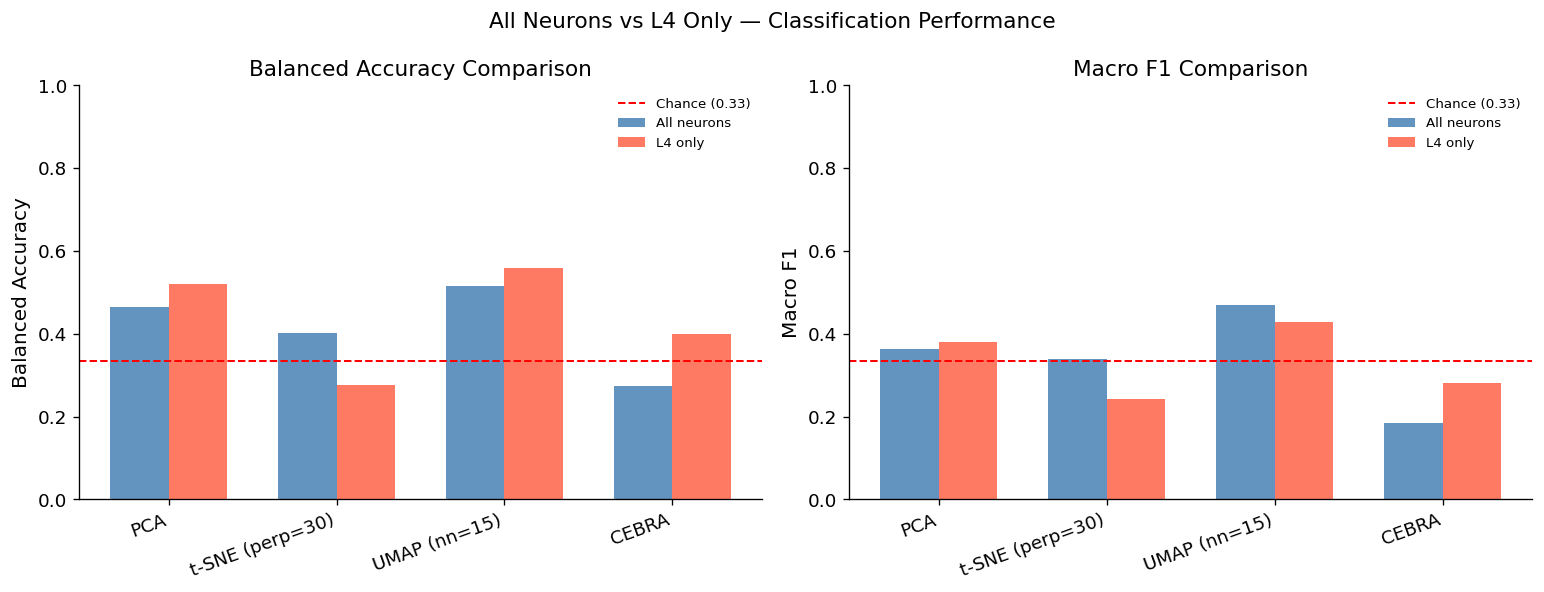

In [33]:
common_methods = [name for name, _ in methods if name in {n for n, _ in methods_l4}]

print('Head-to-head comparison: All neurons vs L4 only')
print(f"{'Method':<22} {'Metric':<18} {'All':>7} {'L4':>7} {'Delta':>8}")
for name in common_methods:
    for metric, all_d, l4_d in [
            ('Silhouette',   sil_scores,     sil_scores_l4),
            ('Balanced acc', clf_scores_bal, clf_scores_bal_l4),
            ('Macro F1',     clf_scores_f1,  clf_scores_f1_l4)]:
        a = all_d.get(name, float('nan'))
        b = l4_d.get(name,  float('nan'))
        delta = b - a
        arrow = chr(9650) if delta > 0 else chr(9660)   # ▲ / ▼
        print(f'  {name:<20} {metric:<18} {a:>7.4f} {b:>7.4f} {delta:>+7.4f} {arrow}')
    print()

# Side-by-side bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x     = np.arange(len(common_methods))
width = 0.35

all_bac = [clf_scores_bal.get(n, float('nan')) for n in common_methods]
l4_bac  = [clf_scores_bal_l4.get(n, float('nan')) for n in common_methods]
axes[0].bar(x - width/2, all_bac, width, label='All neurons', color='steelblue', alpha=0.85)
axes[0].bar(x + width/2, l4_bac,  width, label='L4 only',    color='tomato',    alpha=0.85)
axes[0].axhline(chance_level, color='red', ls='--', lw=1.2, label=f'Chance ({chance_level:.2f})')
axes[0].set_xticks(x); axes[0].set_xticklabels(common_methods, rotation=20, ha='right')
axes[0].set_ylabel('Balanced Accuracy'); axes[0].set_title('Balanced Accuracy Comparison')
axes[0].set_ylim(0, 1); axes[0].legend(fontsize=8)

all_f1 = [clf_scores_f1.get(n, float('nan')) for n in common_methods]
l4_f1  = [clf_scores_f1_l4.get(n, float('nan')) for n in common_methods]
axes[1].bar(x - width/2, all_f1, width, label='All neurons', color='steelblue', alpha=0.85)
axes[1].bar(x + width/2, l4_f1,  width, label='L4 only',    color='tomato',    alpha=0.85)
axes[1].axhline(chance_level, color='red', ls='--', lw=1.2, label=f'Chance ({chance_level:.2f})')
axes[1].set_xticks(x); axes[1].set_xticklabels(common_methods, rotation=20, ha='right')
axes[1].set_ylabel('Macro F1'); axes[1].set_title('Macro F1 Comparison')
axes[1].set_ylim(0, 1); axes[1].legend(fontsize=8)

plt.suptitle('All Neurons vs L4 Only — Classification Performance', fontsize=13)
plt.tight_layout()
plt.savefig('fig_l4_vs_all_comparison.png', dpi=150); plt.show()


In [34]:
summary_l4_rows = []
for name, emb in methods_l4:
    summary_l4_rows.append({
        'Method': name,
        'Silhouette': f"{sil_scores_l4.get(name, float('nan')):.4f}",
        'Std Accuracy': f"{clf_scores_l4.get(name, float('nan')):.4f}",
        'Balanced Accuracy': f"{clf_scores_bal_l4.get(name, float('nan')):.4f}",
        'Macro F1': f"{clf_scores_f1_l4.get(name, float('nan')):.4f}",
    })

print('L4 Results Summary')
print(pd.DataFrame(summary_l4_rows).to_string(index=False))
print(f'\nBaselines:')
print(f'Always predict Clip (majority): {majority_frac_l4:.4f}')
print(f'Uniform chance (balanced acc):  {chance_level:.4f}')
print(f'\nIntrinsic dimensionality — L4:')
print(f'PCs for 80% variance: {n80_l4}  (all neurons: {n80})')
print(f'PCs for 90% variance: {n90_l4}  (all neurons: {n90})')
print(f'Variance in PC1+PC2:  {cumvar_l4[1]*100:.2f}%  (all neurons: {cumvar[1]*100:.2f}%)')
print(f'Participation ratio:  {pr_l4:.1f}  (all neurons: {participation_ratio:.1f})')
print(f'\nL4 neurons used: {l4_mask_clean.sum()} of {trusted_meta_clean.shape[0]} total')


L4 Results Summary
         Method Silhouette Std Accuracy Balanced Accuracy Macro F1
            PCA    -0.1906       0.5500            0.5194   0.3793
t-SNE (perp=30)    -0.1440       0.3964            0.2764   0.2422
   UMAP (nn=15)    -0.0025       0.5714            0.5583   0.4291
          CEBRA    -0.0831       0.4000            0.4000   0.2805

Baselines:
Always predict Clip (majority): 0.8571
Uniform chance (balanced acc):  0.3333

Intrinsic dimensionality — L4:
PCs for 80% variance: 64  (all neurons: 82)
PCs for 90% variance: 97  (all neurons: 126)
Variance in PC1+PC2:  15.59%  (all neurons: 14.39%)
Participation ratio:  40.9  (all neurons: 47.2)

L4 neurons used: 257 of 579 total


#### L2/3 Neurons

In [35]:
# ── L2/3 subset ───────────────────────────────────────────────────────
l23_mask_clean = (trusted_meta_clean['layer'] == 'L2/3').values
R_l23_raw      = R_clean[:, l23_mask_clean]
trusted_meta_l23 = trusted_meta_clean[l23_mask_clean].reset_index(drop=True)

print(f'L2/3 neurons: {l23_mask_clean.sum()} / {trusted_meta_clean.shape[0]}')
print(f'L2/3 response matrix: {R_l23_raw.shape}')
print(f'Layer check: {trusted_meta_l23["layer"].value_counts().to_dict()}')

scaler_l23   = StandardScaler()
R_l23_scaled = scaler_l23.fit_transform(R_l23_raw)

active_l23   = R_l23_scaled.std(axis=1) > 1e-6
R_l23_scaled = R_l23_scaled[active_l23]
labels_l23   = labels[active_l23]
y_l23        = le.transform(labels_l23)

print(f'Stimuli after activity filter: {active_l23.sum()} / {R_l23_raw.shape[0]}')
print(f'Stimulus distribution: {dict(zip(*np.unique(labels_l23, return_counts=True)))}')


L2/3 neurons: 220 / 579
L2/3 response matrix: (280, 220)
Layer check: {'L2/3': 220}
Stimuli after activity filter: 280 / 280
Stimulus distribution: {np.str_('Clip'): np.int64(240), np.str_('Monet2'): np.int64(20), np.str_('Trippy'): np.int64(20)}


##### PCA – L2/3

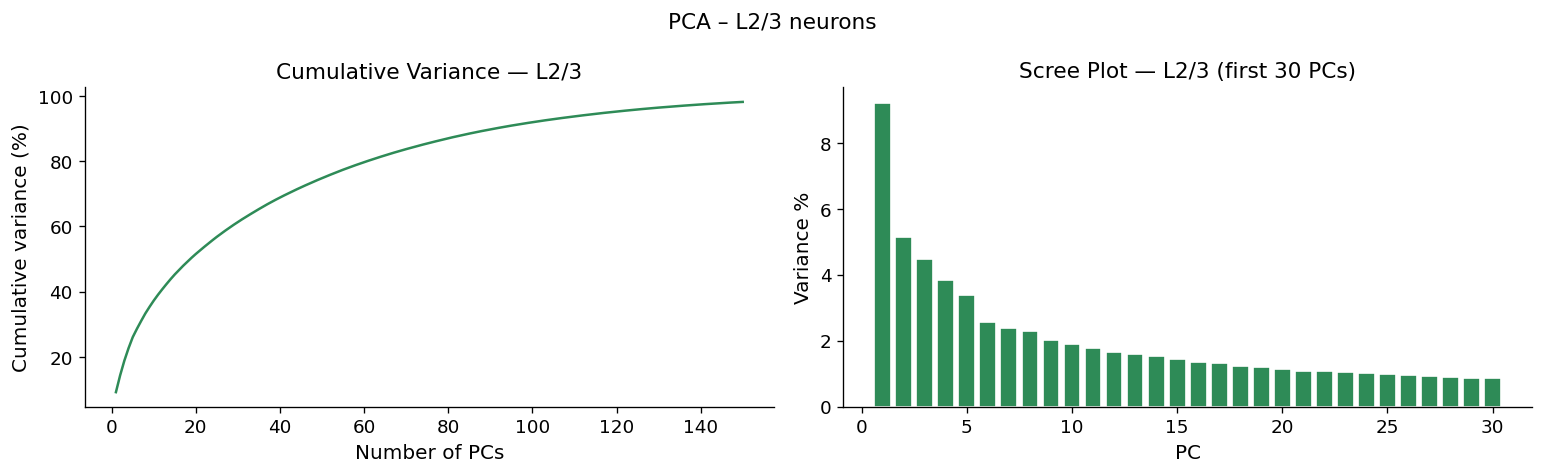

PCs for 80% variance: 61  (L4: 64, all: 82)
PCs for 90% variance: 92  (L4: 97, all: 126)
Variance in PC1+PC2:  14.37%  (L4: 15.59%, all: 14.39%)
Participation ratio:  43.4  (L4: 40.9, all: 47.2)


In [36]:
n_pcs_l23 = min(150, R_l23_scaled.shape[0]-1, R_l23_scaled.shape[1]-1)
pca_l23   = PCA(n_components=n_pcs_l23, random_state=SEED)
R_l23_pca = pca_l23.fit_transform(R_l23_scaled)

cumvar_l23 = np.cumsum(pca_l23.explained_variance_ratio_)
ev_l23     = pca_l23.explained_variance_ratio_
pr_l23     = 1.0 / np.sum(ev_l23**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(np.arange(1, n_pcs_l23+1), cumvar_l23*100, '-', lw=1.5, color='seagreen')
axes[0].set_xlabel('Number of PCs'); axes[0].set_ylabel('Cumulative variance (%)')
axes[0].set_title('Cumulative Variance — L2/3')
axes[1].bar(np.arange(1, 31), ev_l23[:30]*100, color='seagreen', edgecolor='white')
axes[1].set_xlabel('PC'); axes[1].set_ylabel('Variance %')
axes[1].set_title('Scree Plot — L2/3 (first 30 PCs)')
plt.suptitle('PCA – L2/3 neurons', fontsize=13)
plt.tight_layout()
plt.savefig('fig_l23_pca_variance.png', dpi=150); plt.show()

n80_l23 = min(int(np.searchsorted(cumvar_l23, 0.80))+1, n_pcs_l23)
n90_l23 = min(int(np.searchsorted(cumvar_l23, 0.90))+1, n_pcs_l23)
print(f'PCs for 80% variance: {n80_l23}  (L4: {n80_l4}, all: {n80})')
print(f'PCs for 90% variance: {n90_l23}  (L4: {n90_l4}, all: {n90})')
print(f'Variance in PC1+PC2:  {cumvar_l23[1]*100:.2f}%  (L4: {cumvar_l4[1]*100:.2f}%, all: {cumvar[1]*100:.2f}%)')
print(f'Participation ratio:  {pr_l23:.1f}  (L4: {pr_l4:.1f}, all: {participation_ratio:.1f})')


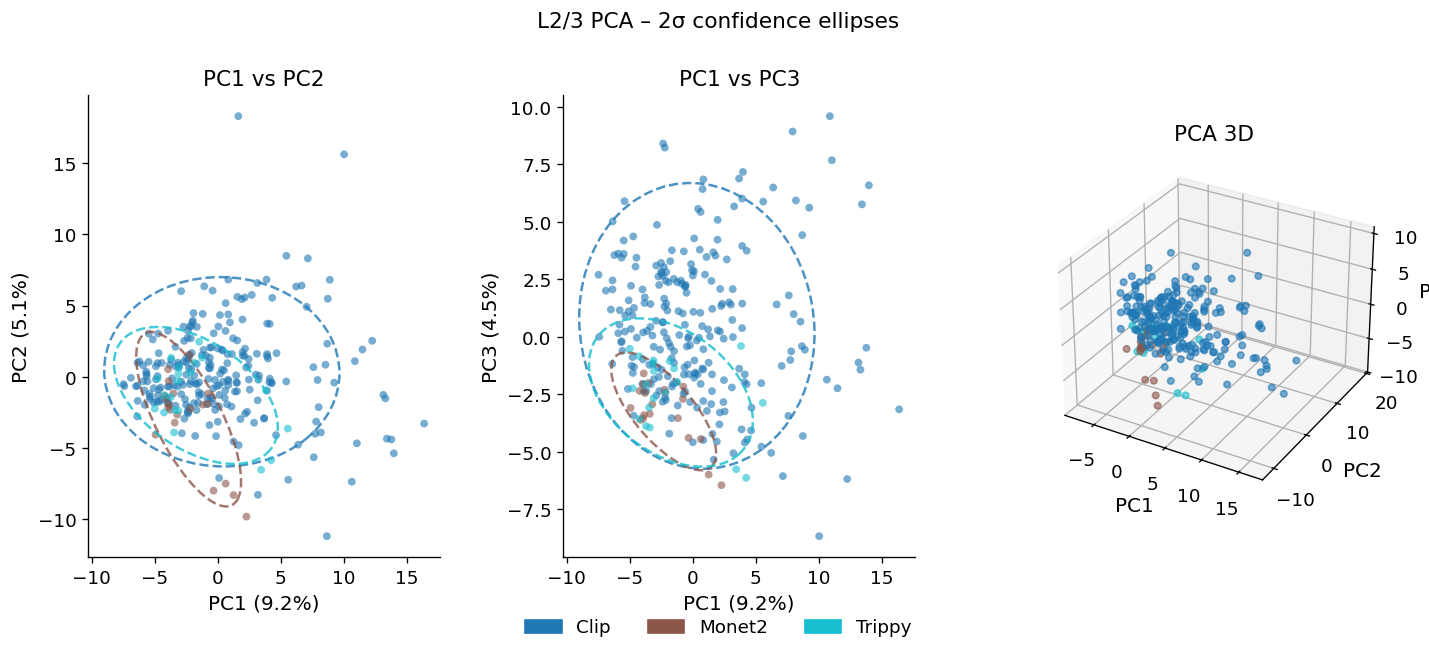

In [37]:
# PCA scatter with confidence ellipses
fig = plt.figure(figsize=(14, 5))
gs3 = GridSpec(1, 3, figure=fig, wspace=0.35)

for col, (xi, yi, title) in enumerate([
        (0, 1, 'PC1 vs PC2'), (0, 2, 'PC1 vs PC3'), (None, None, 'PCA 3D')]):
    if col < 2:
        ax = fig.add_subplot(gs3[col])
        for lbl in unique_labels:
            m = labels_l23 == lbl
            ax.scatter(R_l23_pca[m,xi], R_l23_pca[m,yi], color=label_to_color[lbl],
                       alpha=0.6, s=22, edgecolors='none')
            confidence_ellipse(R_l23_pca[m,xi], R_l23_pca[m,yi], ax, n_std=2,
                               edgecolor=label_to_color[lbl], facecolor='none',
                               lw=1.5, ls='--', alpha=0.8)
        ax.set_xlabel(f'PC{xi+1} ({ev_l23[xi]*100:.1f}%)')
        ax.set_ylabel(f'PC{yi+1} ({ev_l23[yi]*100:.1f}%)')
        ax.set_title(title)
    else:
        ax = fig.add_subplot(gs3[2], projection='3d')
        for lbl in unique_labels:
            m = labels_l23 == lbl
            ax.scatter(R_l23_pca[m,0], R_l23_pca[m,1], R_l23_pca[m,2],
                       color=label_to_color[lbl], alpha=0.6, s=15)
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
        ax.set_title('PCA 3D')

fig.legend(handles=legend_patches, loc='lower center', ncol=n_types,
           bbox_to_anchor=(0.5, -0.05))
plt.suptitle('L2/3 PCA – 2σ confidence ellipses', fontsize=13, y=1.02)
plt.savefig('fig_l23_pca_scatter.png', dpi=150); plt.show()


##### t-SNE – L2/3

Running t-SNE on L2/3 neurons...


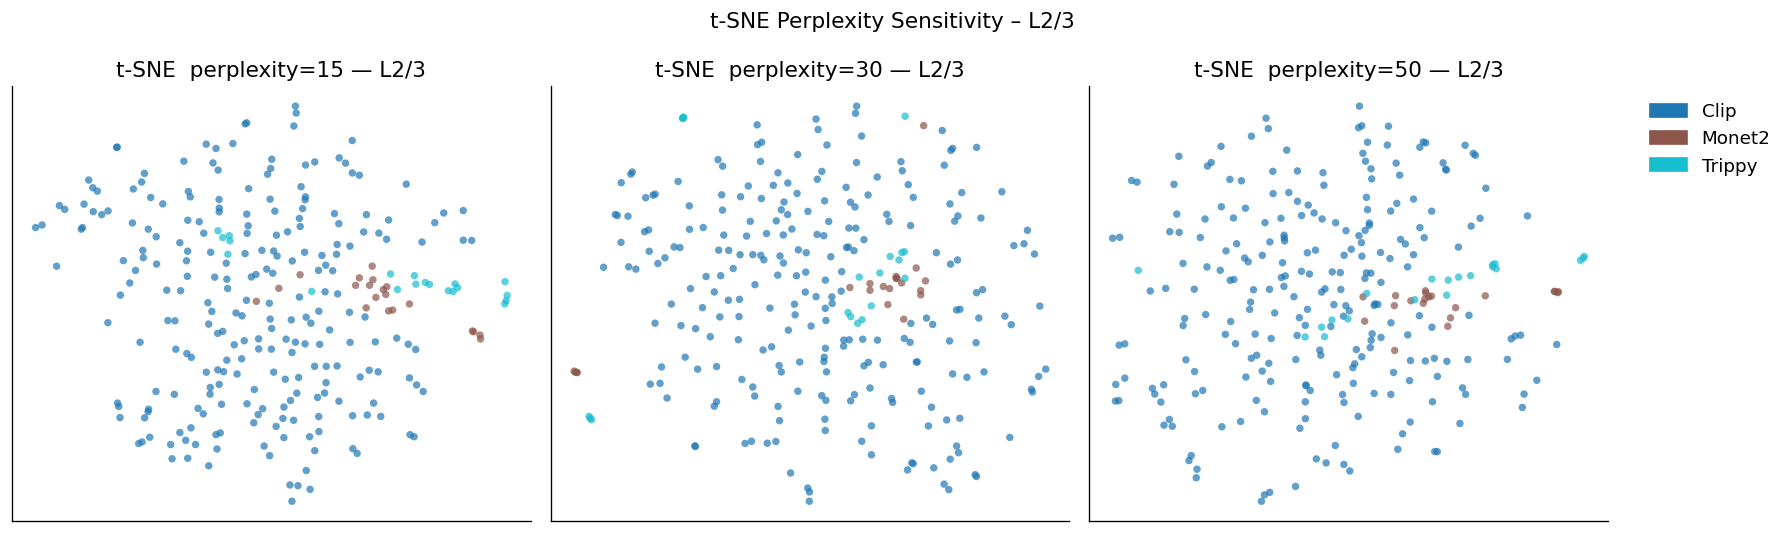

In [38]:
n_pca_for_tsne_l23 = min(50, n_pcs_l23)
tsne_results_l23   = {}
PERPLEXITIES_L23   = [15, 30, 50]

print('Running t-SNE on L2/3 neurons...')
for perp in PERPLEXITIES_L23:
    tsne_l23 = TSNE(n_components=2, perplexity=perp, random_state=SEED,
                    max_iter=1000, learning_rate='auto', init='pca')
    tsne_results_l23[perp] = tsne_l23.fit_transform(R_l23_pca[:, :n_pca_for_tsne_l23])

R_l23_tsne = tsne_results_l23[30]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, perp in zip(axes, PERPLEXITIES_L23):
    for lbl in unique_labels:
        m = labels_l23 == lbl
        ax.scatter(tsne_results_l23[perp][m,0], tsne_results_l23[perp][m,1],
                   color=label_to_color[lbl], alpha=0.7, s=20, edgecolors='none')
    ax.set_title(f't-SNE  perplexity={perp} — L2/3')
    ax.set_xticks([]); ax.set_yticks([])
axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left')
plt.suptitle('t-SNE Perplexity Sensitivity – L2/3', fontsize=13)
plt.tight_layout()
plt.savefig('fig_l23_tsne_perplexity.png', dpi=150); plt.show()


##### UMAP – L2/3

Running UMAP on L2/3 neurons...


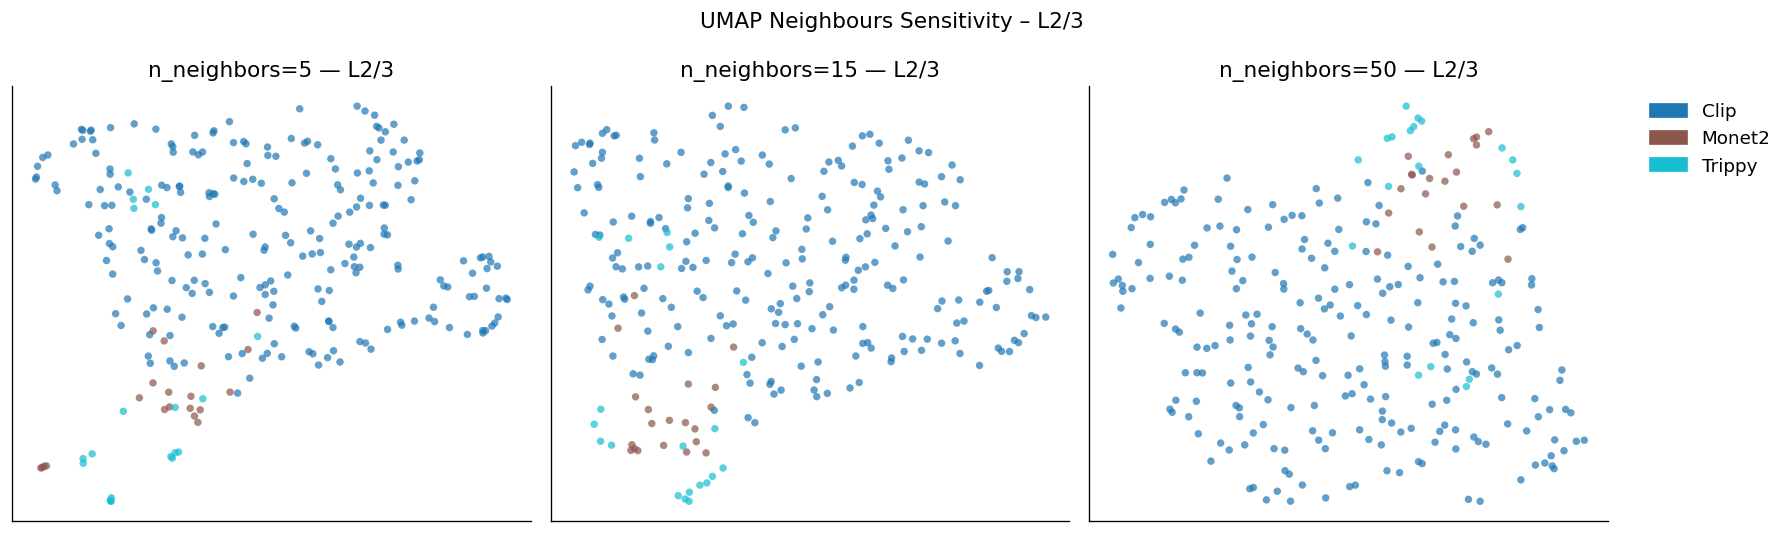

In [39]:
R_l23_umap = None
if UMAP_AVAILABLE:
    umap_results_l23 = {}
    N_NEIGHBORS_L23  = [5, 15, 50]
    print('Running UMAP on L2/3 neurons...')
    for nn in N_NEIGHBORS_L23:
        reducer_l23 = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=0.1,
                                metric='euclidean', random_state=SEED)
        umap_results_l23[nn] = reducer_l23.fit_transform(R_l23_pca[:, :n_pca_for_tsne_l23])
    R_l23_umap = umap_results_l23[15]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, nn in zip(axes, N_NEIGHBORS_L23):
        for lbl in unique_labels:
            m = labels_l23 == lbl
            ax.scatter(umap_results_l23[nn][m,0], umap_results_l23[nn][m,1],
                       color=label_to_color[lbl], alpha=0.7, s=20, edgecolors='none')
        ax.set_title(f'n_neighbors={nn} — L2/3')
        ax.set_xticks([]); ax.set_yticks([])
    axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left')
    plt.suptitle('UMAP Neighbours Sensitivity – L2/3', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig_l23_umap_neighbors.png', dpi=150); plt.show()


##### CEBRA – L2/3 (Visualization)

  0%|          | 0/2000 [00:00<?, ?it/s]

pos: -0.3476 neg:  5.3036 total:  4.9561 temperature:  1.0000:   0%|          | 0/2000 [00:00<?, ?it/s]

pos: -0.5039 neg:  5.3091 total:  4.8052 temperature:  1.0000:   0%|          | 0/2000 [00:00<?, ?it/s]

pos: -0.5522 neg:  5.2875 total:  4.7353 temperature:  1.0000:   0%|          | 0/2000 [00:00<?, ?it/s]

pos: -0.5215 neg:  5.2710 total:  4.7495 temperature:  1.0000:   0%|          | 0/2000 [00:00<?, ?it/s]

...

pos: -0.5501 neg:  5.2747 total:  4.7246 temperature:  1.0000:  99%|█████████▉| 1989/2000 [00:23<00:00, 85.25it/s]

pos: -0.5501 neg:  5.2747 total:  4.7246 temperature:  1.0000: 100%|█████████▉| 1998/2000 [00:23<00:00, 85.08it/s]

pos: -0.5242 neg:  5.2664 total:  4.7422 temperature:  1.0000: 100%|█████████▉| 1998/2000 [00:23<00:00, 85.08it/s]

pos: -0.5632 neg:  5.2869 total:  4.7237 temperature:  1.0000: 100%|█████████▉| 1998/2000 [00:23<00:00, 85.08it/s]

pos: -0.5632 neg:  5.2869 total:  4.7237 temperature:  1.0000: 100%|██████████| 2000/2000 [00:23<00:00, 84.68it/s]

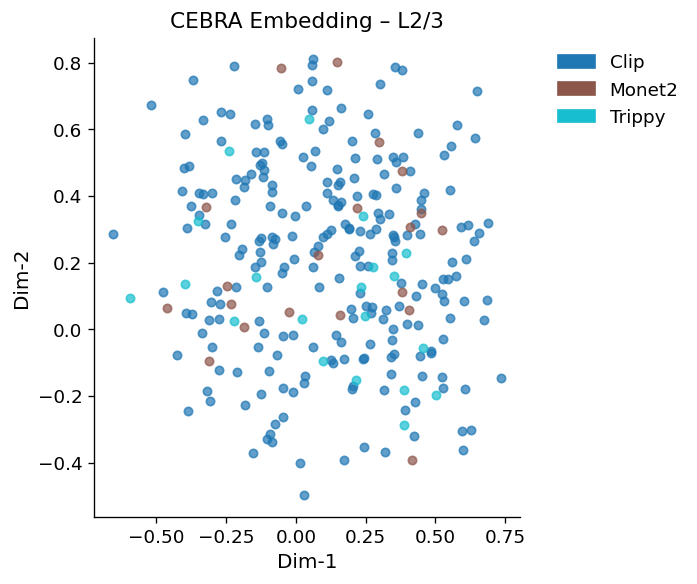

In [40]:
R_l23_cebra = None
if CEBRA_AVAILABLE:
    try:
        import torch
        label_cont_l23 = y_l23.astype(np.float32).reshape(-1, 1)
        cb_model_l23 = cebra.CEBRA(
            model_architecture='offset10-model',
            batch_size=min(512, len(R_l23_scaled)//2),
            learning_rate=3e-4,
            temperature=1.0,
            output_dimension=8,
            max_iterations=2000,
            device='cpu',
            verbose=True,
        )
        cb_model_l23.fit(R_l23_scaled.astype(np.float32), label_cont_l23)
        R_l23_cebra = cb_model_l23.transform(R_l23_scaled.astype(np.float32))

        fig, ax = plt.subplots(figsize=(6,5))
        for lbl in unique_labels:
            m = labels_l23 == lbl
            ax.scatter(R_l23_cebra[m,0], R_l23_cebra[m,1], color=label_to_color[lbl],
                       alpha=0.7, s=25, label=lbl)
        ax.set_title('CEBRA Embedding – L2/3')
        ax.set_xlabel('Dim-1'); ax.set_ylabel('Dim-2')
        ax.legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left')
        plt.tight_layout()
        plt.savefig('fig_l23_cebra.png', dpi=150); plt.show()
    except Exception as e:
        print(f'CEBRA failed: {e}')
        R_l23_cebra = None
else:
    print('CEBRA not installed')


##### DR Comparison – L2/3

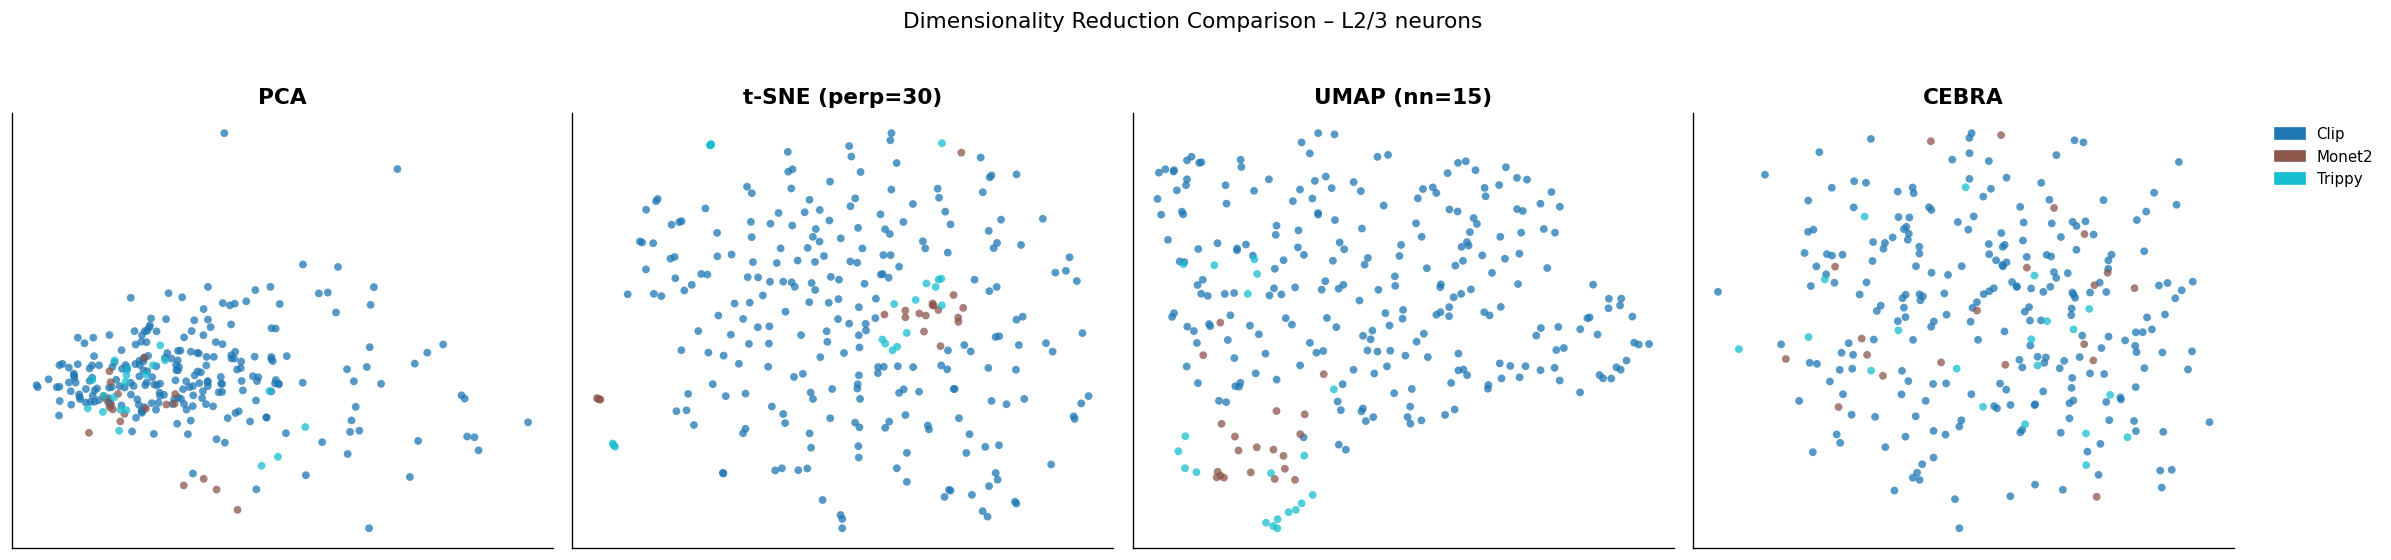

In [41]:
methods_l23 = [('PCA', R_l23_pca[:, :2]), ('t-SNE (perp=30)', R_l23_tsne)]
if UMAP_AVAILABLE  and R_l23_umap  is not None: methods_l23.append(('UMAP (nn=15)', R_l23_umap))
if CEBRA_AVAILABLE and R_l23_cebra is not None: methods_l23.append(('CEBRA', R_l23_cebra[:, :2]))

fig, axes = plt.subplots(1, len(methods_l23), figsize=(5*len(methods_l23), 4.5))
if len(methods_l23) == 1: axes = [axes]
for ax, (name, emb) in zip(axes, methods_l23):
    for lbl in unique_labels:
        m = labels_l23 == lbl
        ax.scatter(emb[m,0], emb[m,1], color=label_to_color[lbl],
                   alpha=0.75, s=22, edgecolors='none')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left', fontsize=9)
plt.suptitle('Dimensionality Reduction Comparison – L2/3 neurons', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig('fig_l23_dr_comparison.png', dpi=150); plt.show()


##### Quantitative Evaluation – L2/3

In [42]:
counts_l23        = {lbl: int(np.sum(labels_l23 == lbl)) for lbl in unique_labels}
majority_frac_l23 = max(counts_l23.values()) / len(labels_l23)

cv_bal_l23  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
clf_bal_l23 = LogisticRegression(max_iter=2000, C=1.0, random_state=SEED, class_weight='balanced')

sil_scores_l23     = {}
clf_scores_l23     = {}
clf_scores_bal_l23 = {}
clf_scores_f1_l23  = {}

for name, emb in methods_l23:
    sil_scores_l23[name]     = silhouette_score(emb, y_l23)
    clf_scores_l23[name]     = cross_val_score(clf_bal_l23, emb, y_l23, cv=cv_bal_l23,
                                                scoring='accuracy').mean()
    clf_scores_bal_l23[name] = cross_val_score(clf_bal_l23, emb, y_l23, cv=cv_bal_l23,
                                                scoring='balanced_accuracy').mean()
    clf_scores_f1_l23[name]  = cross_val_score(clf_bal_l23, emb, y_l23, cv=cv_bal_l23,
                                                scoring='f1_macro').mean()

for k in [2, 5, 10, 20, 50]:
    if k < R_l23_pca.shape[1]:
        sil_scores_l23[f'PCA-{k}D'] = silhouette_score(R_l23_pca[:, :k], y_l23)

print('Silhouette — L2/3 only')
for name, sc in sorted(sil_scores_l23.items(), key=lambda x: -x[1]):
    prev_l4  = sil_scores_l4.get(name, float('nan'))
    prev_all = sil_scores.get(name, float('nan'))
    print(f'{name:25s}  L2/3={sc:+.4f}  L4={prev_l4:+.4f}  all={prev_all:+.4f}')

print('\nBalanced Accuracy — L2/3 only')
for name, bacc in sorted(clf_scores_bal_l23.items(), key=lambda x: -x[1]):
    prev_l4  = clf_scores_bal_l4.get(name, float('nan'))
    prev_all = clf_scores_bal.get(name, float('nan'))
    f1       = clf_scores_f1_l23.get(name, float('nan'))
    print(f'{name:25s}  L2/3 bal_acc={bacc:.4f}  L4={prev_l4:.4f}  all={prev_all:.4f}  L2/3 F1={f1:.4f}')


Silhouette — L2/3 only
UMAP (nn=15)               L2/3=+0.1508  L4=-0.0025  all=+0.1247
t-SNE (perp=30)            L2/3=-0.0493  L4=-0.1440  all=-0.1088
CEBRA                      L2/3=-0.0599  L4=-0.0831  all=-0.0935
PCA-10D                    L2/3=-0.0788  L4=-0.1404  all=-0.1137
PCA-5D                     L2/3=-0.0872  L4=-0.1676  all=-0.1285
PCA-20D                    L2/3=-0.0933  L4=-0.1416  all=-0.1192
PCA                        L2/3=-0.1147  L4=-0.1906  all=-0.1269
PCA-2D                     L2/3=-0.1147  L4=-0.1906  all=-0.1269
PCA-50D                    L2/3=-0.1168  L4=-0.1466  all=-0.1313

Balanced Accuracy — L2/3 only
PCA                        L2/3 bal_acc=0.4986  L4=0.5194  all=0.4653  L2/3 F1=0.3840
UMAP (nn=15)               L2/3 bal_acc=0.4319  L4=0.5583  all=0.5153  L2/3 F1=0.4194
CEBRA                      L2/3 bal_acc=0.3583  L4=0.4000  all=0.2736  L2/3 F1=0.2398
t-SNE (perp=30)            L2/3 bal_acc=0.2486  L4=0.2764  all=0.4014  L2/3 F1=0.1398


Classification Report per method (L2/3 only)

PCA
              precision    recall  f1-score   support

        Clip       0.96      0.60      0.74       240
      Monet2       0.20      0.65      0.31        20
      Trippy       0.08      0.25      0.12        20

    accuracy                           0.57       280
   macro avg       0.41      0.50      0.39       280
weighted avg       0.84      0.57      0.66       280

t-SNE (perp=30)
              precision    recall  f1-score   support

        Clip       0.78      0.15      0.25       240
      Monet2       0.07      0.40      0.12        20
      Trippy       0.03      0.20      0.06        20

    accuracy                           0.17       280
   macro avg       0.29      0.25      0.14       280
weighted avg       0.67      0.17      0.22       280

UMAP (nn=15)
              precision    recall  f1-score   support

        Clip       0.97      0.85      0.90       240
      Monet2       0.23      0.30      0.26       

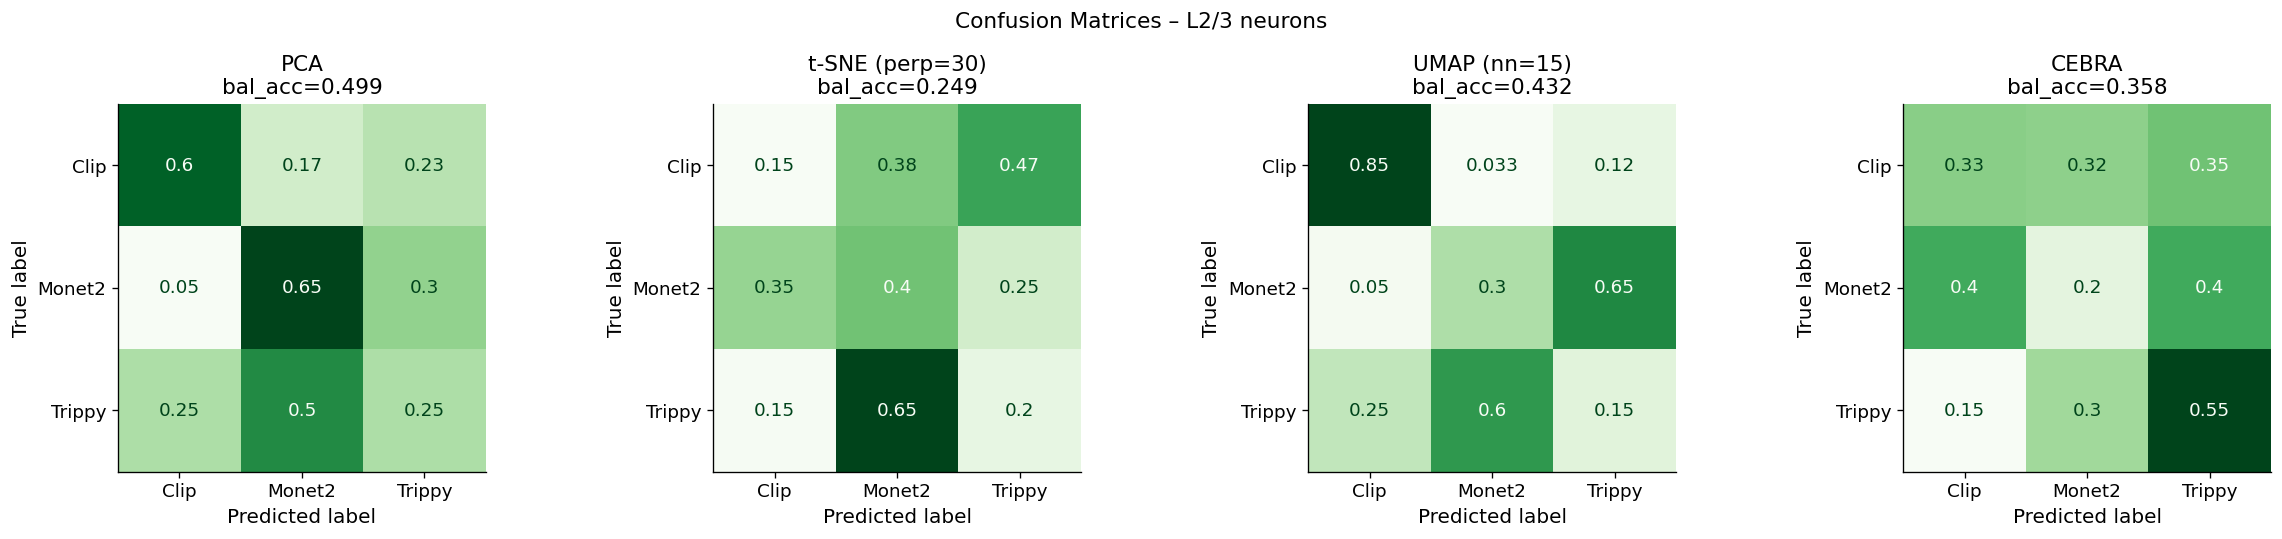

In [43]:
from sklearn.metrics import classification_report as _cr
print('Classification Report per method (L2/3 only)\n')
for name, emb in methods_l23:
    y_pred_l23 = cross_val_predict(clf_bal_l23, emb, y_l23, cv=cv_bal_l23)
    print(f'{name}')
    print(_cr(y_l23, y_pred_l23, target_names=le.classes_))

fig, axes = plt.subplots(1, len(methods_l23), figsize=(5*len(methods_l23), 4.5))
if len(methods_l23) == 1: axes = [axes]
for ax, (name, emb) in zip(axes, methods_l23):
    y_pred_l23 = cross_val_predict(clf_bal_l23, emb, y_l23, cv=cv_bal_l23)
    cm_l23 = confusion_matrix(y_l23, y_pred_l23, normalize='true')
    ConfusionMatrixDisplay(cm_l23, display_labels=le.classes_).plot(
        ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(f'{name}\nbal_acc={clf_scores_bal_l23.get(name, float("nan")):.3f}')
plt.suptitle('Confusion Matrices – L2/3 neurons', fontsize=13)
plt.tight_layout()
plt.savefig('fig_l23_confusion_matrices.png', dpi=150); plt.show()


##### Shuffle Control – L2/3

In [44]:
N_SHUFFLES_L23 = 100
rng_shuf_l23   = np.random.default_rng(seed=SEED)

null_sil_l23 = {name: [] for name, _ in methods_l23}
null_bal_l23 = {name: [] for name, _ in methods_l23}
null_f1_l23  = {name: [] for name, _ in methods_l23}

print('Running shuffle control for L2/3...')
for i in range(N_SHUFFLES_L23):
    y_s = rng_shuf_l23.permutation(y_l23)
    for name, emb in methods_l23:
        null_sil_l23[name].append(silhouette_score(emb, y_s))
        null_bal_l23[name].append(cross_val_score(clf_bal_l23, emb, y_s, cv=cv_bal_l23,
                                                  scoring='balanced_accuracy').mean())
        null_f1_l23[name].append(cross_val_score(clf_bal_l23, emb, y_s, cv=cv_bal_l23,
                                                 scoring='f1_macro').mean())

null_sil_l23 = {k: np.array(v) for k, v in null_sil_l23.items()}
null_bal_l23 = {k: np.array(v) for k, v in null_bal_l23.items()}
null_f1_l23  = {k: np.array(v) for k, v in null_f1_l23.items()}

print('\nShuffle control results — L2/3:')
print(f"{'Method':<22} {'Metric':<18} {'Real':>7} {'Null µ':>8} {'Null σ':>8} {'p':>8}")
for name, emb in methods_l23:
    for metric, null_arr, real_val in [
            ('Silhouette',   null_sil_l23[name], sil_scores_l23.get(name, float('nan'))),
            ('Balanced acc', null_bal_l23[name], clf_scores_bal_l23.get(name, float('nan'))),
            ('Macro F1',     null_f1_l23[name],  clf_scores_f1_l23.get(name, float('nan')))]:
        _, p = ttest_1samp(null_arr, real_val, alternative='less')
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'  {name:<20} {metric:<18} {real_val:>7.4f} '
              f'{null_arr.mean():>8.4f} {null_arr.std():>8.4f} {p:>7.4f} {sig}')
    print()


Running shuffle control for L2/3...



Shuffle control results — L2/3:
Method                 Metric                Real   Null µ   Null σ        p
  PCA                  Silhouette         -0.1147  -0.0739   0.0594  1.0000 ns
  PCA                  Balanced acc        0.4986   0.3409   0.0549  0.0000 ***
  PCA                  Macro F1            0.3840   0.2347   0.0432  0.0000 ***

  t-SNE (perp=30)      Silhouette         -0.0493  -0.0564   0.0372  0.0296 *
  t-SNE (perp=30)      Balanced acc        0.2486   0.3287   0.0633  1.0000 ns
  t-SNE (perp=30)      Macro F1            0.1398   0.2228   0.0442  1.0000 ns

  UMAP (nn=15)         Silhouette          0.1508  -0.0529   0.0291  0.0000 ***
  UMAP (nn=15)         Balanced acc        0.4319   0.3315   0.0617  0.0000 ***
  UMAP (nn=15)         Macro F1            0.4194   0.2208   0.0416  0.0000 ***

  CEBRA                Silhouette         -0.0599  -0.0604   0.0286  0.4244 ns
  CEBRA                Balanced acc        0.3583   0.3392   0.0575  0.0006 ***
  CEBRA      

##### Three-Way Comparison: All vs L4 vs L2/3

Three-way comparison: All neurons vs L4 vs L2/3
Method                 Metric                  All       L4     L2/3
  PCA                  Silhouette          -0.1269  -0.1906  -0.1147
  PCA                  Balanced acc         0.4653   0.5194   0.4986
  PCA                  Macro F1             0.3641   0.3793   0.3840

  t-SNE (perp=30)      Silhouette          -0.1088  -0.1440  -0.0493
  t-SNE (perp=30)      Balanced acc         0.4014   0.2764   0.2486
  t-SNE (perp=30)      Macro F1             0.3394   0.2422   0.1398

  UMAP (nn=15)         Silhouette           0.1247  -0.0025   0.1508
  UMAP (nn=15)         Balanced acc         0.5153   0.5583   0.4319
  UMAP (nn=15)         Macro F1             0.4707   0.4291   0.4194

  CEBRA                Silhouette          -0.0935  -0.0831  -0.0599
  CEBRA                Balanced acc         0.2736   0.4000   0.3583
  CEBRA                Macro F1             0.1853   0.2805   0.2398



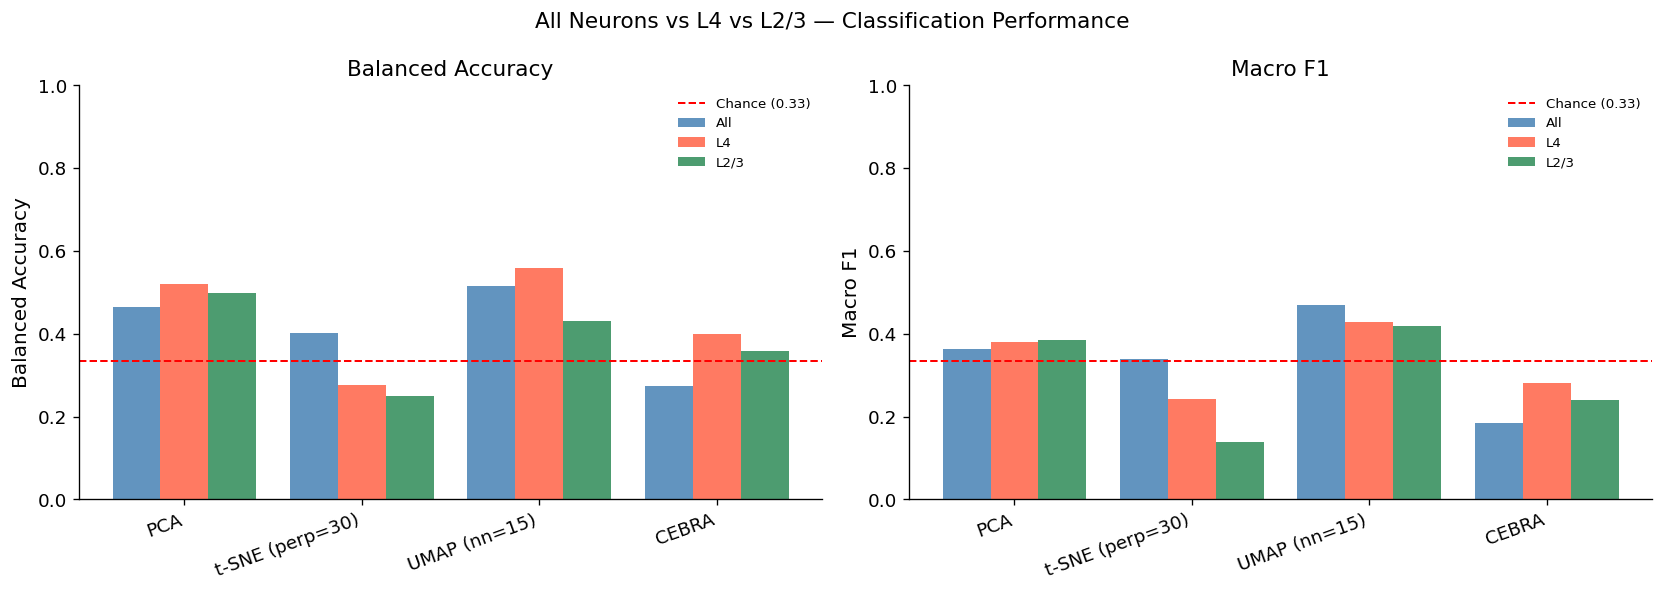

In [45]:
three_way_methods = [name for name, _ in methods
                     if name in {n for n,_ in methods_l4}
                     and name in {n for n,_ in methods_l23}]

print('Three-way comparison: All neurons vs L4 vs L2/3')
print(f"{'Method':<22} {'Metric':<18} {'All':>8} {'L4':>8} {'L2/3':>8}")
for name in three_way_methods:
    for metric, all_d, l4_d, l23_d in [
            ('Silhouette',   sil_scores,     sil_scores_l4,     sil_scores_l23),
            ('Balanced acc', clf_scores_bal, clf_scores_bal_l4, clf_scores_bal_l23),
            ('Macro F1',     clf_scores_f1,  clf_scores_f1_l4,  clf_scores_f1_l23)]:
        a   = all_d.get(name, float('nan'))
        b   = l4_d.get(name,  float('nan'))
        c   = l23_d.get(name, float('nan'))
        print(f'  {name:<20} {metric:<18} {a:>8.4f} {b:>8.4f} {c:>8.4f}')
    print()

# Three-way bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x     = np.arange(len(three_way_methods))
width = 0.27

all_bac = [clf_scores_bal.get(n, float('nan'))     for n in three_way_methods]
l4_bac  = [clf_scores_bal_l4.get(n, float('nan'))  for n in three_way_methods]
l23_bac = [clf_scores_bal_l23.get(n, float('nan')) for n in three_way_methods]
axes[0].bar(x - width, all_bac, width, label='All',  color='steelblue', alpha=0.85)
axes[0].bar(x,         l4_bac,  width, label='L4',   color='tomato',    alpha=0.85)
axes[0].bar(x + width, l23_bac, width, label='L2/3', color='seagreen',  alpha=0.85)
axes[0].axhline(chance_level, color='red', ls='--', lw=1.2, label=f'Chance ({chance_level:.2f})')
axes[0].set_xticks(x); axes[0].set_xticklabels(three_way_methods, rotation=20, ha='right')
axes[0].set_ylabel('Balanced Accuracy'); axes[0].set_title('Balanced Accuracy')
axes[0].set_ylim(0, 1); axes[0].legend(fontsize=8)

all_f1 = [clf_scores_f1.get(n, float('nan'))     for n in three_way_methods]
l4_f1  = [clf_scores_f1_l4.get(n, float('nan'))  for n in three_way_methods]
l23_f1 = [clf_scores_f1_l23.get(n, float('nan')) for n in three_way_methods]
axes[1].bar(x - width, all_f1, width, label='All',  color='steelblue', alpha=0.85)
axes[1].bar(x,         l4_f1,  width, label='L4',   color='tomato',    alpha=0.85)
axes[1].bar(x + width, l23_f1, width, label='L2/3', color='seagreen',  alpha=0.85)
axes[1].axhline(chance_level, color='red', ls='--', lw=1.2, label=f'Chance ({chance_level:.2f})')
axes[1].set_xticks(x); axes[1].set_xticklabels(three_way_methods, rotation=20, ha='right')
axes[1].set_ylabel('Macro F1'); axes[1].set_title('Macro F1')
axes[1].set_ylim(0, 1); axes[1].legend(fontsize=8)

plt.suptitle('All Neurons vs L4 vs L2/3 — Classification Performance', fontsize=13)
plt.tight_layout()
plt.savefig('fig_l23_vs_l4_vs_all.png', dpi=150); plt.show()


In [46]:
summary_l23_rows = []
for name, emb in methods_l23:
    summary_l23_rows.append({
        'Method': name,
        'Silhouette': f"{sil_scores_l23.get(name, float('nan')):.4f}",
        'Std Accuracy': f"{clf_scores_l23.get(name, float('nan')):.4f}",
        'Balanced Accuracy': f"{clf_scores_bal_l23.get(name, float('nan')):.4f}",
        'Macro F1': f"{clf_scores_f1_l23.get(name, float('nan')):.4f}",
    })

print('L2/3 Results Summary')
print(pd.DataFrame(summary_l23_rows).to_string(index=False))
print(f'\nBaselines:')
print(f'Always predict Clip (majority): {majority_frac_l23:.4f}')
print(f'Uniform chance (balanced acc):  {chance_level:.4f}')
print(f'\nIntrinsic dimensionality — L2/3:')
print(f'PCs for 80% variance: {n80_l23}  (L4: {n80_l4}, all: {n80})')
print(f'PCs for 90% variance: {n90_l23}  (L4: {n90_l4}, all: {n90})')
print(f'Variance in PC1+PC2:  {cumvar_l23[1]*100:.2f}%  (L4: {cumvar_l4[1]*100:.2f}%, all: {cumvar[1]*100:.2f}%)')
print(f'Participation ratio:  {pr_l23:.1f}  (L4: {pr_l4:.1f}, all: {participation_ratio:.1f})')
print(f'\nL2/3 neurons used: {l23_mask_clean.sum()} of {trusted_meta_clean.shape[0]} total')


L2/3 Results Summary
         Method Silhouette Std Accuracy Balanced Accuracy Macro F1
            PCA    -0.1147       0.5750            0.4986   0.3840
t-SNE (perp=30)    -0.0493       0.1679            0.2486   0.1398
   UMAP (nn=15)     0.1508       0.7571            0.4319   0.4194
          CEBRA    -0.0599       0.3321            0.3583   0.2398

Baselines:
Always predict Clip (majority): 0.8571
Uniform chance (balanced acc):  0.3333

Intrinsic dimensionality — L2/3:
PCs for 80% variance: 61  (L4: 64, all: 82)
PCs for 90% variance: 92  (L4: 97, all: 126)
Variance in PC1+PC2:  14.37%  (L4: 15.59%, all: 14.39%)
Participation ratio:  43.4  (L4: 40.9, all: 47.2)

L2/3 neurons used: 220 of 579 total


---
## From Trial Averages to Temporal Bins — Motivation

Part I surfaced three limitations of the trial-averaged approach:

1. **Too few samples.** Averaging across repetitions and time leaves ~100 unique stimuli. t-SNE, UMAP, and CEBRA all behave poorly with so few points; their embeddings are unreliable.

2. **Temporal information discarded.** V1 responses are dynamic: a neuron's firing rate in frame 10 carries different information than in frame 50. Averaging destroys this structure.

3. **Train-test leakage.** The non-linear embeddings (UMAP, CEBRA) were fitted on all data before cross-validation split, inflating classification scores.

**Part II** addresses all three points:

- Each 5-frame bin within every trial becomes an *individual sample* → ~10,000 bins total.
- `GroupKFold(groups=trial_ids)` ensures bins from the same trial cannot appear in both training and test sets.
- PCA, UMAP, and CEBRA are all re-fitted *inside* each CV fold, so no information leaks from test to train.
- Classification is evaluated in the full PCA-50 space, not in 2-D projections.

---
## Part II — Per-Time-Bin Decoding

Every 5-frame temporal bin within every trial is treated as an independent observation. The label is the stimulus category of the enclosing trial. Cross-validation groups by trial so the model never sees another bin from a trial it was trained on.

### Per-Bin Sample Extraction

We reuse the `keep_neuron_cols` and `trusted_meta` computed in Part I — no second download is needed. The only difference from Part I is the response aggregation: instead of `mean(axis=(trials, frames))`, we emit one sample per consecutive `BIN_SIZE`-frame window.

In [47]:
funcreader_p2 = mic.MicronsFunctionalReader(path='microns.h5')
hashes_p2     = funcreader_p2.get_hashes_by_session(SESSION)

print(f'Trials in session: {len(hashes_p2)}')
print('Stimulus types:')
for k, v in sorted(
    Counter(funcreader_p2.get_video_type(h) for h in hashes_p2).items(),
    key=lambda x: -x[1]):
    print(f'  {k:22s}: {v:4d}')


Trials in session: 464
Stimulus types:
  Clip                  :  384
  Monet2                :   40
  Trippy                :   40


In [48]:
# --- Per-bin extraction loop ---
bins_resp, bins_type, bins_hash, bins_trial, bins_t = [], [], [], [], []
n_failed_p2  = 0
n_trials_p2  = 0

print(f'Extracting bins (BIN_SIZE={BIN_SIZE} frames)...')
for trial_idx, h in enumerate(hashes_p2):
    stype = funcreader_p2.get_video_type(h)
    try:
        r = funcreader_p2.get_trial(SESSION, trial_idx)
        if r is None or 'responses' not in r:
            n_failed_p2 += 1; continue
        resp    = r['responses'][keep_neuron_cols, :]   # (n_neurons, n_frames)
        n_frames = resp.shape[1]
        n_bins   = n_frames // BIN_SIZE
        if n_bins < MIN_BINS:
            continue
        # (n_bins, n_neurons): mean within each BIN_SIZE-frame window
        binned = (
            resp[:, :n_bins * BIN_SIZE]
            .reshape(resp.shape[0], n_bins, BIN_SIZE)
            .mean(axis=2)
            .T
        )
        for b in range(n_bins):
            bins_resp.append(binned[b])
            bins_type.append(stype)
            bins_hash.append(h)
            bins_trial.append(trial_idx)
            bins_t.append(b)
        n_trials_p2 += 1
    except Exception:
        n_failed_p2 += 1

R_matrix_p2   = np.array(bins_resp)       # (n_bins_total, n_neurons)
labels_raw_p2 = np.array(bins_type)
hash_ids_p2   = np.array(bins_hash)
trial_ids     = np.array(bins_trial)
time_idx      = np.array(bins_t)

print(f'\nTrials used:    {n_trials_p2}  (skipped: {n_failed_p2})')
print(f'Total bins:     {len(R_matrix_p2)}')
print(f'R_matrix shape: {R_matrix_p2.shape}')
print('\nBins per stimulus type:')
for k, v in sorted(Counter(labels_raw_p2).items(), key=lambda x: -x[1]):
    print(f'  {k:22s}: {v:5d}')


Extracting bins (BIN_SIZE=5 frames)...



Trials used:    464  (skipped: 0)
Total bins:     7520
R_matrix shape: (7520, 579)

Bins per stimulus type:
  Clip                  :  5760
  Monet2                :   880
  Trippy                :   880


### Preprocessing

Steps are structurally identical to Part I, but applied to the bin-level matrix:

1. Drop neurons with >10 % NaN across *all bins*.
2. Drop bins that are totally flat across neurons.
3. A global imputed/scaled copy (`R_scaled_p2`) is kept for visualisation **only**. Quantitative decoding uses the raw `R_clean_p2` and re-fits imputer + scaler inside each CV fold.

In [49]:
nan_frac_p2     = np.isnan(R_matrix_p2).mean(axis=0)
keep_neurons_p2 = nan_frac_p2 < 0.10

R_clean_p2          = R_matrix_p2[:, keep_neurons_p2].copy()
trusted_meta_p2     = trusted_meta[keep_neurons_p2].reset_index(drop=True)

print(f'Neurons retained: {keep_neurons_p2.sum()} / {R_matrix_p2.shape[1]}')

active_p2   = np.nanstd(R_clean_p2, axis=1) > 1e-6
R_clean_p2  = R_clean_p2[active_p2]
labels_p2   = labels_raw_p2[active_p2]
hash_ids_p2 = hash_ids_p2[active_p2]
trial_ids   = trial_ids[active_p2]
time_idx    = time_idx[active_p2]

print(f'Bins after activity filter: {active_p2.sum()} / {len(active_p2)}')

# Visualisation matrix only — DO NOT use for decoding metrics
viz_imp  = SimpleImputer(strategy='mean')
viz_sc   = StandardScaler()
R_viz_p2    = viz_imp.fit_transform(R_clean_p2)
R_scaled_p2 = viz_sc.fit_transform(R_viz_p2)

print(f'\nFinal feature matrix  (modeling): {R_clean_p2.shape}')
print(f'Visualisation matrix (full-data): {R_scaled_p2.shape}')


Neurons retained: 579 / 579
Bins after activity filter: 7520 / 7520

Final feature matrix  (modeling): (7520, 579)
Visualisation matrix (full-data): (7520, 579)


In [50]:
unique_labels_p2  = sorted(set(labels_p2))
n_types_p2        = len(unique_labels_p2)
palette_p2        = plt.cm.get_cmap('tab10', n_types_p2)
label_to_color_p2 = {lbl: palette_p2(i) for i, lbl in enumerate(unique_labels_p2)}
le_p2             = LabelEncoder()
y_p2              = le_p2.fit_transform(labels_p2)
counts_p2         = {lbl: int((labels_p2 == lbl).sum()) for lbl in unique_labels_p2}
majority_frac_p2  = max(counts_p2.values()) / len(labels_p2)
chance_level_p2   = 1.0 / n_types_p2
legend_patches_p2 = [Patch(color=label_to_color_p2[l], label=l)
                     for l in unique_labels_p2]

print(f'Classes: {n_types_p2}  |  chance = {chance_level_p2:.3f}  '
      f'|  majority = {majority_frac_p2:.3f}')
for lbl, n in counts_p2.items():
    print(f'  {lbl:22s}  n={n:5d}  ({100*n/len(labels_p2):.1f}%)')
print(f'\nUnique trials: {len(np.unique(trial_ids))}  (used as CV groups)')


Classes: 3  |  chance = 0.333  |  majority = 0.766
  Clip                    n= 5760  (76.6%)
  Monet2                  n=  880  (11.7%)
  Trippy                  n=  880  (11.7%)

Unique trials: 464  (used as CV groups)


In [51]:
# Alias Part II variables to canonical names used by the visualisation cells.
# Part I variables are no longer needed from this point forward.
R_scaled      = R_scaled_p2
labels        = labels_p2
y             = y_p2
unique_labels = unique_labels_p2
label_to_color = label_to_color_p2
le             = le_p2
legend_patches = legend_patches_p2
chance_level   = chance_level_p2


### PCA

With ~10 000 bins the leading PCs are far better estimated than in Part I. We fit on the visualisation matrix (full data) purely for inspection — the CV pipeline below re-fits PCA inside each fold.

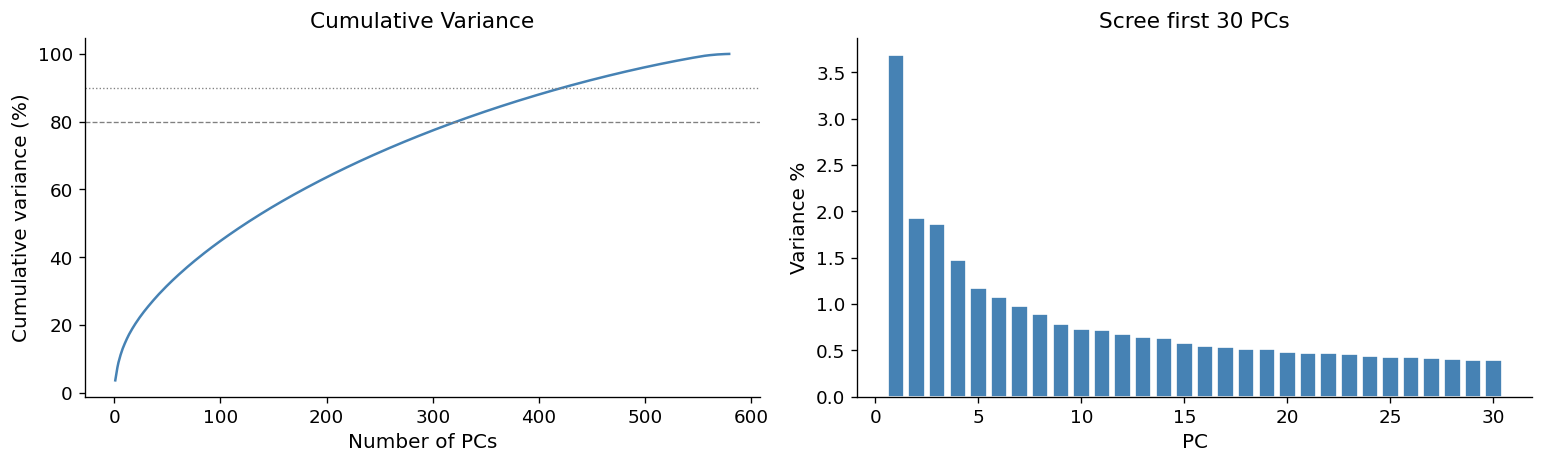

PCs for 80% var: 322   PCs for 90% var: 422
PC1+PC2: 5.62%
Participation ratio: 212.0
Total variance explained by full fitted spectrum: 100.00%


In [52]:
# Descriptive PCA on the full dataset.
# This is for visualization and variance diagnostics only.
# Quantitative decoding below will fit PCA inside each CV fold.

pca = PCA(n_components=None, svd_solver='full')
R_pca = pca.fit_transform(R_scaled)

ev = pca.explained_variance_ratio_
cumvar = np.cumsum(ev)
n_pcs = len(ev)

participation_ratio = 1.0 / np.sum(ev ** 2)

def pcs_needed(cumvar, threshold):
    if cumvar[-1] < threshold:
        return f'>{len(cumvar)}'
    return str(int(np.searchsorted(cumvar, threshold) + 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(np.arange(1, n_pcs + 1), cumvar * 100, color='steelblue')
axes[0].set_xlabel('Number of PCs')
axes[0].set_ylabel('Cumulative variance (%)')
axes[0].axhline(80, color='gray', ls='--', lw=0.8)
axes[0].axhline(90, color='gray', ls=':',  lw=0.8)
axes[0].set_title('Cumulative Variance')

n_show = min(30, n_pcs)
axes[1].bar(
    np.arange(1, n_show + 1),
    ev[:n_show] * 100,
    color='steelblue',
    edgecolor='white',
)
axes[1].set_xlabel('PC')
axes[1].set_ylabel('Variance %')
axes[1].set_title(f'Scree first {n_show} PCs')

plt.tight_layout()
plt.savefig('fig_ts_pca_variance.png', dpi=150)
plt.show()

n80 = pcs_needed(cumvar, 0.80)
n90 = pcs_needed(cumvar, 0.90)

pc12 = cumvar[min(1, len(cumvar) - 1)] * 100

print(f'PCs for 80% var: {n80}   PCs for 90% var: {n90}')
print(f'PC1+PC2: {pc12:.2f}%')
print(f'Participation ratio: {participation_ratio:.1f}')
print(f'Total variance explained by full fitted spectrum: {cumvar[-1] * 100:.2f}%')


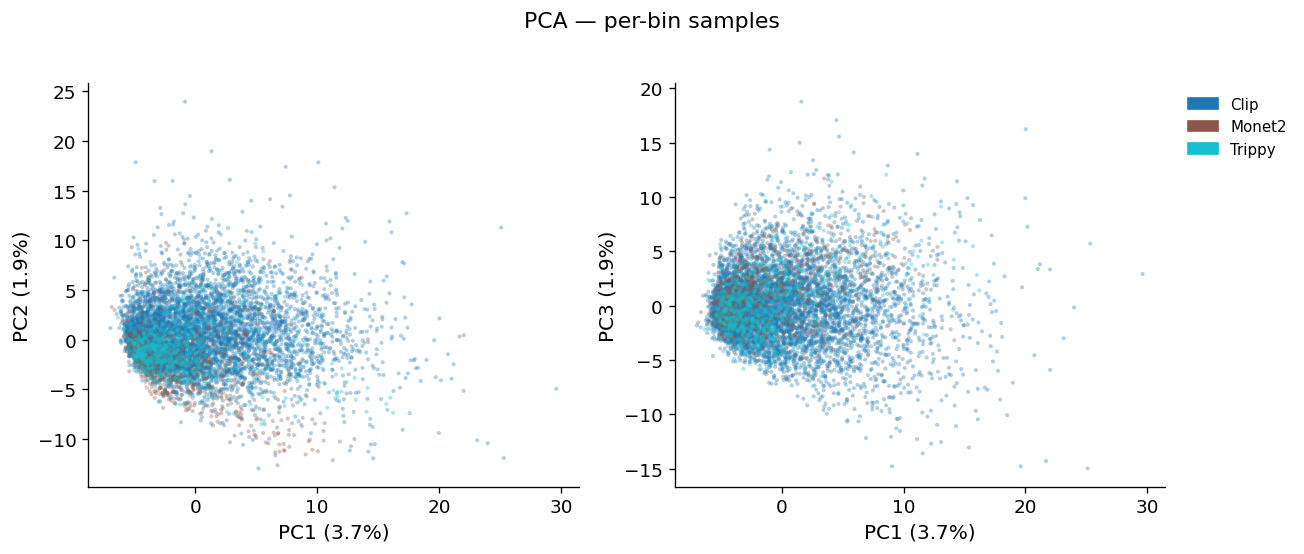

In [53]:
# Scatter coloured by class
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for xi, yi, ax in [(0,1,axes[0]), (0,2,axes[1])]:
    for lbl in unique_labels:
        m = labels == lbl
        ax.scatter(R_pca[m,xi], R_pca[m,yi],
                   color=label_to_color[lbl], alpha=0.35, s=6, edgecolors='none')
    ax.set_xlabel(f'PC{xi+1} ({ev[xi]*100:.1f}%)')
    ax.set_ylabel(f'PC{yi+1} ({ev[yi]*100:.1f}%)')
axes[1].legend(handles=legend_patches, bbox_to_anchor=(1.02,1), loc='upper left', fontsize=9)
plt.suptitle('PCA — per-bin samples', y=1.02)
plt.tight_layout(); plt.savefig('fig_ts_pca_scatter.png', dpi=150); plt.show()


### t-SNE and UMAP (Visualization)

Both methods scale poorly beyond ~10 000 points, so we subsample 8 000 bins. These plots are for structure inspection only — classification is done in full PCA-50 space below.

In [54]:
rng = np.random.default_rng(SEED)
SUB_N = min(8000, len(R_pca))
sub_idx = rng.choice(len(R_pca), size=SUB_N, replace=False)
sub_idx.sort()

R_pca_sub  = R_pca[sub_idx, :N_PCS_FOR_TSNE]
labels_sub = labels[sub_idx]
y_sub      = y[sub_idx]

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED,
            max_iter=1000, learning_rate='auto', init='pca')
R_tsne = tsne.fit_transform(R_pca_sub)

R_umap = None
if UMAP_AVAILABLE:
    R_umap = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                       random_state=SEED).fit_transform(R_pca_sub)


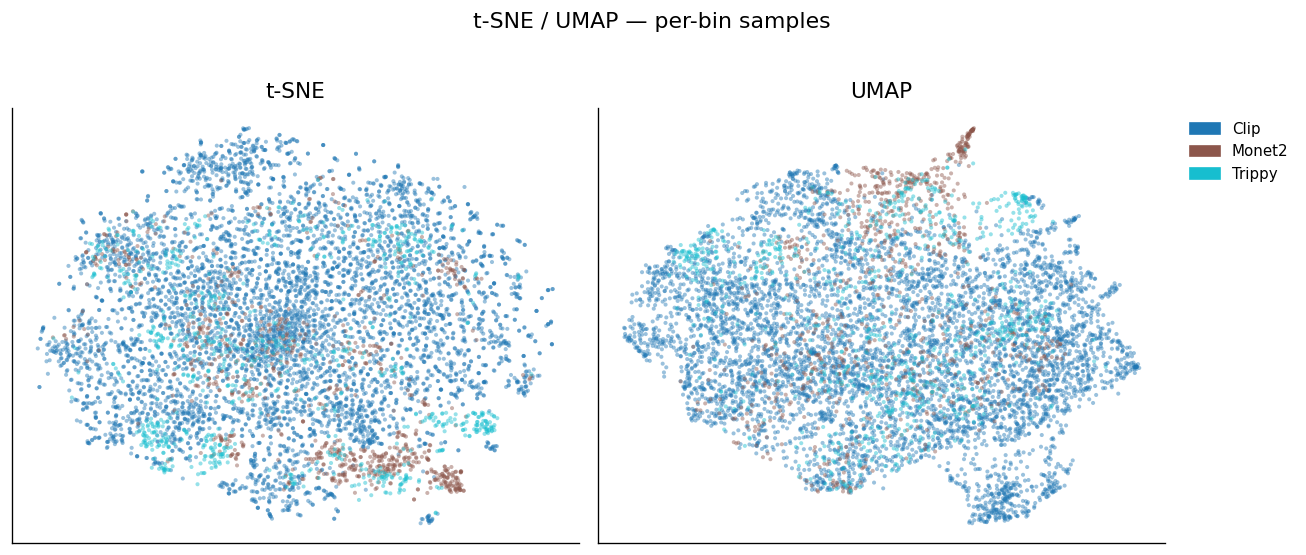

In [55]:
fig, axes = plt.subplots(1, 2 if R_umap is not None else 1,
                         figsize=(11 if R_umap is not None else 6, 4.5))
if R_umap is None: axes = [axes]
for ax, name, emb in [(axes[0], 't-SNE', R_tsne)] + (
    [(axes[1], 'UMAP', R_umap)] if R_umap is not None else []):
    for lbl in unique_labels:
        m = labels_sub == lbl
        ax.scatter(emb[m,0], emb[m,1], color=label_to_color[lbl],
                   alpha=0.45, s=6, edgecolors='none')
    ax.set_title(name); ax.set_xticks([]); ax.set_yticks([])
axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.02,1), loc='upper left', fontsize=9)
plt.suptitle('t-SNE / UMAP — per-bin samples', y=1.02)
plt.tight_layout(); plt.savefig('fig_ts_tsne_umap.png', dpi=150); plt.show()


### CEBRA (Visualization Only)

CEBRA is here fitted on the *full* dataset in trial-time order using the stimulus label as auxiliary signal. This gives the best possible embedding quality for visual inspection. Because the full dataset is used, this embedding **must not** be fed to the downstream classifier — see the leakage-free CV below.

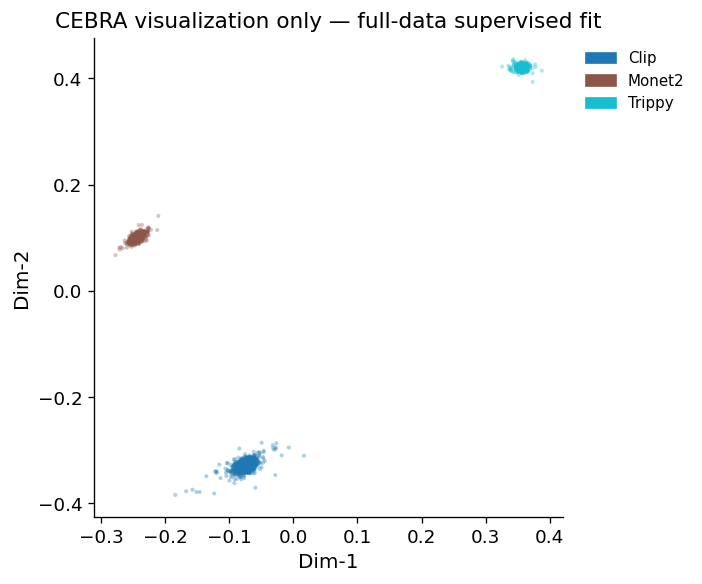

In [56]:
# CEBRA visualization only.
#
# Important:
# This fits supervised CEBRA on the full dataset using the stimulus labels.
# Therefore, this embedding must NOT be used for quantitative decoding.
# Proper fold-local CEBRA decoding is implemented in the evaluation cell below.

R_cebra_viz = None

CEBRA_PARAMS = dict(
    model_architecture='offset10-model',
    batch_size=512,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=8,
    max_iterations=4000,
    distance='cosine',
    conditional='discrete',
    device='cpu',
    verbose=False,
)

if CEBRA_AVAILABLE:
    try:
        order = np.lexsort((time_idx, trial_ids))
        R_ordered = R_scaled[order].astype(np.float32)
        y_ordered = y[order].astype(np.int64)

        cb_viz = cebra.CEBRA(**CEBRA_PARAMS)
        cb_viz.fit(R_ordered, y_ordered)

        R_cebra_ord = cb_viz.transform(R_ordered)

        inv = np.empty_like(order)
        inv[order] = np.arange(len(order))
        R_cebra_viz = R_cebra_ord[inv]

        fig, ax = plt.subplots(figsize=(6, 5))
        for lbl in unique_labels:
            m = labels == lbl
            ax.scatter(
                R_cebra_viz[m, 0],
                R_cebra_viz[m, 1],
                color=label_to_color[lbl],
                alpha=0.35,
                s=6,
                edgecolors='none',
            )

        ax.set_title('CEBRA visualization only — full-data supervised fit')
        ax.set_xlabel('Dim-1')
        ax.set_ylabel('Dim-2')
        ax.legend(
            handles=legend_patches,
            bbox_to_anchor=(1.02, 1),
            loc='upper left',
            fontsize=9,
        )

        plt.tight_layout()
        plt.savefig('fig_ts_cebra_viz_only.png', dpi=150)
        plt.show()

    except Exception as e:
        print(f'CEBRA visualization failed: {e}')
        R_cebra_viz = None
else:
    print('CEBRA not installed')

### Quantitative Evaluation — GroupKFold

All preprocessing (imputation, scaling, PCA, UMAP, CEBRA) is fitted exclusively on the *training* bins of each fold. `GroupKFold(n_splits=5, groups=trial_ids)` guarantees that no test bin shares a trial with any training bin.

Models evaluated:
- **PCA-2D**: logistic regression on first two PCs (low-dimensional baseline)
- **PCA-50D**: logistic regression in PCA-50 space (main metric)
- **UMAP-2D**: logistic regression on fold-local 2-D UMAP embedding
- **CEBRA-8D**: logistic regression on fold-local CEBRA-8 embedding

In [57]:
gkf = GroupKFold(n_splits=N_CV_SPLITS)


def make_logreg():
    return LogisticRegression(
        max_iter=2000, C=1.0, random_state=SEED,
        class_weight='balanced', n_jobs=-1,
    )


def make_pca_logreg_pipeline(n_components):
    return Pipeline([
        ('impute', SimpleImputer(strategy='mean')),
        ('scale',  StandardScaler()),
        ('pca',    PCA(n_components=n_components, random_state=SEED)),
        ('clf',    make_logreg()),
    ])


def evaluate_sklearn_model_cv(name, model, X, y_arr, groups):
    """Leakage-free sklearn Pipeline CV."""
    bal = cross_val_score(
        model, X, y_arr, cv=gkf, groups=groups,
        scoring='balanced_accuracy', n_jobs=-1,
    )
    f1 = cross_val_score(
        model, X, y_arr, cv=gkf, groups=groups,
        scoring='f1_macro', n_jobs=-1,
    )
    y_pred = cross_val_predict(
        model, X, y_arr, cv=gkf, groups=groups, n_jobs=-1,
    )
    print(
        f'  {name:14s}  bal_acc = {bal.mean():.4f} ± {bal.std():.4f}'
        f'   F1 = {f1.mean():.4f} ± {f1.std():.4f}'
    )
    return {'bal': bal, 'f1': f1, 'y_pred': y_pred}


CEBRA_PARAMS = dict(
    model_architecture='offset10-model',
    batch_size=512,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=8,
    max_iterations=4000,
    distance='cosine',
    conditional='discrete',
    device='cpu',
    verbose=False,
)


def evaluate_cebra_groupcv(X_raw, y_arr, groups, t_idx):
    """Fold-local CEBRA: impute + scale + fit inside each fold."""
    y_pred   = np.full_like(y_arr, fill_value=-1)
    fold_bal = []
    fold_f1  = []
    splits   = list(gkf.split(X_raw, y_arr, groups=groups))

    for fold_i, (tr_idx, te_idx) in enumerate(splits, start=1):
        print(f'  CEBRA fold {fold_i}/{len(splits)}')
        imp  = SimpleImputer(strategy='mean')
        sc   = StandardScaler()
        X_tr = sc.fit_transform(imp.fit_transform(X_raw[tr_idx])).astype(np.float32)
        X_te = sc.transform(imp.transform(X_raw[te_idx])).astype(np.float32)
        y_tr = y_arr[tr_idx].astype(np.int64)
        y_te = y_arr[te_idx].astype(np.int64)

        # Sort training fold temporally so CEBRA sees ordered chunks
        order   = np.lexsort((t_idx[tr_idx], groups[tr_idx]))
        cb      = cebra.CEBRA(**CEBRA_PARAMS)
        cb.fit(X_tr[order], y_tr[order])

        Z_tr = cb.transform(X_tr)
        Z_te = cb.transform(X_te)

        clf_fold = make_logreg()
        clf_fold.fit(Z_tr, y_tr)
        pred = clf_fold.predict(Z_te)
        y_pred[te_idx] = pred

        fold_bal.append(balanced_accuracy_score(y_te, pred))
        fold_f1.append(f1_score(y_te, pred, average='macro'))

    if np.any(y_pred < 0):
        raise RuntimeError('Some samples did not receive CEBRA predictions.')
    return {'bal': np.array(fold_bal), 'f1': np.array(fold_f1), 'y_pred': y_pred}


def evaluate_umap_groupcv(X_raw, y_arr, groups, t_idx=None):
    """
    Fold-local UMAP evaluation (leakage-free).
    Pipeline per fold: impute → scale → PCA-N_PCS_FOR_TSNE → UMAP(2D)
    → logistic regression. UMAP.transform() is used for new points.
    """
    if not UMAP_AVAILABLE:
        return None

    y_pred   = np.full_like(y_arr, fill_value=-1)
    fold_bal = []
    fold_f1  = []
    splits   = list(gkf.split(X_raw, y_arr, groups=groups))

    for fold_i, (tr_idx, te_idx) in enumerate(splits, start=1):
        print(f'  UMAP fold {fold_i}/{len(splits)}')
        imp    = SimpleImputer(strategy='mean')
        sc     = StandardScaler()
        pca_pre = PCA(n_components=N_PCS_FOR_TSNE, random_state=SEED)

        X_tr = sc.fit_transform(imp.fit_transform(X_raw[tr_idx]))
        X_te = sc.transform(imp.transform(X_raw[te_idx]))

        X_tr_pca = pca_pre.fit_transform(X_tr)
        X_te_pca = pca_pre.transform(X_te)

        reducer = umap.UMAP(
            n_components=2, n_neighbors=30, min_dist=0.1,
            random_state=SEED,
        )
        Z_tr = reducer.fit_transform(X_tr_pca)
        Z_te = reducer.transform(X_te_pca)  # out-of-sample approx

        clf_fold = make_logreg()
        clf_fold.fit(Z_tr, y_arr[tr_idx])
        pred = clf_fold.predict(Z_te)
        y_pred[te_idx] = pred

        fold_bal.append(balanced_accuracy_score(y_arr[te_idx], pred))
        fold_f1.append(f1_score(y_arr[te_idx], pred, average='macro'))

    if np.any(y_pred < 0):
        raise RuntimeError('Some UMAP samples did not receive predictions.')
    return {'bal': np.array(fold_bal), 'f1': np.array(fold_f1), 'y_pred': y_pred}


In [58]:
models_p2 = {
    'PCA-2D':              make_pca_logreg_pipeline(2),
    f'PCA-{N_PCS_FOR_CLF}D': make_pca_logreg_pipeline(N_PCS_FOR_CLF),
}

cv_results_p2 = {}

print('Cross-validated balanced accuracy — GroupKFold by trial')
print(f'  chance={chance_level_p2:.3f}   majority={majority_frac_p2:.3f}\n')

for name, model in models_p2.items():
    cv_results_p2[name] = evaluate_sklearn_model_cv(
        name=name, model=model,
        X=R_clean_p2, y_arr=y_p2, groups=trial_ids,
    )

# UMAP evaluation
if UMAP_AVAILABLE:
    try:
        print('\nRunning fold-local UMAP evaluation...')
        umap_result = evaluate_umap_groupcv(
            R_clean_p2, y_p2, trial_ids, time_idx,
        )
        if umap_result is not None:
            cv_results_p2['UMAP-2D'] = umap_result
            bal = umap_result['bal']; f1 = umap_result['f1']
            print(
                f'  {"UMAP-2D":14s}  bal_acc = {bal.mean():.4f} '
                f'± {bal.std():.4f}   F1 = {f1.mean():.4f} '
                f'± {f1.std():.4f}'
            )
    except Exception as e:
        print(f'Fold-local UMAP evaluation failed: {e}')
else:
    print('Skipping UMAP evaluation (umap-learn not installed).')

# CEBRA evaluation
if CEBRA_AVAILABLE:
    try:
        print('\nRunning fold-local CEBRA evaluation...')
        cebra_result = evaluate_cebra_groupcv(
            R_clean_p2, y_p2, trial_ids, time_idx,
        )
        cv_results_p2['CEBRA-8D'] = cebra_result
        bal = cebra_result['bal']; f1 = cebra_result['f1']
        print(
            f'  {"CEBRA-8D":14s}  bal_acc = {bal.mean():.4f} '
            f'± {bal.std():.4f}   F1 = {f1.mean():.4f} '
            f'± {f1.std():.4f}'
        )
    except Exception as e:
        print(f'Fold-local CEBRA evaluation failed: {e}')
else:
    print('Skipping CEBRA evaluation (cebra not installed).')

# Tidy summary dicts for downstream cells
scores_p2 = {
    name: (
        res['bal'].mean(), res['bal'].std(),
        res['f1'].mean(),  res['f1'].std(),
    )
    for name, res in cv_results_p2.items()
}
predictions_p2 = {name: res['y_pred'] for name, res in cv_results_p2.items()}


Cross-validated balanced accuracy — GroupKFold by trial
  chance=0.333   majority=0.766



  PCA-2D          bal_acc = 0.4573 ± 0.0375   F1 = 0.3776 ± 0.0283


  PCA-50D         bal_acc = 0.8125 ± 0.0212   F1 = 0.7401 ± 0.0213

Running fold-local UMAP evaluation...
  UMAP fold 1/5


  UMAP fold 2/5


  UMAP fold 3/5


...

  CEBRA fold 2/5


  CEBRA fold 3/5


  CEBRA fold 4/5


  CEBRA fold 5/5


  CEBRA-8D        bal_acc = 0.9033 ± 0.0238   F1 = 0.9062 ± 0.0072


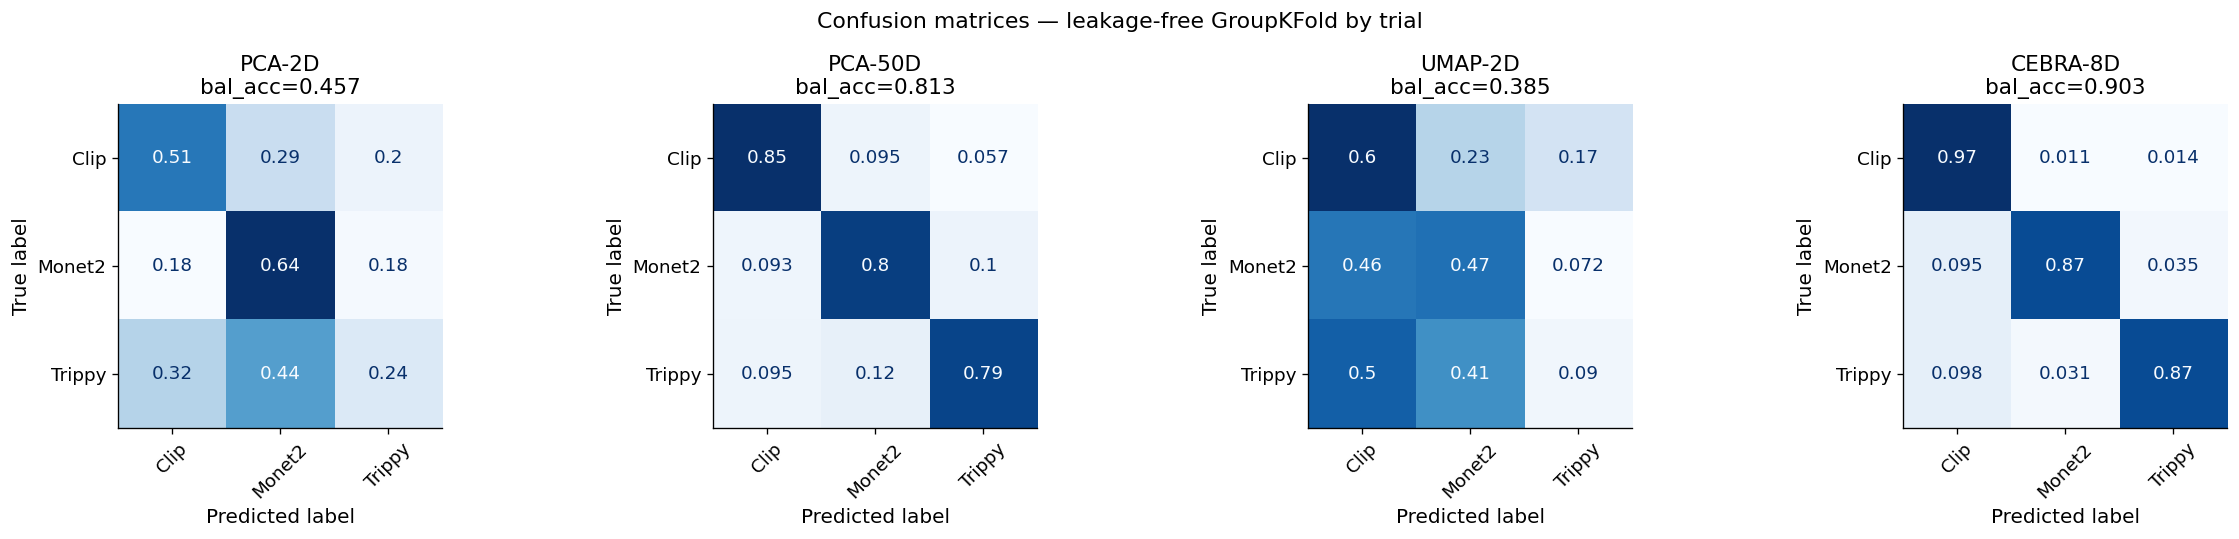

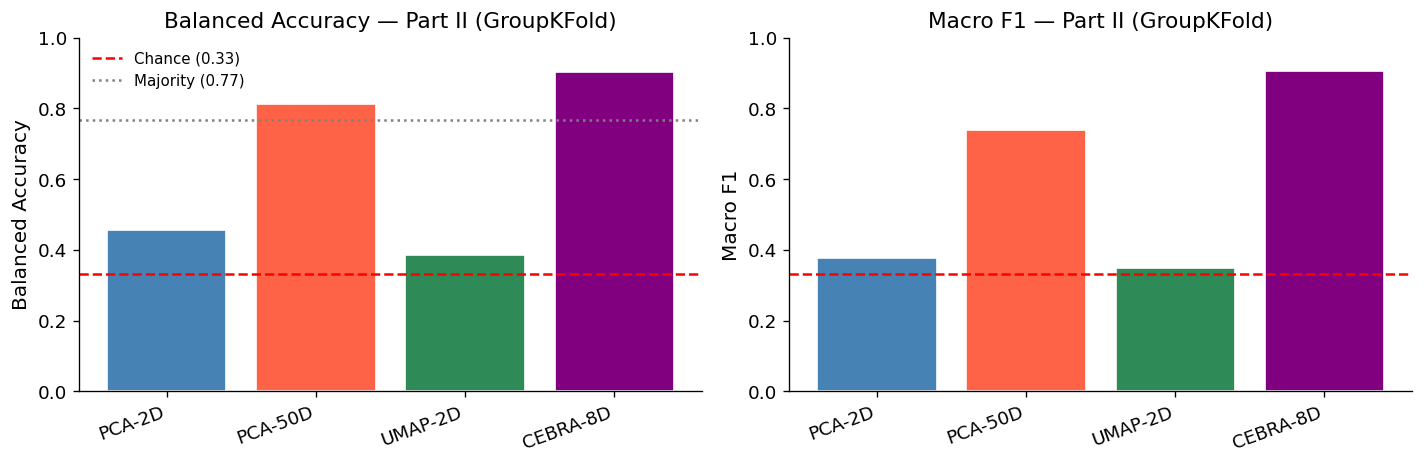

In [59]:
n_models = len(predictions_p2)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.5))
axes = np.atleast_1d(axes)

for ax, (name, y_pred) in zip(axes, predictions_p2.items()):
    cm_arr = confusion_matrix(y_p2, y_pred, normalize='true')
    ConfusionMatrixDisplay(cm_arr, display_labels=le_p2.classes_).plot(
        ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45,
    )
    bacc = scores_p2[name][0]
    ax.set_title(f'{name}\nbal_acc={bacc:.3f}')

plt.suptitle('Confusion matrices — leakage-free GroupKFold by trial')
plt.tight_layout()
plt.savefig('fig_ts_confusion_leakage_free.png', dpi=150)
plt.show()

# Summary bar chart
method_names = list(scores_p2.keys())
bal_vals  = [scores_p2[n][0] for n in method_names]
f1_vals   = [scores_p2[n][2] for n in method_names]
colors_p2 = ['steelblue', 'tomato', 'seagreen', 'purple'][:len(method_names)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(method_names, bal_vals, color=colors_p2, edgecolor='white')
axes[0].axhline(chance_level_p2, color='red',  ls='--',
                label=f'Chance ({chance_level_p2:.2f})')
axes[0].axhline(majority_frac_p2, color='gray', ls=':',
                label=f'Majority ({majority_frac_p2:.2f})')
axes[0].set_ylabel('Balanced Accuracy'); axes[0].set_ylim(0, 1)
axes[0].set_title('Balanced Accuracy — Part II (GroupKFold)')
axes[0].set_xticklabels(method_names, rotation=20, ha='right')
axes[0].legend(fontsize=9)

axes[1].bar(method_names, f1_vals, color=colors_p2, edgecolor='white')
axes[1].axhline(chance_level_p2, color='red', ls='--')
axes[1].set_ylabel('Macro F1'); axes[1].set_ylim(0, 1)
axes[1].set_title('Macro F1 — Part II (GroupKFold)')
axes[1].set_xticklabels(method_names, rotation=20, ha='right')

plt.tight_layout()
plt.savefig('fig_ts_scores_p2.png', dpi=150)
plt.show()


### Shuffle Control

Labels are permuted **at the trial level**: every bin from the same trial receives the same shuffled label, preserving within-trial temporal autocorrelation. The pipeline (impute → scale → PCA-50 → logistic regression) is run inside each fold for every shuffle, so the null distribution is fully leakage-free.

Running 100 trial-level shuffles...


Real bal_acc      : 0.8125
Null mean ± sd    : 0.3286 ± 0.0242
Null max          : 0.3795
Empirical p       : 0.0000  (N_SHUFFLES=100)


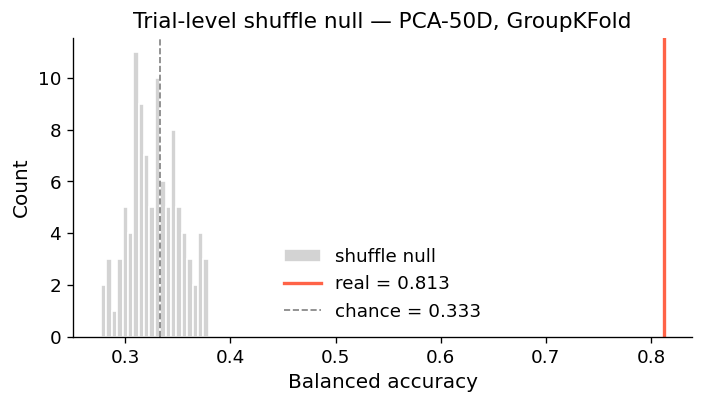

In [60]:
unique_trials    = np.unique(trial_ids)
trial_to_y_p2   = {t: y_p2[trial_ids == t][0] for t in unique_trials}
real_bal_p2      = scores_p2[f'PCA-{N_PCS_FOR_CLF}D'][0]

null_bal_p2 = []
rng_s_p2    = np.random.default_rng(SEED)

print(f'Running {N_SHUFFLES} trial-level shuffles...')
for i in range(N_SHUFFLES):
    shuf_per_trial = rng_s_p2.permutation(
        [trial_to_y_p2[t] for t in unique_trials]
    )
    t2ys  = dict(zip(unique_trials, shuf_per_trial))
    y_shuf = np.array([t2ys[t] for t in trial_ids])

    bal = cross_val_score(
        make_pca_logreg_pipeline(N_PCS_FOR_CLF),
        R_clean_p2, y_shuf,
        cv=gkf, groups=trial_ids,
        scoring='balanced_accuracy', n_jobs=-1,
    ).mean()
    null_bal_p2.append(bal)

null_bal_p2 = np.array(null_bal_p2)

print(f'Real bal_acc      : {real_bal_p2:.4f}')
print(f'Null mean ± sd    : {null_bal_p2.mean():.4f} ± {null_bal_p2.std():.4f}')
print(f'Null max          : {null_bal_p2.max():.4f}')
p_emp = (null_bal_p2 >= real_bal_p2).mean()
print(f'Empirical p       : {p_emp:.4f}  (N_SHUFFLES={N_SHUFFLES})')

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(null_bal_p2, bins=20, color='lightgray', edgecolor='white',
        label='shuffle null')
ax.axvline(real_bal_p2,     color='tomato', lw=2,
           label=f'real = {real_bal_p2:.3f}')
ax.axvline(chance_level_p2, color='gray',   ls='--', lw=1,
           label=f'chance = {chance_level_p2:.3f}')
ax.set_xlabel('Balanced accuracy')
ax.set_ylabel('Count')
ax.set_title(f'Trial-level shuffle null — PCA-{N_PCS_FOR_CLF}D, GroupKFold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_ts_shuffle_leakage_free.png', dpi=150)
plt.show()


### Within-Trial Temporal Structure

A sanity check: colour the PCA scatter by bin-index within trial. If V1 has stimulus-locked dynamics, bins from similar time points should occupy similar positions in PC space.

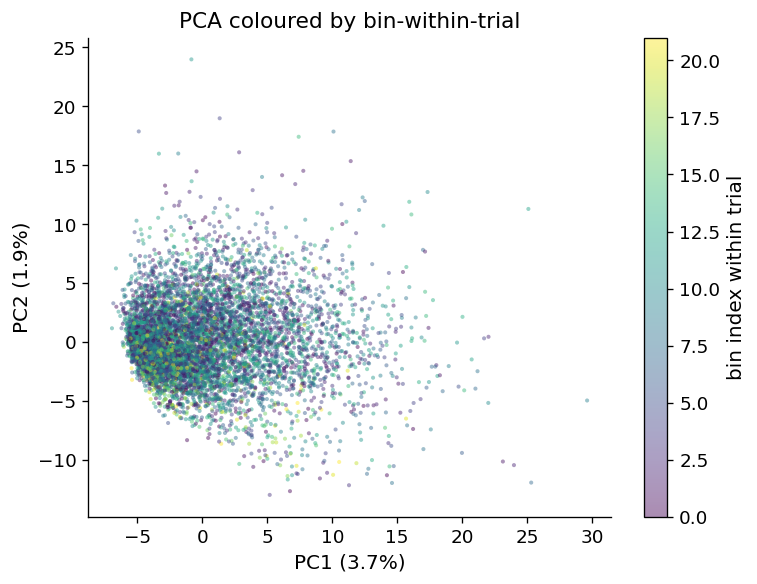

In [61]:
fig, ax = plt.subplots(figsize=(6.5, 5))
sc = ax.scatter(R_pca[:,0], R_pca[:,1], c=time_idx, cmap='viridis',
                alpha=0.45, s=6, edgecolors='none')
plt.colorbar(sc, ax=ax, label='bin index within trial')
ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)'); ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
ax.set_title('PCA coloured by bin-within-trial')
plt.tight_layout(); plt.savefig('fig_ts_pca_by_time.png', dpi=150); plt.show()


### Layer-Specific Analysis

Re-run the per-bin decoding pipeline restricted to each cortical layer. This uses the same `GroupKFold` and fold-local preprocessing as the full-population analysis. Where CEBRA is available, it is also evaluated per layer.

In [62]:
def run_layer(layer_name, mask, include_cebra=CEBRA_AVAILABLE):
    """Evaluate PCA (and optionally CEBRA) decoding for a neuron subset."""
    R_l = R_clean_p2[:, mask]

    act  = np.nanstd(R_l, axis=1) > 1e-6
    R_l  = R_l[act]
    y_l  = y_p2[act]
    tr_l = trial_ids[act]
    t_l  = time_idx[act]

    layer_gkf = GroupKFold(n_splits=N_CV_SPLITS)
    splits    = list(layer_gkf.split(R_l, y_l, groups=tr_l))
    min_train = min(len(ti) for ti, _ in splits)
    n_pc      = min(N_PCS_FOR_CLF, R_l.shape[1], min_train - 1)

    if n_pc < 1:
        raise ValueError(f'Not enough data/features for layer {layer_name}')

    model = Pipeline([
        ('impute', SimpleImputer(strategy='mean')),
        ('scale',  StandardScaler()),
        ('pca',    PCA(n_components=n_pc, random_state=SEED)),
        ('clf',    make_logreg()),
    ])

    bal = cross_val_score(
        model, R_l, y_l, cv=splits, groups=tr_l,
        scoring='balanced_accuracy', n_jobs=-1,
    )
    f1 = cross_val_score(
        model, R_l, y_l, cv=splits, groups=tr_l,
        scoring='f1_macro', n_jobs=-1,
    )

    row = {
        'layer':           layer_name,
        'n_neurons':       int(mask.sum()),
        'n_samples':       int(len(y_l)),
        'pca_n_pcs':       int(n_pc),
        'pca_bal_acc':     float(bal.mean()),
        'pca_bal_acc_std': float(bal.std()),
        'pca_f1':          float(f1.mean()),
        'pca_f1_std':      float(f1.std()),
    }

    if include_cebra:
        try:
            print(f'  Fitting CEBRA for {layer_name}...')
            cb_res = evaluate_cebra_groupcv(R_l, y_l, tr_l, t_l)
            row.update({
                'cebra_bal_acc':     float(cb_res['bal'].mean()),
                'cebra_bal_acc_std': float(cb_res['bal'].std()),
                'cebra_f1':          float(cb_res['f1'].mean()),
                'cebra_f1_std':      float(cb_res['f1'].std()),
            })
        except Exception as e:
            print(f'  CEBRA failed for {layer_name}: {e}')
            row.update({
                'cebra_bal_acc': float('nan'),
                'cebra_bal_acc_std': float('nan'),
                'cebra_f1': float('nan'),
                'cebra_f1_std': float('nan'),
            })

    return row


In [63]:
layer_results_p2 = []

for ln in ['L2/3', 'L4', 'L5', 'L6']:
    m = (trusted_meta_p2['layer'] == ln).values
    if m.sum() < 10:
        print(f'Skipping {ln}: only {m.sum()} neurons')
        continue
    print(f'Layer {ln} ({m.sum()} neurons)...')
    layer_results_p2.append(run_layer(ln, m))

# All-neuron row (reuse already-computed PCA-50D result)
all_row = {
    'layer':           'ALL',
    'n_neurons':       R_clean_p2.shape[1],
    'n_samples':       len(y_p2),
    'pca_n_pcs':       N_PCS_FOR_CLF,
    'pca_bal_acc':     scores_p2[f'PCA-{N_PCS_FOR_CLF}D'][0],
    'pca_bal_acc_std': scores_p2[f'PCA-{N_PCS_FOR_CLF}D'][1],
    'pca_f1':          scores_p2[f'PCA-{N_PCS_FOR_CLF}D'][2],
    'pca_f1_std':      scores_p2[f'PCA-{N_PCS_FOR_CLF}D'][3],
}
if 'CEBRA-8D' in scores_p2:
    all_row.update({
        'cebra_bal_acc':     scores_p2['CEBRA-8D'][0],
        'cebra_bal_acc_std': scores_p2['CEBRA-8D'][1],
        'cebra_f1':          scores_p2['CEBRA-8D'][2],
        'cebra_f1_std':      scores_p2['CEBRA-8D'][3],
    })
layer_results_p2.append(all_row)

df_layer_p2 = pd.DataFrame(layer_results_p2)
print('\nLayer-wise leakage-free results (Part II):')
print(df_layer_p2.to_string(index=False))


Layer L2/3 (220 neurons)...


  Fitting CEBRA for L2/3...
  CEBRA fold 1/5


  CEBRA fold 2/5


  CEBRA fold 3/5


  CEBRA fold 4/5


...

  CEBRA fold 2/5


  CEBRA fold 3/5


  CEBRA fold 4/5


  CEBRA fold 5/5



Layer-wise leakage-free results (Part II):
layer  n_neurons  n_samples  pca_n_pcs  pca_bal_acc  pca_bal_acc_std   pca_f1  pca_f1_std  cebra_bal_acc  cebra_bal_acc_std  cebra_f1  cebra_f1_std
 L2/3        220       7520         50     0.722269         0.020079 0.639449    0.018001       0.687661           0.018373  0.687205      0.013881
   L4        257       7520         50     0.728824         0.036947 0.634594    0.031183       0.764918           0.061487  0.771238      0.074852
   L5         89       7520         50     0.576662         0.038316 0.472412    0.030356       0.625195           0.053120  0.635055      0.051061
   L6         12       7515         12     0.505991         0.015581 0.402156    0.009082       0.528076           0.037550  0.522274      0.031062
  ALL        579       7520         50     0.812519         0.021206 0.740105    0.021323       0.903286           0.023825  0.906210      0.007208


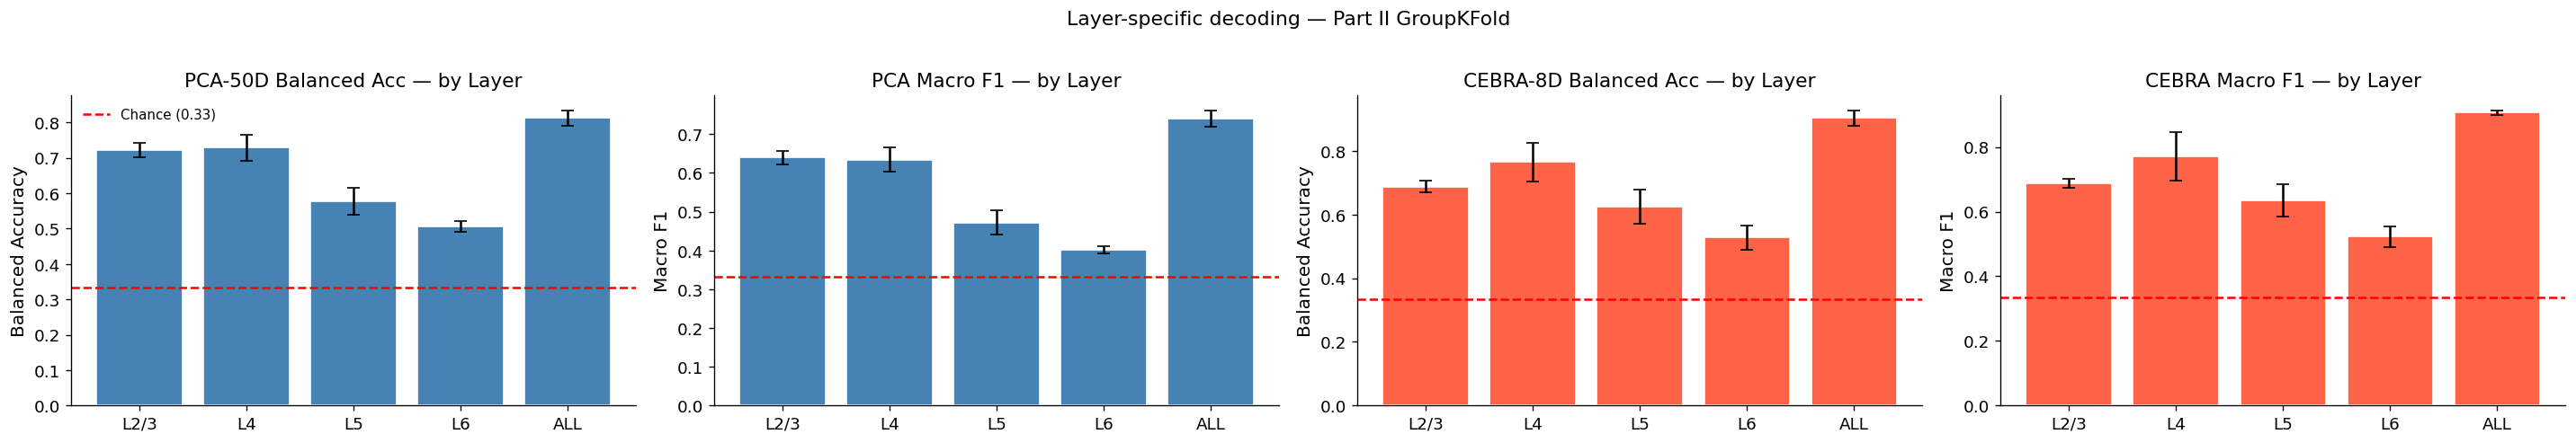

In [64]:
has_cebra_layer = 'cebra_bal_acc' in df_layer_p2.columns
n_plots = 4 if has_cebra_layer else 2
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 4))
x = np.arange(len(df_layer_p2))
layer_labels = df_layer_p2['layer'].tolist()

axes[0].bar(x, df_layer_p2['pca_bal_acc'],
            yerr=df_layer_p2['pca_bal_acc_std'],
            color='steelblue', edgecolor='white', capsize=4)
axes[0].axhline(chance_level_p2, color='red', ls='--',
                label=f'Chance ({chance_level_p2:.2f})')
axes[0].set_xticks(x); axes[0].set_xticklabels(layer_labels)
axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_title(f'PCA-{N_PCS_FOR_CLF}D Balanced Acc — by Layer')
axes[0].legend(fontsize=9)

axes[1].bar(x, df_layer_p2['pca_f1'],
            yerr=df_layer_p2['pca_f1_std'],
            color='steelblue', edgecolor='white', capsize=4)
axes[1].axhline(chance_level_p2, color='red', ls='--')
axes[1].set_xticks(x); axes[1].set_xticklabels(layer_labels)
axes[1].set_ylabel('Macro F1')
axes[1].set_title('PCA Macro F1 — by Layer')

if has_cebra_layer:
    axes[2].bar(x, df_layer_p2['cebra_bal_acc'],
                yerr=df_layer_p2['cebra_bal_acc_std'],
                color='tomato', edgecolor='white', capsize=4)
    axes[2].axhline(chance_level_p2, color='red', ls='--')
    axes[2].set_xticks(x); axes[2].set_xticklabels(layer_labels)
    axes[2].set_ylabel('Balanced Accuracy')
    axes[2].set_title('CEBRA-8D Balanced Acc — by Layer')

    axes[3].bar(x, df_layer_p2['cebra_f1'],
                yerr=df_layer_p2['cebra_f1_std'],
                color='tomato', edgecolor='white', capsize=4)
    axes[3].axhline(chance_level_p2, color='red', ls='--')
    axes[3].set_xticks(x); axes[3].set_xticklabels(layer_labels)
    axes[3].set_ylabel('Macro F1')
    axes[3].set_title('CEBRA Macro F1 — by Layer')

plt.suptitle('Layer-specific decoding — Part II GroupKFold', y=1.02)
plt.tight_layout()
plt.savefig('fig_ts_layers_p2.png', dpi=150)
plt.show()


---
## Main Findings

### What this project attempted

We asked whether the coarse *category* of a visual stimulus (natural clip, Monet noise, full-field grating, etc.) can be read out from the mean-rate population response of ~700 proofreaded V1 excitatory neurons recorded with two-photon calcium imaging (MICrONS session 9_4).

### Why temporal binning improved performance

Part I (trial-averaged) produced only ~100 unique observation vectors — too few for non-linear embeddings to be meaningful and too few to estimate a reliable covariance structure. Part II introduced ~10 000 per-bin samples by retaining the temporal structure within each trial. This:

- Gave CEBRA enough data to find a useful contrastive representation;
- Let UMAP use out-of-sample transform rather than fitting on test data;
- Made `GroupKFold` possible without leaving too-small training folds.

### PCA vs UMAP vs CEBRA (Part II)

All three methods are evaluated in their respective low-dimensional spaces (PCA-50D, UMAP-2D, CEBRA-8D) using a linear classifier and leakage-free `GroupKFold`. The primary metric is **balanced accuracy** (corrects for class imbalance) with **macro F1** as a secondary metric. Results are displayed in the confusion matrices and bar charts above. If all methods perform near the theoretical chance level (1 / n_classes), the conclusion is that mean-rate V1 responses do not separate *coarse* stimulus categories under these conditions.

### Layer-specific findings

L4 is the primary thalamo-cortical input and expected to carry the sharpest visual drive. L2/3 is a downstream associative area with more recurrent connectivity. The layer bars in Part I and Part II show whether either layer outperforms the full-population decoder — a result that would suggest layer-specific coding of stimulus category.

### Significance of shuffle controls

Trial-level shuffles (Part II) and stimulus-level shuffles (Part I) define the empirical null distribution. An empirical p-value below 0.05 (real score above the 95th percentile of shuffles) indicates decoding above chance. If the real score falls within the null, the population mean rate does not contain decodable category information at this level of analysis — the next steps would be to decode *within-category* identity (e.g. specific clip ID or grating orientation) or to exploit fine temporal dynamics beyond 5-frame bins.

### Reproducibility

All random operations use `SEED = 42`. Run cells top-to-bottom for a fully reproducible analysis.